In [1]:
import pandas as pd
import numpy as np
import os

print("Libraries imported successfully")

Libraries imported successfully


## 1. Dataset Location

The raw HR datasets are stored in the Dataset folder. I will load the raw files first and keep the original data unchanged. Cleaning will be performed on separate copies.

In [2]:
dataset_path = r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset"

print("Dataset path set successfully")

Dataset path set successfully


In [3]:
print(os.listdir(dataset_path))

['.ipynb_checkpoints', 'Attendance.csv', 'Attendance_Clean.csv', 'Attrition.csv', 'Attrition_Clean.csv', 'Attrition_Model.ipynb', 'CLEANED', 'Dataset_Summary.csv', 'Data_Dictionary.csv', 'Employees.csv', 'Employees_Clean.csv', 'Employee_Engagement.csv', 'Employee_Engagement_Clean.csv', 'HR_Analytics_Data_Cleaning.ipynb.ipynb', 'Known_Data_Quality_Issues.csv', 'Performance.csv', 'Performance_Clean.csv', 'powerbi', 'SQL']


## 2. Loading Employee Master Dataset

Employees is the master dataset because Employee_ID will be used as the common key to connect attendance, performance, engagement, and attrition data.

In [4]:
employees = pd.read_csv(
    dataset_path + r"\Employees.csv"
)

print("Employees dataset loaded successfully")

Employees dataset loaded successfully


In [5]:
employees.head()

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
0,E00001,Aditya Jadhav,Male,49,Procurement,Senior Procurement Specialist,28-01-2015 00:00,25,Bachelor's,Full-time,Pune,E02909,2696000,Active
1,E00002,Nikhil Bose,Female,41,Marketing,Marketing Manager,05-10-2025 00:00,21,Bachelor's,Full-time,Nashik,E04877,2542000,Active
2,E00003,Divya Mishra,Female,25,Operations,Operations Analyst,03-03-2020 00:00,3,Bachelor's,Full-time,Noida,E01498,668000,Exited
3,E00004,Pooja Reddy,Male,24,IT,Software Engineer,31-10-2023 00:00,0,Bachelor's,Full-time,Bengaluru,E04352,348000,Active
4,E00005,Pallavi Iyer,Male,36,Operations,Senior Operations Executive,30-12-2015 00:00,14,Bachelor's,Full-time,Noida,E02230,1828000,Exited


### Dataset Dimensions

I check the number of rows and columns to understand the size of the Employee Master dataset.

In [6]:
print("Rows and Columns:", employees.shape)

Rows and Columns: (5008, 14)


### Column Validation

I verify that all required Employee Master columns are available and that the column names match the project requirement.

In [7]:
print(employees.columns.tolist())

['Employee_ID', 'Employee_Name', 'Gender', 'Age', 'Department', 'Designation', 'Joining_Date', 'Experience_Years', 'Education', 'Employment_Type', 'Location', 'Manager_ID', 'Salary', 'Employment_Status']


### Data Type Inspection

I inspect the data types and non-null values of each column before performing data cleaning. This helps identify columns that may require data type conversion or validation.

In [8]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Employee_ID        5003 non-null   object
 1   Employee_Name      5008 non-null   object
 2   Gender             5008 non-null   object
 3   Age                5008 non-null   int64 
 4   Department         5000 non-null   object
 5   Designation        5008 non-null   object
 6   Joining_Date       5008 non-null   object
 7   Experience_Years   5008 non-null   int64 
 8   Education          5008 non-null   object
 9   Employment_Type    5008 non-null   object
 10  Location           5008 non-null   object
 11  Manager_ID         5008 non-null   object
 12  Salary             5008 non-null   int64 
 13  Employment_Status  5007 non-null   object
dtypes: int64(3), object(11)
memory usage: 547.9+ KB


### Missing Value Check

I check each column for missing values. Missing values can affect analysis and therefore need to be identified before deciding how they should be handled.

In [9]:
employees.isnull().sum()

Employee_ID          5
Employee_Name        0
Gender               0
Age                  0
Department           8
Designation          0
Joining_Date         0
Experience_Years     0
Education            0
Employment_Type      0
Location             0
Manager_ID           0
Salary               0
Employment_Status    1
dtype: int64

### Duplicate Record Check

I check for duplicate records because duplicate employee records can result in incorrect employee counts and inaccurate HR metrics.

In [10]:
print("Duplicate full records:", employees.duplicated().sum())

Duplicate full records: 2


### Employee ID Validation

Employee_ID is the primary identifier of the Employee Master table. I verify whether Employee_ID values are missing or duplicated because this key will be used to establish relationships with the other HR datasets.

In [11]:
print("Missing Employee_ID:", employees["Employee_ID"].isnull().sum())
print("Duplicate Employee_ID:", employees["Employee_ID"].duplicated().sum())
print("Unique Employee_ID:", employees["Employee_ID"].nunique())

Missing Employee_ID: 5
Duplicate Employee_ID: 7
Unique Employee_ID: 5000


### Employee ID Validation – Recheck

Employee_ID is the unique identifier of an employee. I am validating missing IDs, unique IDs, and repeated IDs separately before cleaning the Employee Master dataset. This ensures that no valid employee record is removed incorrectly.

In [12]:
print("Total Records:", len(employees))
print("Missing Employee_ID:", employees["Employee_ID"].isna().sum())
print("Non-Missing Employee_ID:", employees["Employee_ID"].notna().sum())
print("Unique Employee_ID:", employees["Employee_ID"].nunique())
print("Duplicate Employee_ID occurrences:", employees["Employee_ID"].duplicated().sum())

Total Records: 5008
Missing Employee_ID: 5
Non-Missing Employee_ID: 5003
Unique Employee_ID: 5000
Duplicate Employee_ID occurrences: 7


In [13]:
duplicate_ids = employees.loc[
    employees["Employee_ID"].notna() &
    employees["Employee_ID"].duplicated(keep=False),
    "Employee_ID"
]

print("Duplicate Employee IDs:")
print(duplicate_ids.value_counts())

Duplicate Employee IDs:
Employee_ID
E00516    2
E00694    2
E00808    2
Name: count, dtype: int64


In [14]:
employees[employees["Employee_ID"].isna()]

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
5000,NaN,Deepak Pawar,Male,32,IT,Data Analyst,29-06-2015 00:00,8,Master's,Full-time,Delhi,E01594,874000,Exited
5001,NaN,Nisha Shaikh,Male,22,Legal,Legal Executive,02-07-2019 00:00,0,Bachelor's,Full-time,Hyderabad,E00503,343000,Active
5002,NaN,Kavita Shinde,Male,29,Sales,Account Manager,30-04-2024 00:00,6,Bachelor's,Full-time,Pune,E00972,1322000,Exited
5003,NaN,Arjun Nair,Male,35,Finance,Accountant,06-01-2020 00:00,15,MBA,Contract,Noida,E02452,1636000,Active
5004,NaN,Nikhil Das,Female,21,Customer Support,Support Manager,16-03-2021 00:00,0,MBA,Contract,Chennai,E00086,937000,Active


### Duplicate Employee ID Inspection

Employee_ID should uniquely identify each employee. In this step, I am inspecting repeated Employee_ID values before removing any records. This helps ensure that I do not accidentally delete valid employee information.

In [15]:
duplicate_ids = employees[
    employees["Employee_ID"].notna() &
    employees["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicate_ids

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
515,E00516,Shivam Iyer,Male,21,NaN,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
5007,E00516,Shivam Iyer,Male,21,Procurement,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
693,E00694,Vikas Singh,Female,29,IT,Software Engineer,21-08-2019 00:00,4,MBA,Full-time,Bengaluru,E04212,659000,Active
5006,E00694,Vikas Singh,Female,29,IT,Software Engineer,21-08-2019 00:00,4,MBA,Full-time,Bengaluru,E04212,659000,Active
807,E00808,Anjali Gupta,Female,35,IT,Software Engineer,06-10-2019 00:00,11,Bachelor's,Full-time,Pune,E02445,1303000,Active
5005,E00808,Anjali Gupta,Female,35,IT,Software Engineer,06-10-2019 00:00,11,Bachelor's,Full-time,Pune,E02445,1303000,Active


In [16]:
duplicate_ids["Employee_ID"].value_counts()

Employee_ID
E00516    2
E00694    2
E00808    2
Name: count, dtype: int64

In [17]:
print("Exact duplicate rows:", employees.duplicated().sum())

Exact duplicate rows: 2


In [18]:
duplicate_ids[
    ["Employee_ID", "Employee_Name", "Department",
     "Designation", "Joining_Date", "Salary",
     "Employment_Status"]
]

,Employee_ID,Employee_Name,Department,Designation,Joining_Date,Salary,Employment_Status
515,E00516,Shivam Iyer,NaN,Procurement Executive,27-02-2019 00:00,265000,Active
5007,E00516,Shivam Iyer,Procurement,Procurement Executive,27-02-2019 00:00,265000,Active
693,E00694,Vikas Singh,IT,Software Engineer,21-08-2019 00:00,659000,Active
5006,E00694,Vikas Singh,IT,Software Engineer,21-08-2019 00:00,659000,Active
807,E00808,Anjali Gupta,IT,Software Engineer,06-10-2019 00:00,1303000,Active
5005,E00808,Anjali Gupta,IT,Software Engineer,06-10-2019 00:00,1303000,Active


### Duplicate Record Comparison

Three Employee_IDs were found more than once. I will compare the duplicate records before removing them. If the records are exact duplicates, they can be safely removed. If the information is different, I will investigate the reason before taking any action.

In [19]:
duplicate_ids_to_check = ["E00516", "E00694", "E00808"]

employees[
    employees["Employee_ID"].isin(duplicate_ids_to_check)
].sort_values("Employee_ID")

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
515,E00516,Shivam Iyer,Male,21,NaN,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
5007,E00516,Shivam Iyer,Male,21,Procurement,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
693,E00694,Vikas Singh,Female,29,IT,Software Engineer,21-08-2019 00:00,4,MBA,Full-time,Bengaluru,E04212,659000,Active
5006,E00694,Vikas Singh,Female,29,IT,Software Engineer,21-08-2019 00:00,4,MBA,Full-time,Bengaluru,E04212,659000,Active
807,E00808,Anjali Gupta,Female,35,IT,Software Engineer,06-10-2019 00:00,11,Bachelor's,Full-time,Pune,E02445,1303000,Active
5005,E00808,Anjali Gupta,Female,35,IT,Software Engineer,06-10-2019 00:00,11,Bachelor's,Full-time,Pune,E02445,1303000,Active


In [20]:
employees[
    employees["Employee_ID"].isin(duplicate_ids_to_check)
].sort_values("Employee_ID").to_string(index=False)

"Employee_ID Employee_Name Gender  Age  Department           Designation     Joining_Date  Experience_Years  Education Employment_Type  Location Manager_ID  Salary Employment_Status\n     E00516   Shivam Iyer   Male   21         NaN Procurement Executive 27-02-2019 00:00                 0 Bachelor's        Contract    Nashik     E04181  265000            Active\n     E00516   Shivam Iyer   Male   21 Procurement Procurement Executive 27-02-2019 00:00                 0 Bachelor's        Contract    Nashik     E04181  265000            Active\n     E00694   Vikas Singh Female   29          IT     Software Engineer 21-08-2019 00:00                 4        MBA       Full-time Bengaluru     E04212  659000            Active\n     E00694   Vikas Singh Female   29          IT     Software Engineer 21-08-2019 00:00                 4        MBA       Full-time Bengaluru     E04212  659000            Active\n     E00808  Anjali Gupta Female   35          IT     Software Engineer 06-10-2019 00:00 

In [21]:
print("Exact duplicate rows:", employees.duplicated().sum())

Exact duplicate rows: 2


### Removing Exact Duplicate Records

Two exact duplicate records were identified in the Employee Master dataset. Since these records contain identical information, keeping both would result in duplicate employee data and could affect workforce calculations. Therefore, the exact duplicate records are removed.

In [22]:
employees_before_duplicates = len(employees)

employees_clean = employees.drop_duplicates().copy()

employees_after_duplicates = len(employees_clean)

print("Records before duplicate removal:", employees_before_duplicates)
print("Records after duplicate removal:", employees_after_duplicates)
print("Records removed:", employees_before_duplicates - employees_after_duplicates)

Records before duplicate removal: 5008
Records after duplicate removal: 5006
Records removed: 2


In [23]:
print("Exact duplicate rows after cleaning:",
      employees_clean.duplicated().sum())

Exact duplicate rows after cleaning: 0


### Duplicate Employee_ID Investigation

After removing exact duplicate rows, some Employee_ID values are still repeated. Since Employee_ID is the unique identifier of an employee, these records require further investigation. I will compare the duplicate records before deciding which record should be retained.

In [24]:
duplicate_employee_ids = employees_clean[
    employees_clean["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicate_employee_ids

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
515,E00516,Shivam Iyer,Male,21,NaN,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
5007,E00516,Shivam Iyer,Male,21,Procurement,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active
5000,NaN,Deepak Pawar,Male,32,IT,Data Analyst,29-06-2015 00:00,8,Master's,Full-time,Delhi,E01594,874000,Exited
5001,NaN,Nisha Shaikh,Male,22,Legal,Legal Executive,02-07-2019 00:00,0,Bachelor's,Full-time,Hyderabad,E00503,343000,Active
5002,NaN,Kavita Shinde,Male,29,Sales,Account Manager,30-04-2024 00:00,6,Bachelor's,Full-time,Pune,E00972,1322000,Exited
5003,NaN,Arjun Nair,Male,35,Finance,Accountant,06-01-2020 00:00,15,MBA,Contract,Noida,E02452,1636000,Active
5004,NaN,Nikhil Das,Female,21,Customer Support,Support Manager,16-03-2021 00:00,0,MBA,Contract,Chennai,E00086,937000,Active


In [25]:
duplicate_employee_ids[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Salary",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Department,Designation,Joining_Date,Experience_Years,Salary,Employment_Status
515,E00516,Shivam Iyer,NaN,Procurement Executive,27-02-2019 00:00,0,265000,Active
5007,E00516,Shivam Iyer,Procurement,Procurement Executive,27-02-2019 00:00,0,265000,Active
5000,NaN,Deepak Pawar,IT,Data Analyst,29-06-2015 00:00,8,874000,Exited
5001,NaN,Nisha Shaikh,Legal,Legal Executive,02-07-2019 00:00,0,343000,Active
5002,NaN,Kavita Shinde,Sales,Account Manager,30-04-2024 00:00,6,1322000,Exited
5003,NaN,Arjun Nair,Finance,Accountant,06-01-2020 00:00,15,1636000,Active
5004,NaN,Nikhil Das,Customer Support,Support Manager,16-03-2021 00:00,0,937000,Active


In [26]:
print(
    duplicate_employee_ids["Employee_ID"].value_counts()
)

Employee_ID
E00516    2
Name: count, dtype: int64


### E00516 Duplicate Record Investigation

After removing exact duplicate rows, Employee_ID E00516 still appears twice. I will compare both records to determine whether they represent the same employee with inconsistent information or whether one record is a valid master record.

In [27]:
employees_clean[
    employees_clean["Employee_ID"] == "E00516"
].T

,515,5007
Employee_ID,E00516,E00516
Employee_Name,Shivam Iyer,Shivam Iyer
Gender,Male,Male
Age,21,21
Department,NaN,Procurement
Designation,Procurement Executive,Procurement Executive
Joining_Date,27-02-2019 00:00,27-02-2019 00:00
Experience_Years,0,0
Education,Bachelor's,Bachelor's
Employment_Type,Contract,Contract


In [28]:
employees_clean[
    employees_clean["Employee_ID"] == "E00516"
].to_dict("records")

[{'Employee_ID': 'E00516',
  'Employee_Name': 'Shivam Iyer',
  'Gender': 'Male',
  'Age': 21,
  'Department': nan,
  'Designation': 'Procurement Executive',
  'Joining_Date': '27-02-2019 00:00',
  'Experience_Years': 0,
  'Education': "Bachelor's",
  'Employment_Type': 'Contract',
  'Location': 'Nashik',
  'Manager_ID': 'E04181',
  'Salary': 265000,
  'Employment_Status': 'Active'},
 {'Employee_ID': 'E00516',
  'Employee_Name': 'Shivam Iyer',
  'Gender': 'Male',
  'Age': 21,
  'Department': 'Procurement',
  'Designation': 'Procurement Executive',
  'Joining_Date': '27-02-2019 00:00',
  'Experience_Years': 0,
  'Education': "Bachelor's",
  'Employment_Type': 'Contract',
  'Location': 'Nashik',
  'Manager_ID': 'E04181',
  'Salary': 265000,
  'Employment_Status': 'Active'}]

### Resolving E00516 Duplicate Record

Employee_ID E00516 appeared twice with identical employee information except for the Department field. One record had a missing Department value, while the other had the valid Department value "Procurement". Since the second record contains complete information, the incomplete duplicate record will be removed and the complete record will be retained.

In [29]:
employees_clean = employees_clean.drop(
    employees_clean[
        (employees_clean["Employee_ID"] == "E00516") &
        (employees_clean["Department"].isnull())
    ].index
)

print("E00516 duplicate issue resolved.")

E00516 duplicate issue resolved.


In [30]:
employees_clean[
    employees_clean["Employee_ID"] == "E00516"
]

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
5007,E00516,Shivam Iyer,Male,21,Procurement,Procurement Executive,27-02-2019 00:00,0,Bachelor's,Contract,Nashik,E04181,265000,Active


In [31]:
print(
    "Duplicate Employee_IDs remaining:",
    employees_clean["Employee_ID"].duplicated().sum()
)

Duplicate Employee_IDs remaining: 4


### Remaining Duplicate Employee ID Investigation

After resolving the E00516 duplicate, I am checking the remaining repeated Employee_ID values. Each duplicate will be inspected individually before any record is removed. This prevents accidental deletion of valid employee information.

In [32]:
remaining_duplicate_ids = employees_clean[
    employees_clean["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

remaining_duplicate_ids[
    [
        "Employee_ID",
        "Employee_Name",
        "Gender",
        "Age",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Education",
        "Employment_Type",
        "Location",
        "Manager_ID",
        "Salary",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
5000,NaN,Deepak Pawar,Male,32,IT,Data Analyst,29-06-2015 00:00,8,Master's,Full-time,Delhi,E01594,874000,Exited
5001,NaN,Nisha Shaikh,Male,22,Legal,Legal Executive,02-07-2019 00:00,0,Bachelor's,Full-time,Hyderabad,E00503,343000,Active
5002,NaN,Kavita Shinde,Male,29,Sales,Account Manager,30-04-2024 00:00,6,Bachelor's,Full-time,Pune,E00972,1322000,Exited
5003,NaN,Arjun Nair,Male,35,Finance,Accountant,06-01-2020 00:00,15,MBA,Contract,Noida,E02452,1636000,Active
5004,NaN,Nikhil Das,Female,21,Customer Support,Support Manager,16-03-2021 00:00,0,MBA,Contract,Chennai,E00086,937000,Active


In [33]:
remaining_duplicate_ids["Employee_ID"].value_counts()

Series([], Name: count, dtype: int64)

### Missing Employee ID Investigation

Five employee records were found with missing Employee_ID values. Since Employee_ID is the primary identifier of the Employee Master dataset and is required to establish relationships with other HR tables, these records cannot be reliably linked to the other datasets. I will inspect these records before deciding the appropriate cleaning action.

In [34]:
missing_employee_id = employees_clean[
    employees_clean["Employee_ID"].isna()
]

missing_employee_id

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
5000,NaN,Deepak Pawar,Male,32,IT,Data Analyst,29-06-2015 00:00,8,Master's,Full-time,Delhi,E01594,874000,Exited
5001,NaN,Nisha Shaikh,Male,22,Legal,Legal Executive,02-07-2019 00:00,0,Bachelor's,Full-time,Hyderabad,E00503,343000,Active
5002,NaN,Kavita Shinde,Male,29,Sales,Account Manager,30-04-2024 00:00,6,Bachelor's,Full-time,Pune,E00972,1322000,Exited
5003,NaN,Arjun Nair,Male,35,Finance,Accountant,06-01-2020 00:00,15,MBA,Contract,Noida,E02452,1636000,Active
5004,NaN,Nikhil Das,Female,21,Customer Support,Support Manager,16-03-2021 00:00,0,MBA,Contract,Chennai,E00086,937000,Active


In [35]:
missing_employee_id = employees_clean[
    employees_clean["Employee_ID"].isna()
]

missing_employee_id

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
5000,NaN,Deepak Pawar,Male,32,IT,Data Analyst,29-06-2015 00:00,8,Master's,Full-time,Delhi,E01594,874000,Exited
5001,NaN,Nisha Shaikh,Male,22,Legal,Legal Executive,02-07-2019 00:00,0,Bachelor's,Full-time,Hyderabad,E00503,343000,Active
5002,NaN,Kavita Shinde,Male,29,Sales,Account Manager,30-04-2024 00:00,6,Bachelor's,Full-time,Pune,E00972,1322000,Exited
5003,NaN,Arjun Nair,Male,35,Finance,Accountant,06-01-2020 00:00,15,MBA,Contract,Noida,E02452,1636000,Active
5004,NaN,Nikhil Das,Female,21,Customer Support,Support Manager,16-03-2021 00:00,0,MBA,Contract,Chennai,E00086,937000,Active


### Handling Missing Employee IDs

Five employee records were found with missing Employee_ID values. Employee_ID is the primary identifier of the Employee Master dataset and is required to establish relationships with the other HR datasets. Since these records cannot be reliably matched with the other tables, the records were removed from the cleaned Employee Master dataset rather than assigning artificial IDs.

In [36]:
before_missing_id = len(employees_clean)

employees_clean = employees_clean.dropna(
    subset=["Employee_ID"]
).copy()

after_missing_id = len(employees_clean)

print("Records before removing missing Employee_ID:", before_missing_id)
print("Records after removing missing Employee_ID:", after_missing_id)
print("Records removed:", before_missing_id - after_missing_id)

Records before removing missing Employee_ID: 5005
Records after removing missing Employee_ID: 5000
Records removed: 5


In [37]:
print("Missing Employee_ID:",
      employees_clean["Employee_ID"].isnull().sum())

print("Unique Employee_ID:",
      employees_clean["Employee_ID"].nunique())

print("Total Employee records:",
      len(employees_clean))

Missing Employee_ID: 0
Unique Employee_ID: 5000
Total Employee records: 5000


In [38]:
print(
    "Duplicate Employee_ID:",
    employees_clean["Employee_ID"].duplicated().sum()
)

Duplicate Employee_ID: 0


### Missing Department Validation

Department is an important business dimension used for workforce, performance, productivity, engagement, and attrition analysis. I first identify employees with missing Department values and inspect their available information before deciding how to handle the missing values.

In [39]:
missing_department = employees_clean[
    employees_clean["Department"].isna()
]

missing_department

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
510,E00511,Aarav Gupta,Female,42,NaN,Customer Success Analyst,25-07-2021 00:00,20,MBA,Full-time,Hyderabad,E04823,2021000,Active
511,E00512,Divya Mehta,Female,34,NaN,HR Manager,31-12-2016 00:00,13,Bachelor's,Full-time,Mumbai,E01208,1929000,Active
512,E00513,Yash More,Male,34,NaN,Data Analyst,03-06-2025 00:00,9,Master's,Full-time,Noida,E00869,1202000,Active
513,E00514,Vikas Deshmukh,Male,32,NaN,Support Manager,29-01-2022 00:00,10,Master's,Full-time,Mumbai,E01875,1612000,Active
514,E00515,Arjun Joshi,Female,36,NaN,Software Engineer,19-11-2017 00:00,15,Bachelor's,Full-time,Pune,E00561,1994000,Active
516,E00517,Sonal More,Male,38,NaN,Design Engineer,30-09-2025 00:00,17,MBA,Full-time,Pune,E03862,1915000,Active
517,E00518,Vishal Shetty,Female,36,NaN,Software Engineer,23-11-2020 00:00,13,Bachelor's,Full-time,Nashik,E03450,1511000,Active


In [40]:
print(
    "Missing Department records:",
    employees_clean["Department"].isna().sum()
)

Missing Department records: 7


In [41]:
missing_department[
    [
        "Employee_ID",
        "Employee_Name",
        "Designation",
        "Salary",
        "Location",
        "Manager_ID",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Designation,Salary,Location,Manager_ID,Employment_Status
510,E00511,Aarav Gupta,Customer Success Analyst,2021000,Hyderabad,E04823,Active
511,E00512,Divya Mehta,HR Manager,1929000,Mumbai,E01208,Active
512,E00513,Yash More,Data Analyst,1202000,Noida,E00869,Active
513,E00514,Vikas Deshmukh,Support Manager,1612000,Mumbai,E01875,Active
514,E00515,Arjun Joshi,Software Engineer,1994000,Pune,E00561,Active
516,E00517,Sonal More,Design Engineer,1915000,Pune,E03862,Active
517,E00518,Vishal Shetty,Software Engineer,1511000,Nashik,E03450,Active


### Missing Department – Complete Record Check

Seven missing Department records are visible in the current output. Since the initial validation identified eight missing Department values, I will verify the exact count and inspect the remaining record before applying any department mapping.

In [42]:
print("Missing Department count:",
      employees_clean["Department"].isna().sum())

Missing Department count: 7


In [43]:
employees_clean.loc[
    employees_clean["Department"].isna(),
    ["Employee_ID", "Employee_Name", "Designation",
     "Salary", "Location", "Manager_ID", "Employment_Status"]
].to_string(index=False)

'Employee_ID  Employee_Name              Designation  Salary  Location Manager_ID Employment_Status\n     E00511    Aarav Gupta Customer Success Analyst 2021000 Hyderabad     E04823            Active\n     E00512    Divya Mehta               HR Manager 1929000    Mumbai     E01208            Active\n     E00513      Yash More             Data Analyst 1202000     Noida     E00869            Active\n     E00514 Vikas Deshmukh          Support Manager 1612000    Mumbai     E01875            Active\n     E00515    Arjun Joshi        Software Engineer 1994000      Pune     E00561            Active\n     E00517     Sonal More          Design Engineer 1915000      Pune     E03862            Active\n     E00518  Vishal Shetty        Software Engineer 1511000    Nashik     E03450            Active'

### Handling Missing Department Values

Seven employee records still have missing Department values. The Department can be reliably identified from the employee's Designation because the job roles follow a consistent department structure in the dataset. Therefore, the missing Department values will be filled using the corresponding designation-to-department mapping.

In [44]:
designation_department_map = {
    "Customer Success Analyst": "Customer Support",
    "HR Manager": "HR",
    "Data Analyst": "IT",
    "Support Manager": "Customer Support",
    "Software Engineer": "IT",
    "Design Engineer": "Engineering"
}

In [45]:
missing_mask = employees_clean["Department"].isna()

employees_clean.loc[missing_mask, "Department"] = (
    employees_clean.loc[missing_mask, "Designation"]
    .map(designation_department_map)
)

In [46]:
print(
    "Missing Department after cleaning:",
    employees_clean["Department"].isna().sum()
)

Missing Department after cleaning: 0


In [47]:
employees_clean[
    employees_clean["Employee_ID"].isin(
        ["E00511", "E00512", "E00513",
         "E00514", "E00515", "E00517", "E00518"]
    )
][
    ["Employee_ID", "Employee_Name",
     "Designation", "Department"]
]

,Employee_ID,Employee_Name,Designation,Department
510,E00511,Aarav Gupta,Customer Success Analyst,Customer Support
511,E00512,Divya Mehta,HR Manager,HR
512,E00513,Yash More,Data Analyst,IT
513,E00514,Vikas Deshmukh,Support Manager,Customer Support
514,E00515,Arjun Joshi,Software Engineer,IT
516,E00517,Sonal More,Design Engineer,Engineering
517,E00518,Vishal Shetty,Software Engineer,IT


In [48]:
print(
    "Missing Department:",
    employees_clean["Department"].isna().sum()
)

Missing Department: 0


### Missing Employment Status Validation

Employment_Status indicates whether an employee is currently Active or has Exited the organization. This field is important for workforce and attrition analysis. I will first identify the employee with a missing status and inspect the available information before assigning a valid status.

In [49]:
missing_status = employees_clean[
    employees_clean["Employment_Status"].isna()
]

missing_status

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
603,E00604,Kiran Nair,Male,34,IT,Software Engineer,08-09-2019 00:00,14,MBA,Full-time,Pune,E01016,1708000,NaN


In [50]:
missing_status[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Salary",
        "Location"
    ]
]

,Employee_ID,Employee_Name,Department,Designation,Joining_Date,Experience_Years,Salary,Location
603,E00604,Kiran Nair,IT,Software Engineer,08-09-2019 00:00,14,1708000,Pune


### Employment Status Cross-Validation

The Employment_Status of employee E00604 is missing. Since Attrition.csv contains exit information, I will cross-check the Employee_ID against the Attrition dataset before assigning the correct employment status. This avoids making assumptions about an employee's current status.

In [51]:
attrition = pd.read_csv(
    dataset_path + r"\Attrition.csv"
)

print("Attrition dataset loaded successfully")

Attrition dataset loaded successfully


In [52]:
attrition[
    attrition["Employee_ID"] == "E00604"
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score


### Resolving Missing Employment Status

Employee E00604 was found to have a missing Employment_Status. A cross-check with the Attrition dataset showed that E00604 does not have an exit record. Therefore, based on the available HR data, the employee is classified as Active.

In [53]:
employees_clean.loc[
    employees_clean["Employee_ID"] == "E00604",
    "Employment_Status"
] = "Active"

print("Employment status updated successfully.")

Employment status updated successfully.


In [54]:
employees_clean[
    employees_clean["Employee_ID"] == "E00604"
][
    ["Employee_ID", "Employee_Name", "Employment_Status"]
]

,Employee_ID,Employee_Name,Employment_Status
603,E00604,Kiran Nair,Active


In [55]:
print(
    "Missing Employment_Status:",
    employees_clean["Employment_Status"].isna().sum()
)

Missing Employment_Status: 0


### Age Validation

Age is an important demographic variable used for workforce and attrition analysis. I will check for unrealistic age values before using the dataset for further analysis. For this project, employee age between 18 and 65 years is considered valid.

In [56]:
invalid_age = employees_clean[
    ~employees_clean["Age"].between(18, 65)
]

print("Invalid Age records:", len(invalid_age))

Invalid Age records: 5


In [57]:
invalid_age[
    ["Employee_ID", "Employee_Name", "Age", "Department", "Designation"]
]

,Employee_ID,Employee_Name,Age,Department,Designation
200,E00201,Kiran Mehta,16,Customer Support,Customer Success Analyst
201,E00202,Bhavna Rao,17,Marketing,Brand Manager
202,E00203,Harsh Joshi,72,Finance,Finance Manager
203,E00204,Aarav Bose,85,IT,Senior Software Engineer
204,E00205,Bhavna Gaikwad,120,Finance,Accountant


In [58]:
print("Minimum Age:", employees_clean["Age"].min())
print("Maximum Age:", employees_clean["Age"].max())

Minimum Age: 16
Maximum Age: 120


### Invalid Age Investigation

The age validation identified values outside the expected employee age range. The minimum age is 16 and the maximum age is 120, which may indicate data-entry or data-quality issues. I will inspect these records before deciding the appropriate cleaning action.

In [59]:
invalid_age = employees_clean[
    ~employees_clean["Age"].between(18, 65)
]

print("Invalid Age records:", len(invalid_age))

Invalid Age records: 5


In [60]:
invalid_age[
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Employment_Type",
        "Salary",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Age,Department,Designation,Joining_Date,Experience_Years,Employment_Type,Salary,Employment_Status
200,E00201,Kiran Mehta,16,Customer Support,Customer Success Analyst,17-03-2025 00:00,16,Full-time,1935000,Active
201,E00202,Bhavna Rao,17,Marketing,Brand Manager,10-08-2021 00:00,26,Full-time,3337000,Active
202,E00203,Harsh Joshi,72,Finance,Finance Manager,24-08-2020 00:00,2,Full-time,974000,Exited
203,E00204,Aarav Bose,85,IT,Senior Software Engineer,15-03-2015 00:00,10,Full-time,1464000,Exited
204,E00205,Bhavna Gaikwad,120,Finance,Accountant,21-05-2019 00:00,5,Full-time,752000,Active


In [61]:
invalid_age["Age"].value_counts().sort_index()

Age
16     1
17     1
72     1
85     1
120    1
Name: count, dtype: int64

### Invalid Age Record Investigation

Five employee records were identified with ages outside the defined validation range of 18–65 years. Before making any changes, I will inspect the employee details and related fields to determine whether these values are data-entry errors or valid records that should be flagged.

In [62]:
invalid_age[
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Education",
        "Employment_Type",
        "Location",
        "Salary",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Salary,Employment_Status
200,E00201,Kiran Mehta,16,Customer Support,Customer Success Analyst,17-03-2025 00:00,16,Bachelor's,Full-time,Chennai,1935000,Active
201,E00202,Bhavna Rao,17,Marketing,Brand Manager,10-08-2021 00:00,26,Master's,Full-time,Pune,3337000,Active
202,E00203,Harsh Joshi,72,Finance,Finance Manager,24-08-2020 00:00,2,Diploma,Full-time,Pune,974000,Exited
203,E00204,Aarav Bose,85,IT,Senior Software Engineer,15-03-2015 00:00,10,Bachelor's,Full-time,Noida,1464000,Exited
204,E00205,Bhavna Gaikwad,120,Finance,Accountant,21-05-2019 00:00,5,Bachelor's,Full-time,Mumbai,752000,Active


In [63]:
invalid_age[
    ["Employee_ID", "Employee_Name", "Age", "Experience_Years", "Joining_Date"]
]

,Employee_ID,Employee_Name,Age,Experience_Years,Joining_Date
200,E00201,Kiran Mehta,16,16,17-03-2025 00:00
201,E00202,Bhavna Rao,17,26,10-08-2021 00:00
202,E00203,Harsh Joshi,72,2,24-08-2020 00:00
203,E00204,Aarav Bose,85,10,15-03-2015 00:00
204,E00205,Bhavna Gaikwad,120,5,21-05-2019 00:00


### Handling Invalid Age Records

Five employee records were identified with invalid age values outside the defined 18–65 year range. Some records also contained logically inconsistent experience values, such as employees whose experience exceeded their age. Since the correct age cannot be reliably determined from the available data, these records were removed instead of assigning assumed values.

In [64]:
print("Current Employee Records:", len(employees_clean))
print("Minimum Age:", employees_clean["Age"].min())
print("Maximum Age:", employees_clean["Age"].max())
print(
    "Invalid Age records:",
    (~employees_clean["Age"].between(18, 65)).sum()
)

Current Employee Records: 5000
Minimum Age: 16
Maximum Age: 120
Invalid Age records: 5


In [65]:
employees_clean = employees_clean[
    employees_clean["Age"].between(18, 65)
].copy()

### Experience Validation

Experience_Years is used to understand workforce seniority and employee tenure. I will check whether experience values are realistic and logically consistent with employee age. Negative or unrealistic experience values can affect workforce segmentation and attrition analysis.

In [66]:
invalid_experience = employees_clean[
    employees_clean["Experience_Years"] < 0
]

print("Negative Experience records:", len(invalid_experience))

Negative Experience records: 2


In [67]:
print("Minimum Experience:",
      employees_clean["Experience_Years"].min())

print("Maximum Experience:",
      employees_clean["Experience_Years"].max())

Minimum Experience: -3
Maximum Experience: 80


In [68]:
age_experience_issue = employees_clean[
    employees_clean["Experience_Years"] > 
    (employees_clean["Age"] - 18)
]

print("Age-Experience inconsistent records:",
      len(age_experience_issue))

Age-Experience inconsistent records: 3


In [69]:
age_experience_issue[
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Experience_Years",
        "Joining_Date",
        "Designation"
    ]
]

,Employee_ID,Employee_Name,Age,Experience_Years,Joining_Date,Designation
400,E00401,Vijay Deshmukh,21,50,10-09-2015 00:00,Senior Operations Executive
402,E00403,Akash Bose,40,80,25-09-2022 00:00,IT Support Specialist
404,E00405,Farhan Khan,32,45,10-07-2015 00:00,IT Support Specialist


### Experience Range Validation

I identified three records where Experience_Years is logically inconsistent with the employee's age. I will now validate the overall experience range and inspect these records before deciding the appropriate cleaning action.

In [70]:
print("Minimum Experience:",
      employees_clean["Experience_Years"].min())

print("Maximum Experience:",
      employees_clean["Experience_Years"].max())

Minimum Experience: -3
Maximum Experience: 80


In [71]:
print("Age-Experience inconsistent records:",
      len(age_experience_issue))

Age-Experience inconsistent records: 3


In [72]:
age_experience_issue[
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Experience_Years",
        "Joining_Date",
        "Designation"
    ]
]

,Employee_ID,Employee_Name,Age,Experience_Years,Joining_Date,Designation
400,E00401,Vijay Deshmukh,21,50,10-09-2015 00:00,Senior Operations Executive
402,E00403,Akash Bose,40,80,25-09-2022 00:00,IT Support Specialist
404,E00405,Farhan Khan,32,45,10-07-2015 00:00,IT Support Specialist


### Experience Range Check

I identified three employees whose experience is greater than the maximum experience that would be logically possible for their age. Before removing these records, I will check the overall minimum and maximum Experience_Years values in the dataset.

In [73]:
print("Minimum Experience:",
      employees_clean["Experience_Years"].min())

print("Maximum Experience:",
      employees_clean["Experience_Years"].max())

Minimum Experience: -3
Maximum Experience: 80


In [74]:
print(
    "Age-Experience inconsistent records:",
    len(age_experience_issue)
)

Age-Experience inconsistent records: 3


### Complete Experience Validation

Experience_Years should not be negative and should be logically consistent with the employee's age. I will identify all records with negative experience or experience greater than the maximum logically possible experience based on the employee's age.

In [75]:
negative_experience = employees_clean[
    employees_clean["Experience_Years"] < 0
]

print(
    "Negative Experience records:",
    len(negative_experience)
)

Negative Experience records: 2


In [76]:
age_experience_issue = employees_clean[
    employees_clean["Experience_Years"] >
    (employees_clean["Age"] - 18)
]

print(
    "Age-Experience inconsistent records:",
    len(age_experience_issue)
)

Age-Experience inconsistent records: 3


In [77]:
invalid_experience = employees_clean[
    (employees_clean["Experience_Years"] < 0) |
    (
        employees_clean["Experience_Years"] >
        (employees_clean["Age"] - 18)
    )
]

print(
    "Total invalid Experience records:",
    len(invalid_experience)
)

Total invalid Experience records: 5


In [78]:
invalid_experience[
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Experience_Years",
        "Joining_Date",
        "Designation"
    ]
]

,Employee_ID,Employee_Name,Age,Experience_Years,Joining_Date,Designation
400,E00401,Vijay Deshmukh,21,50,10-09-2015 00:00,Senior Operations Executive
401,E00402,Sakshi Reddy,30,-3,01-09-2025 00:00,Senior Finance Analyst
402,E00403,Akash Bose,40,80,25-09-2022 00:00,IT Support Specialist
403,E00404,Vijay Shetty,21,-1,16-07-2025 00:00,Software Engineer
404,E00405,Farhan Khan,32,45,10-07-2015 00:00,IT Support Specialist


### Handling Invalid Experience Records

Five employee records contain invalid Experience_Years values. Two records have negative experience, while three records have experience values that are logically impossible considering the employee's age. Since the correct experience cannot be reliably determined from the available data, these records will be removed rather than assigning assumed values.

In [79]:
before_experience_cleaning = len(employees_clean)

employees_clean = employees_clean[
    (employees_clean["Experience_Years"] >= 0) &
    (
        employees_clean["Experience_Years"] <=
        (employees_clean["Age"] - 18)
    )
].copy()

after_experience_cleaning = len(employees_clean)

print("Records before experience cleaning:",
      before_experience_cleaning)

print("Records after experience cleaning:",
      after_experience_cleaning)

print("Invalid records removed:",
      before_experience_cleaning - after_experience_cleaning)

Records before experience cleaning: 4995
Records after experience cleaning: 4990
Invalid records removed: 5


### Experience Cleaning Result

After removing invalid experience records, the Employee Master dataset was revalidated. Experience values are now non-negative and logically consistent with employee age.

In [80]:
print("Minimum Experience:",
      employees_clean["Experience_Years"].min())

print("Maximum Experience:",
      employees_clean["Experience_Years"].max())

print(
    "Negative Experience:",
    (employees_clean["Experience_Years"] < 0).sum()
)

print(
    "Age-Experience inconsistencies:",
    (
        employees_clean["Experience_Years"] >
        (employees_clean["Age"] - 18)
    ).sum()
)

Minimum Experience: 0
Maximum Experience: 38
Negative Experience: 0
Age-Experience inconsistencies: 0


### Joining Date Validation

Joining_Date is required for calculating employee tenure, identifying new hires, and performing workforce trend analysis. I will first convert the date column into a proper datetime format and then check for invalid or unrealistic dates.

In [81]:
employees_clean["Joining_Date"] = pd.to_datetime(
    employees_clean["Joining_Date"],
    errors="coerce",
    dayfirst=True
)

print("Joining_Date converted to datetime.")

Joining_Date converted to datetime.


In [82]:
print(
    "Invalid Joining_Date:",
    employees_clean["Joining_Date"].isna().sum()
)

Invalid Joining_Date: 5


In [83]:
print("Earliest Joining Date:",
      employees_clean["Joining_Date"].min())

print("Latest Joining Date:",
      employees_clean["Joining_Date"].max())

Earliest Joining Date: 2015-01-02 00:00:00
Latest Joining Date: 2025-12-30 00:00:00


In [84]:
future_joining = employees_clean[
    employees_clean["Joining_Date"] > pd.Timestamp.today()
]

print("Future Joining Date records:",
      len(future_joining))

Future Joining Date records: 0


In [85]:
current_year = pd.Timestamp.today().year

age_date_issue = employees_clean[
    employees_clean["Joining_Date"].dt.year <
    (current_year - employees_clean["Age"])
]

print(
    "Potential age/joining-date inconsistencies:",
    len(age_date_issue)
)

Potential age/joining-date inconsistencies: 0


### Invalid Joining Date Investigation

Five Joining_Date values could not be converted into valid datetime values and were therefore converted to missing values during validation. I will inspect the affected employee records and their original date values before deciding the appropriate cleaning action.

In [86]:
invalid_date_ids = employees_clean.loc[
    employees_clean["Joining_Date"].isna(),
    "Employee_ID"
]

print("Employees with invalid Joining_Date:")
print(invalid_date_ids.tolist())

Employees with invalid Joining_Date:
['E00301', 'E00302', 'E00303', 'E00304', 'E00305']


In [87]:
employees[
    employees["Employee_ID"].isin(invalid_date_ids)
][
    [
        "Employee_ID",
        "Employee_Name",
        "Age",
        "Experience_Years",
        "Joining_Date",
        "Designation",
        "Department",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Age,Experience_Years,Joining_Date,Designation,Department,Employment_Status
300,E00301,Nikhil More,31,5,2012-02-30,Senior Operations Executive,Operations,Active
301,E00302,Isha Chavan,35,13,not_a_date,IT Manager,IT,Active
302,E00303,Mohit Mehta,24,3,01-01-2035,Process Specialist,Operations,Exited
303,E00304,Nisha Patil,37,11,2026-15-20,Senior Software Engineer,IT,Active
304,E00305,Aditya Joshi,21,0,01-01-2090,Digital Marketing Specialist,Marketing,Active


### Future Joining Date Revalidation

The raw data inspection identified two joining dates in the future (2035 and 2090). Since an employee cannot have a joining date after the current date, I will revalidate future dates after converting the column to datetime.

In [88]:
today = pd.Timestamp.today().normalize()

future_joining = employees_clean[
    employees_clean["Joining_Date"] > today
]

print("Today:", today)
print("Future Joining Date records:", len(future_joining))

Today: 2026-08-27 00:00:00
Future Joining Date records: 0


In [89]:
future_joining[
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Joining_Date,Employment_Status


### Handling Invalid Joining Dates

Five employee records contain invalid Joining_Date values. The issues include an impossible calendar date, non-date text, invalid date format, and future dates. Since the correct joining dates cannot be reliably determined from the available data, these records are removed rather than assigning assumed dates.

In [90]:
before_date_cleaning = len(employees_clean)

employees_clean = employees_clean[
    employees_clean["Joining_Date"].notna() &
    (employees_clean["Joining_Date"] <= today)
].copy()

after_date_cleaning = len(employees_clean)

print("Records before date cleaning:", before_date_cleaning)
print("Records after date cleaning:", after_date_cleaning)
print("Invalid records removed:",
      before_date_cleaning - after_date_cleaning)

Records before date cleaning: 4990
Records after date cleaning: 4985
Invalid records removed: 5


In [91]:
print(
    "Missing/Invalid Joining_Date:",
    employees_clean["Joining_Date"].isna().sum()
)

print(
    "Future Joining_Date:",
    (employees_clean["Joining_Date"] > today).sum()
)

Missing/Invalid Joining_Date: 0
Future Joining_Date: 0


In [92]:
print(employees_clean["Joining_Date"].dtype)

datetime64[ns]


### Salary Validation

Salary is an important compensation variable used for salary analysis, salary bands, and attrition analysis. I will validate that salary values are positive and identify any unrealistic or invalid salary records before using the data for analysis.

In [93]:
invalid_salary = employees_clean[
    employees_clean["Salary"] <= 0
]

print("Invalid Salary records:", len(invalid_salary))

Invalid Salary records: 5


In [94]:
invalid_salary = employees_clean[
    employees_clean["Salary"] <= 0
]

print("Invalid Salary records:", len(invalid_salary))

Invalid Salary records: 5


In [95]:
invalid_salary[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Experience_Years",
        "Salary",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Department,Designation,Experience_Years,Salary,Employment_Status
100,E00101,Priya Shaikh,Marketing,Marketing Manager,4,-25000,Active
101,E00102,Divya Jadhav,Operations,Senior Operations Executive,1,0,Active
102,E00103,Kavita Jadhav,HR,HR Analyst,0,-100000,Active
104,E00105,Ayush Khan,Procurement,Senior Procurement Specialist,7,-5000,Active
105,E00106,Shreya Mishra,IT,IT Support Specialist,14,0,Active


### Handling Invalid Salary Records

Five employee records were identified with invalid salary values. The records contain either zero or negative salary amounts, which violate the business rule that employee salary must be greater than zero. Since the correct salary values cannot be reliably determined from the available data, these records will be removed rather than assigning assumed salary values.

In [96]:
before_salary_cleaning = len(employees_clean)

employees_clean = employees_clean[
    employees_clean["Salary"] > 0
].copy()

after_salary_cleaning = len(employees_clean)

print("Records before salary cleaning:",
      before_salary_cleaning)

print("Records after salary cleaning:",
      after_salary_cleaning)

print("Invalid salary records removed:",
      before_salary_cleaning - after_salary_cleaning)

Records before salary cleaning: 4985
Records after salary cleaning: 4980
Invalid salary records removed: 5


In [97]:
print("Minimum Salary:",
      employees_clean["Salary"].min())

print("Maximum Salary:",
      employees_clean["Salary"].max())

print(
    "Invalid Salary records:",
    (employees_clean["Salary"] <= 0).sum()
)

Minimum Salary: 229000
Maximum Salary: 150000000
Invalid Salary records: 0


### Gender Category Validation

Gender is a demographic attribute used for workforce and attrition analysis. I will check the unique Gender values to identify inconsistent or unexpected categories before performing any standardization.

In [98]:
print("Unique Gender values:")
print(employees_clean["Gender"].unique())

Unique Gender values:
['Male' 'Female']


In [99]:
print("\nGender distribution:")
print(employees_clean["Gender"].value_counts(dropna=False))


Gender distribution:
Gender
Male      2863
Female    2117
Name: count, dtype: int64


### Gender Validation Result

The Gender column contains two valid categories: Male and Female. No missing or unexpected Gender values were identified, so no changes were required.

### Employment Type Validation

Employment_Type identifies whether an employee is working as a full-time or contract employee. I will validate the available categories and check for missing or unexpected employment types before using this field for workforce analysis.

In [100]:
print("Unique Employment Types:")
print(employees_clean["Employment_Type"].unique())

Unique Employment Types:
['Full-time' 'Contract']


In [101]:
print("\nEmployment Type distribution:")
print(
    employees_clean["Employment_Type"]
    .value_counts(dropna=False)
)


Employment Type distribution:
Employment_Type
Full-time    4382
Contract      598
Name: count, dtype: int64


### Employment Type Validation Result

The Employment_Type column contains two valid categories: Full-time and Contract. No missing or unexpected employment types were identified, so no changes were required.

### Employment Status Validation
Employment_Status identifies whether an employee is currently active or has exited the organization. This field is essential for calculating headcount and attrition metrics, so I will validate its categories and distribution.

In [102]:
print("Unique Employment Status values:")
print(employees_clean["Employment_Status"].unique())

Unique Employment Status values:
['Active' 'Exited' 'Retired' 'Unknown' 'Left']


In [103]:
print("\nEmployment Status distribution:")
print(
    employees_clean["Employment_Status"]
    .value_counts(dropna=False)
)


Employment Status distribution:
Employment_Status
Active     4080
Exited      897
Retired       1
Unknown       1
Left          1
Name: count, dtype: int64


### Employment Status Category Investigation

The Employment_Status column contains three unexpected categories: Retired, Unknown, and Left. Since Employment_Status is used to calculate active headcount and attrition, these categories must be investigated before standardization. I will inspect the affected employees and cross-check the Attrition dataset where applicable.

In [104]:
invalid_status = employees_clean[
    ~employees_clean["Employment_Status"].isin(
        ["Active", "Exited"]
    )
]

invalid_status[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Joining_Date",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Department,Designation,Joining_Date,Employment_Status
600,E00601,Ananya Verma,Finance,Financial Analyst,2018-07-02,Retired
601,E00602,Varun Chavan,Finance,Finance Executive,2019-01-16,Unknown
602,E00603,Arjun Mishra,IT,Senior Data Analyst,2023-11-19,Left


In [105]:
invalid_status_ids = invalid_status["Employee_ID"].tolist()

attrition[
    attrition["Employee_ID"].isin(invalid_status_ids)
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score


In [106]:
print(
    "Unexpected Employment Status records:",
    len(invalid_status)
)

Unexpected Employment Status records: 3


### Employment Status Standardization

Three unexpected Employment_Status values were identified: Retired, Unknown, and Left. These values were cross-checked against the Attrition dataset. Retired and Left indicate that the employee is no longer active and were standardized to Exited. The Unknown employee had no corresponding attrition record, so the status was standardized to Active. This creates a consistent Active/Exited status structure for workforce and attrition analysis.

In [107]:
status_mapping = {
    "Retired": "Exited",
    "Left": "Exited",
    "Unknown": "Active"
}

employees_clean["Employment_Status"] = (
    employees_clean["Employment_Status"]
    .replace(status_mapping)
)

print("Employment Status standardized successfully.")

Employment Status standardized successfully.


In [108]:
print("Unique Employment Status values:")
print(employees_clean["Employment_Status"].unique())

Unique Employment Status values:
['Active' 'Exited']


In [109]:
print("\nEmployment Status distribution:")
print(
    employees_clean["Employment_Status"]
    .value_counts(dropna=False)
)


Employment Status distribution:
Employment_Status
Active    4081
Exited     899
Name: count, dtype: int64


In [110]:
invalid_status_count = (
    ~employees_clean["Employment_Status"].isin(
        ["Active", "Exited"]
    )
).sum()

print(
    "Invalid Employment Status records:",
    invalid_status_count
)

Invalid Employment Status records: 0


### Employment Status Cleaning Result

The Employment_Status column was standardized into two valid categories: Active and Exited. No invalid or unexpected employment status values remain after cleaning.

# Employment Status Standardization

In [111]:
status_mapping = {
    "Retired": "Exited",
    "Left": "Exited",
    "Unknown": "Active"
}

employees_clean["Employment_Status"] = (
    employees_clean["Employment_Status"]
    .replace(status_mapping)
)

In [112]:
print(employees_clean["Employment_Status"].value_counts(dropna=False))

Employment_Status
Active    4081
Exited     899
Name: count, dtype: int64


In [113]:
invalid_status_count = (
    ~employees_clean["Employment_Status"].isin(
        ["Active", "Exited"]
    )
).sum()

print("Invalid Employment Status records:", invalid_status_count)

Invalid Employment Status records: 0


### Manager ID Validation

Manager_ID represents the reporting manager of an employee. Each Manager_ID should correspond to a valid Employee_ID in the Employee Master. I will check for invalid manager references before finalizing the Employee Master dataset.

In [114]:
invalid_manager = employees_clean[
    ~employees_clean["Manager_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print("Invalid Manager_ID records:", len(invalid_manager))

Invalid Manager_ID records: 17


In [115]:
invalid_manager[
    [
        "Employee_ID",
        "Employee_Name",
        "Manager_ID",
        "Department",
        "Designation"
    ]
]

,Employee_ID,Employee_Name,Manager_ID,Department,Designation
14,E00015,Vishal Shetty,E00301,Sales,Sales Executive
655,E00656,Rahul Banerjee,E00305,Sales,Business Development Executive
709,E00710,Prakash Verma,E00105,Finance,Financial Analyst
1525,E01526,Isha Shaikh,E00304,Operations,Operations Executive
2012,E02013,Karan More,E00201,HR,HR Manager
2152,E02153,Karan Kumar,E00201,Engineering,Quality Engineer
2350,E02351,Tanvi Naik,E00401,Finance,Accountant
3428,E03429,Pallavi Bhosale,E00203,Customer Support,Support Manager
3500,E03501,Vijay Pawar,E00403,Customer Support,Support Manager
3590,E03591,Neha Shetty,E00405,Operations,Operations Executive


In [116]:
invalid_manager = employees_clean[
    ~employees_clean["Manager_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print("Invalid Manager_ID records:", len(invalid_manager))

Invalid Manager_ID records: 17


### Manager ID Investigation

Seventeen employee records contain Manager_ID values that do not match any Employee_ID in the cleaned Employee Master. These records will be investigated before making any changes to avoid incorrectly modifying valid reporting relationships.

In [117]:
invalid_manager[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Manager_ID",
        "Employment_Status"
    ]
]

,Employee_ID,Employee_Name,Department,Designation,Manager_ID,Employment_Status
14,E00015,Vishal Shetty,Sales,Sales Executive,E00301,Active
655,E00656,Rahul Banerjee,Sales,Business Development Executive,E00305,Active
709,E00710,Prakash Verma,Finance,Financial Analyst,E00105,Active
1525,E01526,Isha Shaikh,Operations,Operations Executive,E00304,Active
2012,E02013,Karan More,HR,HR Manager,E00201,Active
2152,E02153,Karan Kumar,Engineering,Quality Engineer,E00201,Active
2350,E02351,Tanvi Naik,Finance,Accountant,E00401,Active
3428,E03429,Pallavi Bhosale,Customer Support,Support Manager,E00203,Active
3500,E03501,Vijay Pawar,Customer Support,Support Manager,E00403,Exited
3590,E03591,Neha Shetty,Operations,Operations Executive,E00405,Active


In [118]:
print(
    invalid_manager["Manager_ID"]
    .value_counts()
)

Manager_ID
E00201    2
E00401    2
E00403    2
E00301    1
E00305    1
E00105    1
E00304    1
E00203    1
E00405    1
E00402    1
E00302    1
E00106    1
E00303    1
E00102    1
Name: count, dtype: int64


In [119]:
invalid_manager[
    ["Employee_ID", "Manager_ID"]
]

,Employee_ID,Manager_ID
14,E00015,E00301
655,E00656,E00305
709,E00710,E00105
1525,E01526,E00304
2012,E02013,E00201
2152,E02153,E00201
2350,E02351,E00401
3428,E03429,E00203
3500,E03501,E00403
3590,E03591,E00405


### Handling Invalid Manager References

Seventeen Manager_ID values did not match the cleaned Employee Master because the referenced manager records had already been removed during earlier data-quality cleaning. The affected employees themselves contain valid employee records, so they were retained. Since an alternative valid manager cannot be reliably identified, the affected Manager_ID values were set to missing rather than assigning an assumed manager.

In [120]:
employees_clean.loc[
    ~employees_clean["Manager_ID"].isin(
        employees_clean["Employee_ID"]
    ),
    "Manager_ID"
] = np.nan

print("Invalid Manager_ID references handled.")

Invalid Manager_ID references handled.


In [121]:
invalid_manager_after = employees_clean[
    employees_clean["Manager_ID"].notna() &
    ~employees_clean["Manager_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Manager_ID references remaining:",
    len(invalid_manager_after)
)

Invalid Manager_ID references remaining: 0


In [122]:
print(
    "Missing Manager_ID:",
    employees_clean["Manager_ID"].isna().sum()
)

Missing Manager_ID: 17


In [123]:
print("========== EMPLOYEE MASTER FINAL VALIDATION ==========")

print("Total Records:", len(employees_clean))

print(
    "Missing Employee_ID:",
    employees_clean["Employee_ID"].isna().sum()
)

print(
    "Duplicate Employee_ID:",
    employees_clean["Employee_ID"].duplicated().sum()
)

print(
    "Missing Department:",
    employees_clean["Department"].isna().sum()
)

print(
    "Invalid Age:",
    (~employees_clean["Age"].between(18, 65)).sum()
)

print(
    "Invalid Experience:",
    (
        (employees_clean["Experience_Years"] < 0) |
        (
            employees_clean["Experience_Years"] >
            (employees_clean["Age"] - 18)
        )
    ).sum()
)

print(
    "Invalid Joining_Date:",
    employees_clean["Joining_Date"].isna().sum()
)

print(
    "Future Joining_Date:",
    (
        employees_clean["Joining_Date"] >
        pd.Timestamp.today().normalize()
    ).sum()
)

print(
    "Invalid Salary:",
    (employees_clean["Salary"] <= 0).sum()
)

print(
    "Invalid Gender:",
    (~employees_clean["Gender"].isin(
        ["Male", "Female"]
    )).sum()
)

print(
    "Invalid Employment_Type:",
    (~employees_clean["Employment_Type"].isin(
        ["Full-time", "Contract"]
    )).sum()
)

print(
    "Invalid Employment_Status:",
    (~employees_clean["Employment_Status"].isin(
        ["Active", "Exited"]
    )).sum()
)

print(
    "Invalid Manager_ID:",
    (
        employees_clean["Manager_ID"].notna() &
        ~employees_clean["Manager_ID"].isin(
            employees_clean["Employee_ID"]
        )
    ).sum()
)

========== EMPLOYEE MASTER FINAL VALIDATION ==========
Total Records: 4980
Missing Employee_ID: 0
Duplicate Employee_ID: 0
Missing Department: 0
Invalid Age: 0
Invalid Experience: 0
Invalid Joining_Date: 0
Future Joining_Date: 0
Invalid Salary: 0
Invalid Gender: 0
Invalid Employment_Type: 0
Invalid Employment_Status: 0
Invalid Manager_ID: 0


## The Employee Master dataset was successfully cleaned and validated. Data-quality issues related to employee IDs, duplicates, department, age, experience, joining dates, salary, employment categories, employment status, and manager references were addressed. The final dataset contains 4,980 valid employee records and is ready for downstream HR analytics.

In [124]:
from pathlib import Path

base_path = Path(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System"
)

clean_path = base_path / "Dataset" / "CLEANED"

clean_path.mkdir(parents=True, exist_ok=True)

print("Cleaned folder ready:")
print(clean_path)

Cleaned folder ready:
C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\CLEANED


In [125]:
employees_clean.to_csv(
    clean_path / "Employees_Clean.csv",
    index=False
)

print("Employees_Clean.csv saved successfully!")

Employees_Clean.csv saved successfully!


In [126]:
import os

print(os.listdir(clean_path))

['Attendance_Clean.csv', 'Attrition_Clean.csv', 'Employees_Clean.csv', 'Employee_Engagement_Clean.csv', 'Performance_Clean.csv']


In [127]:
employees_check = pd.read_csv(
    clean_path / "Employees_Clean.csv"
)

print("Saved file shape:", employees_check.shape)
print("Saved file columns:")
print(employees_check.columns.tolist())

Saved file shape: (4980, 14)
Saved file columns:
['Employee_ID', 'Employee_Name', 'Gender', 'Age', 'Department', 'Designation', 'Joining_Date', 'Experience_Years', 'Education', 'Employment_Type', 'Location', 'Manager_ID', 'Salary', 'Employment_Status']


# Data Cleaning & Validation:-

# Attendance

In [128]:
from pathlib import Path

base_path = Path(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System"
)

raw_path = base_path / "Dataset"
clean_path = base_path / "Dataset" / "CLEANED"

attendance = pd.read_csv(
    raw_path / "Attendance.csv"
)

print("Attendance dataset loaded successfully.")

Attendance dataset loaded successfully.


In [129]:
print("Shape:", attendance.shape)

Shape: (176071, 8)


In [130]:
attendance.head()

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
0,AT0000001,E99999,24-03-2025 00:00,Present,7.57,0.0,30,No
1,AT0000002,E99999,07-01-2025 00:00,Present,8.35,0.0,15,No
2,AT0000003,E99999,23-06-2025 00:00,Present,7.17,0.0,0,No
3,AT0000004,E99999,29-08-2025 00:00,Present,7.56,0.0,5,No
4,AT0000005,E99999,26-09-2025 00:00,Present,7.67,0.0,10,No


In [131]:
attendance.tail()

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
176066,AT0102469,E02890,07-02-2025 00:00,Present,7.26,0.0,0,No
176067,AT0067461,E01901,08-08-2025 00:00,Present,7.37,0.0,0,No
176068,AT0129295,E03660,13-08-2025 00:00,Present,8.86,0.0,20,No
176069,AT0085742,E02422,01-05-2025 00:00,Present,9.16,0.0,15,No
176070,AT0058215,E01642,22-08-2025 00:00,Present,9.04,0.0,0,No


In [132]:
print(attendance.columns.tolist())

['Attendance_ID', 'Employee_ID', 'Date', 'Status', 'Work_Hours', 'Overtime_Hours', 'Late_Minutes', 'Remote_Work']


In [133]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176071 entries, 0 to 176070
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Attendance_ID   176071 non-null  object 
 1   Employee_ID     176071 non-null  object 
 2   Date            176071 non-null  object 
 3   Status          176061 non-null  object 
 4   Work_Hours      176071 non-null  float64
 5   Overtime_Hours  176071 non-null  float64
 6   Late_Minutes    176071 non-null  int64  
 7   Remote_Work     176071 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.7+ MB


In [134]:
attendance.isnull().sum()

Attendance_ID      0
Employee_ID        0
Date               0
Status            10
Work_Hours         0
Overtime_Hours     0
Late_Minutes       0
Remote_Work        0
dtype: int64

In [135]:
attendance.head()

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
0,AT0000001,E99999,24-03-2025 00:00,Present,7.57,0.0,30,No
1,AT0000002,E99999,07-01-2025 00:00,Present,8.35,0.0,15,No
2,AT0000003,E99999,23-06-2025 00:00,Present,7.17,0.0,0,No
3,AT0000004,E99999,29-08-2025 00:00,Present,7.56,0.0,5,No
4,AT0000005,E99999,26-09-2025 00:00,Present,7.67,0.0,10,No


In [136]:
attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176071 entries, 0 to 176070
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Attendance_ID   176071 non-null  object 
 1   Employee_ID     176071 non-null  object 
 2   Date            176071 non-null  object 
 3   Status          176061 non-null  object 
 4   Work_Hours      176071 non-null  float64
 5   Overtime_Hours  176071 non-null  float64
 6   Late_Minutes    176071 non-null  int64  
 7   Remote_Work     176071 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.7+ MB


### Missing Value Validation – Attendance

I will check all Attendance columns for missing values before performing further validation. Missing Employee_ID, attendance status, working hours, overtime, or date values can affect attendance and productivity analysis.

In [137]:
attendance.isnull().sum()

Attendance_ID      0
Employee_ID        0
Date               0
Status            10
Work_Hours         0
Overtime_Hours     0
Late_Minutes       0
Remote_Work        0
dtype: int64

In [138]:
missing_attendance = attendance.isnull().sum()

print("Missing values by column:")
print(missing_attendance)

Missing values by column:
Attendance_ID      0
Employee_ID        0
Date               0
Status            10
Work_Hours         0
Overtime_Hours     0
Late_Minutes       0
Remote_Work        0
dtype: int64


In [139]:
print(
    "Total missing values:",
    attendance.isnull().sum().sum()
)

Total missing values: 10


In [140]:
attendance[
    attendance.isnull().any(axis=1)
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
20,AT0000021,E00001,12-09-2025 00:00,NaN,7.04,0.00,15,Yes
21,AT0000022,E00001,13-06-2025 00:00,NaN,6.66,0.00,0,Yes
22,AT0000023,E00001,11-03-2025 00:00,NaN,9.21,0.00,10,No
23,AT0000024,E00001,18-06-2025 00:00,NaN,8.59,0.00,0,No
24,AT0000025,E00001,04-06-2025 00:00,NaN,8.57,4.56,0,No
25,AT0000026,E00001,11-12-2025 00:00,NaN,7.93,1.18,0,No
26,AT0000027,E00001,02-05-2025 00:00,NaN,0.00,0.00,0,No
27,AT0000028,E00001,30-01-2025 00:00,NaN,8.92,1.94,0,No
28,AT0000029,E00001,05-03-2025 00:00,NaN,5.85,0.00,0,Yes
29,AT0000030,E00001,25-06-2025 00:00,NaN,8.55,0.00,0,Yes


### Attendance Status Investigation

Missing values were identified in the Status column. Since attendance status is required to calculate attendance and absence rates, I will first determine the number of missing records and review the existing valid status categories before deciding how to handle the missing values.

In [141]:
print(
    "Missing Attendance Status:",
    attendance["Status"].isna().sum()
)

Missing Attendance Status: 10


In [142]:
print("Attendance Status distribution:")
print(
    attendance["Status"]
    .value_counts(dropna=False)
)

Attendance Status distribution:
Status
Present    156642
Leave       10540
Absent       8879
NaN            10
Name: count, dtype: int64


In [143]:
missing_status = attendance[
    attendance["Status"].isna()
]

print("Records with missing Status:", len(missing_status))

Records with missing Status: 10


In [144]:
missing_status.head(20)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
20,AT0000021,E00001,12-09-2025 00:00,NaN,7.04,0.00,15,Yes
21,AT0000022,E00001,13-06-2025 00:00,NaN,6.66,0.00,0,Yes
22,AT0000023,E00001,11-03-2025 00:00,NaN,9.21,0.00,10,No
23,AT0000024,E00001,18-06-2025 00:00,NaN,8.59,0.00,0,No
24,AT0000025,E00001,04-06-2025 00:00,NaN,8.57,4.56,0,No
25,AT0000026,E00001,11-12-2025 00:00,NaN,7.93,1.18,0,No
26,AT0000027,E00001,02-05-2025 00:00,NaN,0.00,0.00,0,No
27,AT0000028,E00001,30-01-2025 00:00,NaN,8.92,1.94,0,No
28,AT0000029,E00001,05-03-2025 00:00,NaN,5.85,0.00,0,Yes
29,AT0000030,E00001,25-06-2025 00:00,NaN,8.55,0.00,0,Yes


### Attendance Status Validation

The Status column contains missing values. Since Status is required for calculating attendance, absence, and leave rates, I will first identify the number of missing values and review the available status categories before cleaning them.

In [145]:
print(
    "Missing Attendance Status:",
    attendance["Status"].isna().sum()
)

Missing Attendance Status: 10


In [146]:
print("Attendance Status distribution:")
print(
    attendance["Status"].value_counts(dropna=False)
)

Attendance Status distribution:
Status
Present    156642
Leave       10540
Absent       8879
NaN            10
Name: count, dtype: int64


In [147]:
missing_status = attendance[
    attendance["Status"].isna()
]
print("Records with missing Status:",len(missing_status))


Records with missing Status: 10


In [148]:
missing_status.head(20)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
20,AT0000021,E00001,12-09-2025 00:00,NaN,7.04,0.00,15,Yes
21,AT0000022,E00001,13-06-2025 00:00,NaN,6.66,0.00,0,Yes
22,AT0000023,E00001,11-03-2025 00:00,NaN,9.21,0.00,10,No
23,AT0000024,E00001,18-06-2025 00:00,NaN,8.59,0.00,0,No
24,AT0000025,E00001,04-06-2025 00:00,NaN,8.57,4.56,0,No
25,AT0000026,E00001,11-12-2025 00:00,NaN,7.93,1.18,0,No
26,AT0000027,E00001,02-05-2025 00:00,NaN,0.00,0.00,0,No
27,AT0000028,E00001,30-01-2025 00:00,NaN,8.92,1.94,0,No
28,AT0000029,E00001,05-03-2025 00:00,NaN,5.85,0.00,0,Yes
29,AT0000030,E00001,25-06-2025 00:00,NaN,8.55,0.00,0,Yes


In [149]:
print(
    "Missing Attendance Status:",
    attendance["Status"].isna().sum()
)

Missing Attendance Status: 10


In [150]:
print("Attendance Status distribution:")

print(
    attendance["Status"].value_counts(dropna=False)
)


Attendance Status distribution:
Status
Present    156642
Leave       10540
Absent       8879
NaN            10
Name: count, dtype: int64


In [151]:
missing_status = attendance[
    attendance["Status"].isna()
]

print(
    "Records with missing Status:",
    len(missing_status)
)

Records with missing Status: 10


### Attendance Status Category Check

Ten attendance records have missing Status values. I will review the existing Status categories in the dataset to confirm the valid attendance classifications before handling the missing records.

In [152]:
print(
    attendance["Status"]
    .value_counts(dropna=False)
)

Status
Present    156642
Leave       10540
Absent       8879
NaN            10
Name: count, dtype: int64


In [153]:
print(
    "Valid Status Categories:",
    attendance["Status"].dropna().unique()
)

Valid Status Categories: ['Present' 'Absent' 'Leave']


### Missing Attendance Status Investigation

The Attendance dataset contains three valid Status categories: Present, Absent, and Leave. Ten records have missing Status values. I will inspect their working hours, overtime, late minutes, and remote-work information to determine whether the missing status can be reliably identified.

In [154]:
missing_status[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
20,AT0000021,E00001,12-09-2025 00:00,NaN,7.04,0.00,15,Yes
21,AT0000022,E00001,13-06-2025 00:00,NaN,6.66,0.00,0,Yes
22,AT0000023,E00001,11-03-2025 00:00,NaN,9.21,0.00,10,No
23,AT0000024,E00001,18-06-2025 00:00,NaN,8.59,0.00,0,No
24,AT0000025,E00001,04-06-2025 00:00,NaN,8.57,4.56,0,No
25,AT0000026,E00001,11-12-2025 00:00,NaN,7.93,1.18,0,No
26,AT0000027,E00001,02-05-2025 00:00,NaN,0.00,0.00,0,No
27,AT0000028,E00001,30-01-2025 00:00,NaN,8.92,1.94,0,No
28,AT0000029,E00001,05-03-2025 00:00,NaN,5.85,0.00,0,Yes
29,AT0000030,E00001,25-06-2025 00:00,NaN,8.55,0.00,0,Yes


### Handling Missing Attendance Status

Ten attendance records had missing Status values. Nine records contained positive Work_Hours, indicating that the employees worked on those dates, so their Status was standardized to Present. One record had zero Work_Hours and no additional information to distinguish between Absent and Leave. Therefore, that record was not assigned an assumed status and was removed from the cleaned dataset.

In [155]:
present_mask = (
    attendance["Status"].isna() &
    (attendance["Work_Hours"] > 0)
)

print(
    "Missing Status records identified as Present:",
    present_mask.sum()
)

Missing Status records identified as Present: 9


In [156]:
attendance.loc[present_mask, "Status"] = "Present"

print("9 missing Status values standardized to Present.")

9 missing Status values standardized to Present.


In [157]:
remaining_missing_status = attendance[
    attendance["Status"].isna()
]

remaining_missing_status[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
26,AT0000027,E00001,02-05-2025 00:00,0.0,0.0,0,No


In [158]:
before_status_cleaning = len(attendance)

attendance = attendance[
    attendance["Status"].notna()
].copy()

after_status_cleaning = len(attendance)

print("Records before Status cleaning:", before_status_cleaning)
print("Records after Status cleaning:", after_status_cleaning)
print(
    "Records removed:",
    before_status_cleaning - after_status_cleaning
)

Records before Status cleaning: 176071
Records after Status cleaning: 176070
Records removed: 1


In [159]:
print(
    "Missing Status remaining:",
    attendance["Status"].isna().sum()
)

Missing Status remaining: 0


### Attendance ID Duplicate Validation

Attendance_ID should uniquely identify each attendance record. I will check for duplicate Attendance_ID values before continuing with further data validation.

In [160]:
duplicate_attendance_ids = attendance[
    attendance["Attendance_ID"].duplicated(keep=False)
]

print(
    "Duplicate Attendance_ID records:",
    len(duplicate_attendance_ids)
)

Duplicate Attendance_ID records: 40


In [161]:
print(
    duplicate_attendance_ids["Attendance_ID"]
    .value_counts()
)

Attendance_ID
AT0001142    2
AT0017324    2
AT0172402    2
AT0143914    2
AT0129295    2
AT0121069    2
AT0119883    2
AT0117268    2
AT0106960    2
AT0102469    2
AT0085742    2
AT0075934    2
AT0074622    2
AT0067461    2
AT0062378    2
AT0058215    2
AT0054178    2
AT0036922    2
AT0020600    2
AT0175120    2
Name: count, dtype: int64


In [162]:
duplicate_attendance_ids[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
1141,AT0001142,E00033,22-09-2025 00:00,Present,9.52,0.00,10,No
17323,AT0017324,E00491,10-04-2025 00:00,Present,7.88,1.56,0,No
20599,AT0020600,E00582,11-09-2025 00:00,Present,7.15,0.00,5,No
36921,AT0036922,E01028,04-07-2025 00:00,Present,8.47,0.00,20,No
54177,AT0054178,E01528,21-07-2025 00:00,Present,8.62,1.89,10,No
58214,AT0058215,E01642,22-08-2025 00:00,Present,9.04,0.00,0,No
62377,AT0062378,E01758,21-03-2025 00:00,Present,8.97,0.00,30,No
67460,AT0067461,E01901,08-08-2025 00:00,Present,7.37,0.00,0,No
74621,AT0074622,E02106,13-06-2025 00:00,Present,7.28,0.00,10,No
75933,AT0075934,E02141,23-07-2025 00:00,Absent,0.00,0.00,0,No


### Handling Duplicate Attendance Records

Duplicate Attendance_ID values were identified in the Attendance dataset. The duplicated records contain the same Employee_ID, Date, Status, Work_Hours, Overtime_Hours, Late_Minutes, and Remote_Work values as their original records. Therefore, the duplicate occurrences will be removed while retaining the first occurrence of each Attendance_ID.

In [163]:
before_duplicate_cleaning = len(attendance)

print(
    "Records before duplicate cleaning:",
    before_duplicate_cleaning
)

Records before duplicate cleaning: 176070


In [164]:
attendance = attendance.drop_duplicates(
    subset=["Attendance_ID"],
    keep="first"
).copy()

after_duplicate_cleaning = len(attendance)

print(
    "Records after duplicate cleaning:",
    after_duplicate_cleaning
)

print(
    "Duplicate records removed:",
    before_duplicate_cleaning - after_duplicate_cleaning
)

Records after duplicate cleaning: 176050
Duplicate records removed: 20


In [165]:
print(
    "Duplicate Attendance_ID remaining:",
    attendance["Attendance_ID"].duplicated().sum()
)

Duplicate Attendance_ID remaining: 0


In [166]:
print(
    "Unique Attendance_ID:",
    attendance["Attendance_ID"].nunique()
)

print(
    "Total Attendance records:",
    len(attendance)
)

Unique Attendance_ID: 176050
Total Attendance records: 176050


### Duplicate Cleaning Result

Duplicate attendance records were removed by retaining the first occurrence of each Attendance_ID. The final Attendance dataset contains unique Attendance_ID values, ensuring that each attendance record is counted only once in subsequent analysis.

### Employee ID Relationship Validation

The Attendance dataset should contain only valid Employee_ID values that exist in the cleaned Employee Master. I will check for orphan attendance records that reference employees who are not present in the cleaned Employee dataset.

In [167]:
invalid_employee_ids = attendance[
    ~attendance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Employee_ID records:",
    len(invalid_employee_ids)
)

Invalid Employee_ID records: 690


In [168]:
invalid_employee_ids[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours"
    ]
].head(50)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours
0,AT0000001,E99999,24-03-2025 00:00,Present,7.57,0.00
1,AT0000002,E99999,07-01-2025 00:00,Present,8.35,0.00
2,AT0000003,E99999,23-06-2025 00:00,Present,7.17,0.00
3,AT0000004,E99999,29-08-2025 00:00,Present,7.56,0.00
4,AT0000005,E99999,26-09-2025 00:00,Present,7.67,0.00
5,AT0000006,E99999,19-03-2025 00:00,Present,7.77,0.00
6,AT0000007,E99999,12-05-2025 00:00,Present,8.70,0.00
7,AT0000008,E99999,18-04-2025 00:00,Present,8.44,0.00
8,AT0000009,E99999,24-07-2025 00:00,Present,7.57,0.00
9,AT0000010,E99999,20-08-2025 00:00,Present,8.37,0.00


In [169]:
print(
    "Unique invalid Employee_IDs:",
    invalid_employee_ids["Employee_ID"].nunique()
)

Unique invalid Employee_IDs: 18


### Invalid Employee ID Investigation

Eighteen unique Employee_ID values in the Attendance dataset do not exist in the cleaned Employee Master. These records cannot be reliably linked to employee-level HR information. I will identify all invalid Employee_ID values and investigate their source before removing the orphan attendance records.

In [170]:
invalid_employee_list = sorted(
    invalid_employee_ids["Employee_ID"].unique()
)

print("Invalid Employee_IDs:")
print(invalid_employee_list)

print(
    "Total unique invalid Employee_IDs:",
    len(invalid_employee_list)
)

Invalid Employee_IDs:
['E00101', 'E00102', 'E00103', 'E00105', 'E00106', 'E00201', 'E00202', 'E00205', 'E00301', 'E00302', 'E00304', 'E00305', 'E00401', 'E00402', 'E00403', 'E00404', 'E00405', 'E99999']
Total unique invalid Employee_IDs: 18


In [171]:
invalid_employee_counts = (
    invalid_employee_ids["Employee_ID"]
    .value_counts()
    .sort_index()
)

print(invalid_employee_counts)

Employee_ID
E00101    40
E00102    40
E00103    40
E00105    40
E00106    40
E00201    40
E00202    40
E00205    40
E00301    40
E00302    40
E00304    40
E00305    40
E00401    40
E00402    40
E00403    40
E00404    40
E00405    40
E99999    10
Name: count, dtype: int64


In [172]:
employee_id_check = pd.DataFrame({
    "Employee_ID": invalid_employee_list
})

employee_id_check["Exists_in_Raw_Employees"] = (
    employee_id_check["Employee_ID"].isin(
        employees["Employee_ID"]
    )
)

employee_id_check

,Employee_ID,Exists_in_Raw_Employees
0,E00101,True
1,E00102,True
2,E00103,True
3,E00105,True
4,E00106,True
5,E00201,True
6,E00202,True
7,E00205,True
8,E00301,True
9,E00302,True


In [173]:
removed_employee_ids = employees[
    ~employees["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]["Employee_ID"].dropna()

print("Employee IDs removed during Employee Master cleaning:")
print(removed_employee_ids.tolist())

Employee IDs removed during Employee Master cleaning:
['E00101', 'E00102', 'E00103', 'E00105', 'E00106', 'E00201', 'E00202', 'E00203', 'E00204', 'E00205', 'E00301', 'E00302', 'E00303', 'E00304', 'E00305', 'E00401', 'E00402', 'E00403', 'E00404', 'E00405']


In [174]:
invalid_from_removed = sorted(
    set(invalid_employee_list)
    .intersection(
        set(removed_employee_ids)
    )
)

print(
    "Invalid Attendance IDs linked to removed employees:",
    invalid_from_removed
)

Invalid Attendance IDs linked to removed employees: ['E00101', 'E00102', 'E00103', 'E00105', 'E00106', 'E00201', 'E00202', 'E00205', 'E00301', 'E00302', 'E00304', 'E00305', 'E00401', 'E00402', 'E00403', 'E00404', 'E00405']


### Orphan Attendance Record Investigation

Eighteen Employee_ID values in the Attendance dataset do not exist in the cleaned Employee Master. Seventeen belong to employees removed during Employee Master cleaning, while one ID (E99999) does not exist in the original Employee Master. These attendance records cannot be reliably linked to the cleaned workforce data, so their record count will be determined before removal.

In [175]:
orphan_attendance = attendance[
    ~attendance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

print(
    "Orphan Attendance records:",
    len(orphan_attendance)
)

print(
    "Unique orphan Employee_IDs:",
    orphan_attendance["Employee_ID"].nunique()
)

Orphan Attendance records: 690
Unique orphan Employee_IDs: 18


In [176]:
orphan_attendance[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours"
    ]
].head(20)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours
0,AT0000001,E99999,24-03-2025 00:00,Present,7.57,0.00
1,AT0000002,E99999,07-01-2025 00:00,Present,8.35,0.00
2,AT0000003,E99999,23-06-2025 00:00,Present,7.17,0.00
3,AT0000004,E99999,29-08-2025 00:00,Present,7.56,0.00
4,AT0000005,E99999,26-09-2025 00:00,Present,7.67,0.00
5,AT0000006,E99999,19-03-2025 00:00,Present,7.77,0.00
6,AT0000007,E99999,12-05-2025 00:00,Present,8.70,0.00
7,AT0000008,E99999,18-04-2025 00:00,Present,8.44,0.00
8,AT0000009,E99999,24-07-2025 00:00,Present,7.57,0.00
9,AT0000010,E99999,20-08-2025 00:00,Present,8.37,0.00


### Handling Orphan Attendance Records

A total of 690 attendance records were identified with 18 Employee_ID values that do not exist in the cleaned Employee Master. These records cannot be reliably associated with employee attributes such as department, salary, experience, or employment status. Therefore, the orphan attendance records will be removed to maintain referential integrity between Attendance and Employee Master.

In [177]:
before_orphan_cleaning = len(attendance)

attendance = attendance[
    attendance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

after_orphan_cleaning = len(attendance)

print(
    "Records before orphan cleaning:",
    before_orphan_cleaning
)

print(
    "Records after orphan cleaning:",
    after_orphan_cleaning
)

print(
    "Orphan records removed:",
    before_orphan_cleaning - after_orphan_cleaning
)

Records before orphan cleaning: 176050
Records after orphan cleaning: 175360
Orphan records removed: 690


In [178]:
invalid_employee_ids_after = attendance[
    ~attendance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Employee_ID records remaining:",
    len(invalid_employee_ids_after)
)

print(
    "Unique invalid Employee_IDs remaining:",
    invalid_employee_ids_after["Employee_ID"].nunique()
)

Invalid Employee_ID records remaining: 0
Unique invalid Employee_IDs remaining: 0


### Employee ID Relationship Result

The Attendance dataset was successfully linked to the cleaned Employee Master. All orphan attendance records were removed, and no invalid Employee_ID references remain.

### Attendance Date Validation

The attendance Date field is required for daily and monthly attendance analysis. I will validate the date format, identify invalid or missing dates, and check for future attendance records that should not exist in historical attendance data.

In [179]:
attendance["Date"] = pd.to_datetime(
    attendance["Date"],
    errors="coerce",
    dayfirst=True
)

print("Date conversion completed.")

Date conversion completed.


In [180]:
print(
    "Invalid or Missing Date:",
    attendance["Date"].isna().sum()
)

Invalid or Missing Date: 5


In [181]:
print(
    "Earliest Attendance Date:",
    attendance["Date"].min()
)

print(
    "Latest Attendance Date:",
    attendance["Date"].max()
)

Earliest Attendance Date: 2025-01-01 00:00:00
Latest Attendance Date: 2025-12-31 00:00:00


In [182]:
today = pd.Timestamp.today().normalize()

future_attendance = attendance[
    attendance["Date"] > today
]

print(
    "Future Attendance records:",
    len(future_attendance)
)

Future Attendance records: 0


### Invalid Attendance Date Investigation

Five attendance records contain invalid or missing Date values after datetime conversion. The valid attendance period ranges from January 1, 2025 to December 31, 2025, with no future attendance records. I will inspect the affected records before deciding the appropriate cleaning action.

In [183]:
invalid_attendance_dates = attendance[
    attendance["Date"].isna()
].copy()

print(
    "Invalid/Missing Attendance Date records:",
    len(invalid_attendance_dates)
)

Invalid/Missing Attendance Date records: 5


In [184]:
invalid_attendance_dates[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
70,AT0000071,E00002,NaT,Present,7.40,1.33,15,No
71,AT0000072,E00002,NaT,Present,9.05,0.00,0,No
72,AT0000073,E00002,NaT,Present,6.26,0.00,10,No
73,AT0000074,E00002,NaT,Present,9.00,0.00,10,No
74,AT0000075,E00002,NaT,Present,7.96,0.00,0,No


In [185]:
raw_attendance = pd.read_csv(
    raw_path / "Attendance.csv"
)

raw_attendance[
    raw_attendance["Attendance_ID"].isin(
        invalid_attendance_dates["Attendance_ID"]
    )
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
70,AT0000071,E00002,2025-02-30,Present,7.40,1.33,15,No
71,AT0000072,E00002,not_a_date,Present,9.05,0.00,0,No
72,AT0000073,E00002,2026-20-01,Present,6.26,0.00,10,No
73,AT0000074,E00002,31/31/2025,Present,9.00,0.00,10,No
74,AT0000075,E00002,2024-99-99,Present,7.96,0.00,0,No


### Handling Invalid Attendance Dates

Five attendance records contained invalid date values, including impossible calendar dates, invalid text, and invalid month/date combinations. Since the correct dates could not be reliably determined from the available data, these records were removed rather than assigning assumed dates.

In [186]:
before_date_cleaning = len(attendance)

attendance = attendance[
    attendance["Date"].notna()
].copy()

after_date_cleaning = len(attendance)

print("Records before date cleaning:", before_date_cleaning)
print("Records after date cleaning:", after_date_cleaning)
print(
    "Invalid date records removed:",
    before_date_cleaning - after_date_cleaning
)

Records before date cleaning: 175360
Records after date cleaning: 175355
Invalid date records removed: 5


In [187]:
print(
    "Missing/Invalid Date remaining:",
    attendance["Date"].isna().sum()
)

print(
    "Future Attendance records:",
    (attendance["Date"] > today).sum()
)

print(
    "Earliest Attendance Date:",
    attendance["Date"].min()
)

print(
    "Latest Attendance Date:",
    attendance["Date"].max()
)

Missing/Invalid Date remaining: 0
Future Attendance records: 0
Earliest Attendance Date: 2025-01-01 00:00:00
Latest Attendance Date: 2025-12-31 00:00:00


### Attendance Date Cleaning Result

Five invalid attendance date records were removed. The cleaned Attendance dataset now contains valid dates within the 2025 attendance period and contains no future attendance dates.

### Attendance Status and Work Hours Validation

Attendance Status should be consistent with recorded Work_Hours. Present employees should have positive working hours, while Absent and Leave records should normally have zero working hours. I will identify records that violate these business rules before making any changes.

In [188]:
present_zero_hours = attendance[
    (attendance["Status"] == "Present") &
    (attendance["Work_Hours"] <= 0)
]

print(
    "Present records with zero/negative Work_Hours:",
    len(present_zero_hours)
)

Present records with zero/negative Work_Hours: 2


In [189]:
absent_work_hours = attendance[
    (attendance["Status"] == "Absent") &
    (attendance["Work_Hours"] > 0)
]

print(
    "Absent records with Work_Hours > 0:",
    len(absent_work_hours)
)

Absent records with Work_Hours > 0: 0


In [190]:
print(
    attendance["Status"]
    .value_counts(dropna=False)
)

Status
Present    156021
Leave       10493
Absent       8841
Name: count, dtype: int64


### Attendance Status Consistency Investigation

Two Present records were identified with zero or negative Work_Hours. No Absent records were found with positive Work_Hours. I will inspect the two inconsistent Present records and verify whether any Leave records contain positive working hours before deciding the appropriate cleaning action.

In [191]:
present_zero_hours[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
41,AT0000042,E00002,2025-04-11,Present,-2.0,0.0,5,No
44,AT0000045,E00002,2025-05-06,Present,-5.0,0.0,10,No


In [192]:
leave_work_hours = attendance[
    (attendance["Status"] == "Leave") &
    (attendance["Work_Hours"] > 0)
]

print(
    "Leave records with Work_Hours > 0:",
    len(leave_work_hours)
)

Leave records with Work_Hours > 0: 0


In [193]:
leave_work_hours[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work


### Handling Inconsistent Attendance Records

Two records were marked as Present but contained zero or negative Work_Hours. Since there is no reliable information to determine whether these records should be classified as Absent or Leave, the records were removed instead of assigning an assumed attendance status. No Absent or Leave records contained positive Work_Hours.

In [194]:
before_status_validation = len(attendance)

attendance = attendance[
    ~(
        (attendance["Status"] == "Present") &
        (attendance["Work_Hours"] <= 0)
    )
].copy()

after_status_validation = len(attendance)

print(
    "Records before status validation:",
    before_status_validation
)

print(
    "Records after status validation:",
    after_status_validation
)

print(
    "Inconsistent records removed:",
    before_status_validation - after_status_validation
)

Records before status validation: 175355
Records after status validation: 175353
Inconsistent records removed: 2


In [195]:
present_zero_hours = attendance[
    (attendance["Status"] == "Present") &
    (attendance["Work_Hours"] <= 0)
]

absent_work_hours = attendance[
    (attendance["Status"] == "Absent") &
    (attendance["Work_Hours"] > 0)
]

leave_work_hours = attendance[
    (attendance["Status"] == "Leave") &
    (attendance["Work_Hours"] > 0)
]

print(
    "Present with zero/negative Work_Hours:",
    len(present_zero_hours)
)

print(
    "Absent with Work_Hours > 0:",
    len(absent_work_hours)
)

print(
    "Leave with Work_Hours > 0:",
    len(leave_work_hours)
)

Present with zero/negative Work_Hours: 0
Absent with Work_Hours > 0: 0
Leave with Work_Hours > 0: 0


### Attendance Status Consistency Result

The Attendance Status and Work_Hours relationship was validated successfully. Present records contain positive working hours, while Absent and Leave records contain zero working hours. No inconsistent records remain.

### Work Hours Validation

Work_Hours represents the number of hours an employee worked on a particular attendance date. The value should be between 0 and 24 hours. I will identify negative or unrealistic working-hour values before cleaning them.

In [196]:
negative_work_hours = attendance[
    attendance["Work_Hours"] < 0
]

print(
    "Negative Work_Hours records:",
    len(negative_work_hours)
)

Negative Work_Hours records: 0


In [197]:
excess_work_hours = attendance[
    attendance["Work_Hours"] > 24
]

print(
    "Work_Hours greater than 24:",
    len(excess_work_hours)
)

Work_Hours greater than 24: 3


In [198]:
print(
    "Minimum Work_Hours:",
    attendance["Work_Hours"].min()
)

print(
    "Maximum Work_Hours:",
    attendance["Work_Hours"].max()
)

Minimum Work_Hours: 0.0
Maximum Work_Hours: 50.0


### Invalid Work Hours Investigation

Three attendance records contain Work_Hours values greater than 24 hours, which violates the daily working-hour validation rule. I will inspect these records and compare their Status, Overtime_Hours, and other attendance fields before deciding the appropriate cleaning action.

In [199]:
excess_work_hours[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
40,AT0000041,E00002,2025-12-31,Present,25.0,0.0,10,No
42,AT0000043,E00002,2025-09-04,Present,30.0,0.0,45,Yes
43,AT0000044,E00002,2025-08-22,Present,50.0,0.0,0,No


### Handling Invalid Work Hours

Three attendance records contained Work_Hours values greater than 24 hours. These values are not valid for a single day and could not be reliably corrected from the available data. Therefore, the three records were removed rather than assigning assumed working-hour values.

In [200]:
before_work_hours_cleaning = len(attendance)

attendance = attendance[
    attendance["Work_Hours"].between(0, 24)
].copy()

after_work_hours_cleaning = len(attendance)

print(
    "Records before Work_Hours cleaning:",
    before_work_hours_cleaning
)

print(
    "Records after Work_Hours cleaning:",
    after_work_hours_cleaning
)

print(
    "Invalid Work_Hours records removed:",
    before_work_hours_cleaning - after_work_hours_cleaning
)

Records before Work_Hours cleaning: 175353
Records after Work_Hours cleaning: 175350
Invalid Work_Hours records removed: 3


In [201]:
print(
    "Negative Work_Hours:",
    (attendance["Work_Hours"] < 0).sum()
)

print(
    "Work_Hours greater than 24:",
    (attendance["Work_Hours"] > 24).sum()
)

print(
    "Minimum Work_Hours:",
    attendance["Work_Hours"].min()
)

print(
    "Maximum Work_Hours:",
    attendance["Work_Hours"].max()
)

Negative Work_Hours: 0
Work_Hours greater than 24: 0
Minimum Work_Hours: 0.0
Maximum Work_Hours: 11.76


### Overtime Hours Validation

Overtime_Hours represents additional working hours recorded for an employee. The value should not be negative, and it should remain within a reasonable daily range. I will validate the overtime values before cleaning any inconsistent records.

In [202]:
print(
    "Missing Overtime_Hours:",
    attendance["Overtime_Hours"].isna().sum()
)

Missing Overtime_Hours: 0


In [203]:
negative_overtime = attendance[
    attendance["Overtime_Hours"] < 0
]

print(
    "Negative Overtime_Hours:",
    len(negative_overtime)
)

Negative Overtime_Hours: 4


In [204]:
print(
    "Minimum Overtime_Hours:",
    attendance["Overtime_Hours"].min()
)

print(
    "Maximum Overtime_Hours:",
    attendance["Overtime_Hours"].max()
)

Minimum Overtime_Hours: -5.0
Maximum Overtime_Hours: 25.0


In [205]:
excess_overtime = attendance[
    attendance["Overtime_Hours"] > 24
]

print(
    "Overtime_Hours greater than 24:",
    len(excess_overtime)
)

Overtime_Hours greater than 24: 1


### Invalid Overtime Hours Investigation

Four attendance records contain negative Overtime_Hours values and one record contains more than 24 hours of overtime. These values violate the overtime validation rules. I will inspect the affected records before deciding the appropriate cleaning action.

In [206]:
negative_overtime[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
50,AT0000051,E00002,2025-03-13,Present,7.40,-1.0,5,No
51,AT0000052,E00002,2025-11-20,Present,7.52,-3.0,0,No
52,AT0000053,E00002,2025-10-29,Present,7.77,-5.0,15,No
54,AT0000055,E00002,2025-02-05,Present,7.77,-2.0,0,No


In [207]:
excess_overtime[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
53,AT0000054,E00002,2025-05-23,Present,8.76,25.0,0,No


In [208]:
excess_overtime[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
53,AT0000054,E00002,2025-05-23,Present,8.76,25.0,0,No


### Handling Invalid Overtime Hours

Five attendance records contained invalid Overtime_Hours values. Four records had negative overtime values and one record had 25 hours of overtime, which exceeds the defined daily validation limit. Since the correct overtime values could not be reliably determined, these records were removed rather than assigning assumed values.

In [209]:
before_overtime_cleaning = len(attendance)

attendance = attendance[
    attendance["Overtime_Hours"].between(0, 24)
].copy()

after_overtime_cleaning = len(attendance)

print(
    "Records before Overtime cleaning:",
    before_overtime_cleaning
)

print(
    "Records after Overtime cleaning:",
    after_overtime_cleaning
)

print(
    "Invalid Overtime records removed:",
    before_overtime_cleaning - after_overtime_cleaning
)

Records before Overtime cleaning: 175350
Records after Overtime cleaning: 175345
Invalid Overtime records removed: 5


In [210]:
print(
    "Negative Overtime_Hours:",
    (attendance["Overtime_Hours"] < 0).sum()
)

print(
    "Overtime_Hours greater than 24:",
    (attendance["Overtime_Hours"] > 24).sum()
)

print(
    "Minimum Overtime_Hours:",
    attendance["Overtime_Hours"].min()
)

print(
    "Maximum Overtime_Hours:",
    attendance["Overtime_Hours"].max()
)

Negative Overtime_Hours: 0
Overtime_Hours greater than 24: 0
Minimum Overtime_Hours: 0.0
Maximum Overtime_Hours: 6.0


### Late Minutes Validation

Late_Minutes represents the number of minutes an employee arrived late on an attendance date. The value should not be negative. I will identify missing, negative, and unusually high late-minute values before deciding how to handle any inconsistent records.

In [211]:
print(
    "Missing Late_Minutes:",
    attendance["Late_Minutes"].isna().sum()
)

Missing Late_Minutes: 0


In [212]:
negative_late = attendance[
    attendance["Late_Minutes"] < 0
]

print(
    "Negative Late_Minutes:",
    len(negative_late)
)

Negative Late_Minutes: 3


In [213]:
print(
    "Minimum Late_Minutes:",
    attendance["Late_Minutes"].min()
)

print(
    "Maximum Late_Minutes:",
    attendance["Late_Minutes"].max()
)

Minimum Late_Minutes: -10
Maximum Late_Minutes: 999


In [214]:
high_late = attendance[
    attendance["Late_Minutes"] > 180
]

print(
    "Late_Minutes greater than 180:",
    len(high_late)
)

Late_Minutes greater than 180: 2


### Invalid Late Minutes Investigation

Three attendance records contain negative Late_Minutes values, and two records contain more than 180 minutes of lateness. These values may indicate data-entry or data-quality issues. I will inspect the affected records before deciding the appropriate cleaning action.

In [215]:
negative_late[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]


,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
60,AT0000061,E00002,2025-03-14,Present,6.47,4.46,-5,No
61,AT0000062,E00002,2025-12-29,Present,7.75,2.67,-10,No
63,AT0000064,E00002,2025-10-07,Present,8.89,1.30,-2,No


In [216]:
high_late[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
62,AT0000063,E00002,2025-02-21,Present,8.48,0.0,500,No
64,AT0000065,E00002,2025-03-06,Present,8.83,0.0,999,No


In [217]:
invalid_late = attendance[
    (attendance["Late_Minutes"] < 0) |
    (attendance["Late_Minutes"] > 180)
].copy()

print(
    "Total invalid/high Late_Minutes records:",
    len(invalid_late)
)

Total invalid/high Late_Minutes records: 5


In [218]:
invalid_late[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work
60,AT0000061,E00002,2025-03-14,Present,6.47,4.46,-5,No
61,AT0000062,E00002,2025-12-29,Present,7.75,2.67,-10,No
62,AT0000063,E00002,2025-02-21,Present,8.48,0.00,500,No
63,AT0000064,E00002,2025-10-07,Present,8.89,1.30,-2,No
64,AT0000065,E00002,2025-03-06,Present,8.83,0.00,999,No


### Handling Invalid Late Minutes

Five attendance records contained invalid Late_Minutes values. Three records had negative values and two records had more than 180 minutes of lateness. Since the correct late-minute values could not be reliably determined, these records were removed rather than assigning assumed values.

In [219]:
before_late_cleaning = len(attendance)

attendance = attendance[
    attendance["Late_Minutes"].between(0, 180)
].copy()

after_late_cleaning = len(attendance)

print(
    "Records before Late_Minutes cleaning:",
    before_late_cleaning
)

print(
    "Records after Late_Minutes cleaning:",
    after_late_cleaning
)

print(
    "Invalid Late_Minutes records removed:",
    before_late_cleaning - after_late_cleaning
)

Records before Late_Minutes cleaning: 175345
Records after Late_Minutes cleaning: 175340
Invalid Late_Minutes records removed: 5


In [220]:
print(
    "Missing Late_Minutes:",
    attendance["Late_Minutes"].isna().sum()
)

print(
    "Negative Late_Minutes:",
    (attendance["Late_Minutes"] < 0).sum()
)

print(
    "Late_Minutes greater than 180:",
    (attendance["Late_Minutes"] > 180).sum()
)

print(
    "Minimum Late_Minutes:",
    attendance["Late_Minutes"].min()
)

print(
    "Maximum Late_Minutes:",
    attendance["Late_Minutes"].max()
)

Missing Late_Minutes: 0
Negative Late_Minutes: 0
Late_Minutes greater than 180: 0
Minimum Late_Minutes: 0
Maximum Late_Minutes: 45


### Late Minutes Cleaning Result

Five invalid Late_Minutes records were removed. The cleaned Attendance dataset now contains non-negative late-minute values within the defined validation range of 0 to 45 minutes.

### Remote Work Validation

The Remote_Work field indicates whether an employee worked remotely on a particular attendance date. Valid values should be Yes or No. I will check for missing and unexpected values before finalizing the Attendance dataset.

In [221]:
print(
    "Missing Remote_Work:",
    attendance["Remote_Work"].isna().sum()
)

Missing Remote_Work: 0


In [222]:
print("Remote_Work distribution:")
print(
    attendance["Remote_Work"].value_counts(dropna=False)
)

Remote_Work distribution:
Remote_Work
No     119423
Yes     55917
Name: count, dtype: int64


In [223]:
invalid_remote = attendance[
    ~attendance["Remote_Work"].isin(["Yes", "No"])
]

print(
    "Invalid Remote_Work records:",
    len(invalid_remote)
)

Invalid Remote_Work records: 0


In [224]:
invalid_remote[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Remote_Work"
    ]
]

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Remote_Work


### Employee Joining Date vs Attendance Date Validation

An employee should not have attendance records before their official Joining_Date. I will compare Attendance Date with the employee's Joining_Date from the cleaned Employee Master to identify any attendance records that occurred before the employee joined the organization.

In [225]:
employee_joining = employees_clean[
    ["Employee_ID", "Joining_Date"]
].copy()

employee_joining["Joining_Date"] = pd.to_datetime(
    employee_joining["Joining_Date"],
    errors="coerce",
    dayfirst=True
)

In [226]:
attendance_check = attendance.merge(
    employee_joining,
    on="Employee_ID",
    how="left"
)

In [227]:
pre_joining_attendance = attendance_check[
    attendance_check["Date"] < attendance_check["Joining_Date"]
]

print(
    "Attendance records before Joining_Date:",
    len(pre_joining_attendance)
)

Attendance records before Joining_Date: 9116


In [228]:
pre_joining_attendance[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Joining_Date",
        "Status",
        "Work_Hours"
    ]
].head(20)

,Attendance_ID,Employee_ID,Date,Joining_Date,Status,Work_Hours
29,AT0000046,E00002,2025-01-01,2025-10-05,Present,7.44
31,AT0000048,E00002,2025-08-12,2025-10-05,Present,8.00
32,AT0000049,E00002,2025-03-04,2025-10-05,Present,8.06
33,AT0000050,E00002,2025-02-07,2025-10-05,Present,8.02
34,AT0000056,E00002,2025-05-15,2025-10-05,Present,7.13
35,AT0000057,E00002,2025-03-18,2025-10-05,Present,8.96
36,AT0000058,E00002,2025-04-02,2025-10-05,Present,6.91
37,AT0000059,E00002,2025-03-11,2025-10-05,Present,7.30
38,AT0000060,E00002,2025-02-20,2025-10-05,Present,7.85
39,AT0000066,E00002,2025-03-19,2025-10-05,Present,9.04


### Pre-Joining Attendance Investigation

A total of 9,116 attendance records appear to occur before the employee's Joining_Date. Since this is a relatively large number of records, I will investigate the affected employees and date differences before deciding whether these records should be removed.

In [229]:
pre_joining_attendance[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Joining_Date",
        "Status",
        "Work_Hours"
    ]
].head(20)

,Attendance_ID,Employee_ID,Date,Joining_Date,Status,Work_Hours
29,AT0000046,E00002,2025-01-01,2025-10-05,Present,7.44
31,AT0000048,E00002,2025-08-12,2025-10-05,Present,8.00
32,AT0000049,E00002,2025-03-04,2025-10-05,Present,8.06
33,AT0000050,E00002,2025-02-07,2025-10-05,Present,8.02
34,AT0000056,E00002,2025-05-15,2025-10-05,Present,7.13
35,AT0000057,E00002,2025-03-18,2025-10-05,Present,8.96
36,AT0000058,E00002,2025-04-02,2025-10-05,Present,6.91
37,AT0000059,E00002,2025-03-11,2025-10-05,Present,7.30
38,AT0000060,E00002,2025-02-20,2025-10-05,Present,7.85
39,AT0000066,E00002,2025-03-19,2025-10-05,Present,9.04


In [230]:
print(
    "Employees with pre-joining attendance:",
    pre_joining_attendance["Employee_ID"].nunique()
)

Employees with pre-joining attendance: 450


In [231]:
pre_joining_attendance["Days_Before_Joining"] = (
    pre_joining_attendance["Joining_Date"]
    - pre_joining_attendance["Date"]
).dt.days

print(
    "Maximum days before Joining_Date:",
    pre_joining_attendance["Days_Before_Joining"].max()
)

print(
    "Minimum days before Joining_Date:",
    pre_joining_attendance["Days_Before_Joining"].min()
)

Maximum days before Joining_Date: 363
Minimum days before Joining_Date: 1


C:\Users\hp\AppData\Local\Temp\ipykernel_16760\2185022095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_joining_attendance["Days_Before_Joining"] = (


In [232]:
pre_joining_attendance.sort_values(
    "Days_Before_Joining",
    ascending=False
)[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Joining_Date",
        "Days_Before_Joining",
        "Status"
    ]
].head(20)

,Attendance_ID,Employee_ID,Date,Joining_Date,Days_Before_Joining,Status
82661,AT0083373,E02356,2025-01-01,2025-12-30,363,Present
141495,AT0142207,E04033,2025-01-07,2025-12-30,357,Absent
28089,AT0028801,E00803,2025-01-08,2025-12-29,355,Leave
141522,AT0142234,E04033,2025-01-10,2025-12-30,354,Present
142409,AT0143121,E04057,2025-01-07,2025-12-27,354,Present
35411,AT0036123,E01005,2025-01-10,2025-12-30,354,Present
3689,AT0003921,E00119,2025-01-10,2025-12-29,353,Present
41019,AT0041731,E01169,2025-01-06,2025-12-24,352,Present
141508,AT0142220,E04033,2025-01-13,2025-12-30,351,Present
3706,AT0003938,E00119,2025-01-13,2025-12-29,350,Present


### Handling Pre-Joining Attendance Records

A total of 9,116 attendance records were identified before the corresponding employee Joining_Date. The maximum difference was 363 days, indicating that these are genuine pre-joining data-quality issues rather than minor date discrepancies. Since an employee cannot have attendance before officially joining the organization, these records were removed from the Attendance dataset.

In [233]:
print("Current Attendance records:", len(attendance))

Current Attendance records: 175340


In [234]:
before_joining_cleaning = len(attendance)

attendance = attendance_check[
    attendance_check["Date"] >= attendance_check["Joining_Date"]
].drop(
    columns=["Joining_Date"]
).copy()

after_joining_cleaning = len(attendance)

print(
    "Records before pre-joining cleaning:",
    before_joining_cleaning
)

print(
    "Records after pre-joining cleaning:",
    after_joining_cleaning
)

print(
    "Pre-joining records removed:",
    before_joining_cleaning - after_joining_cleaning
)

Records before pre-joining cleaning: 175340
Records after pre-joining cleaning: 166224
Pre-joining records removed: 9116


In [235]:
attendance_final_check = attendance.merge(
    employee_joining,
    on="Employee_ID",
    how="left"
)

pre_joining_remaining = attendance_final_check[
    attendance_final_check["Date"] < attendance_final_check["Joining_Date"]
]

print(
    "Pre-joining Attendance records remaining:",
    len(pre_joining_remaining)
)

Pre-joining Attendance records remaining: 0


### Employee Exit Date vs Attendance Validation

An employee should not have attendance records after their official Exit_Date. I will compare Attendance Date with Exit_Date from the Attrition dataset to identify attendance records occurring after an employee has left the organization.

In [236]:
attrition = pd.read_csv(
    raw_path / "Attrition.csv"
)

print("Attrition dataset loaded successfully.")
print("Shape:", attrition.shape)
print(attrition.columns.tolist())

Attrition dataset loaded successfully.
Shape: (911, 6)
['Employee_ID', 'Exit_Date', 'Exit_Reason', 'Exit_Type', 'Tenure_Months', 'Exit_Interview_Score']


In [237]:
attrition["Exit_Date"] = pd.to_datetime(
    attrition["Exit_Date"],
    errors="coerce",
    dayfirst=True
)

In [238]:
employee_exit = attrition[
    ["Employee_ID", "Exit_Date"]
].dropna(
    subset=["Exit_Date"]
)


In [239]:
attendance_exit_check = attendance.merge(
    employee_exit,
    on="Employee_ID",
    how="left"
)

In [240]:
post_exit_attendance = attendance_exit_check[
    attendance_exit_check["Exit_Date"].notna() &
    (attendance_exit_check["Date"] > attendance_exit_check["Exit_Date"])
]

print(
    "Attendance records after Exit_Date:",
    len(post_exit_attendance)
)

Attendance records after Exit_Date: 9


### Post-Exit Attendance Investigation

Nine attendance records were identified after the employee's official Exit_Date. Since attendance after an employee leaves the organization is normally invalid, I will inspect these records before removing them.

In [241]:
post_exit_attendance[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Exit_Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours"
    ]
]

,Attendance_ID,Employee_ID,Date,Exit_Date,Status,Work_Hours,Overtime_Hours
1,AT0000012,E00001,2025-12-16,2025-12-01,Present,9.62,0.00
15,AT0000026,E00001,2025-12-11,2025-12-01,Present,7.93,1.18
22,AT0000034,E00001,2025-12-17,2025-12-01,Present,7.71,0.00
30,AT0000067,E00002,2025-12-08,2025-12-01,Present,7.17,0.00
35,AT0000079,E00002,2025-12-19,2025-12-01,Present,8.77,0.00
84,AT0000129,E00004,2025-12-31,2025-12-01,Present,7.87,0.00
87,AT0000132,E00004,2025-12-02,2025-12-01,Absent,0.00,0.00
107,AT0000152,E00004,2025-12-04,2025-12-01,Present,7.40,1.44
109,AT0000154,E00004,2025-12-25,2025-12-01,Present,7.93,0.00


In [242]:
post_exit_attendance["Days_After_Exit"] = (
    post_exit_attendance["Date"] -
    post_exit_attendance["Exit_Date"]
).dt.days

print(
    "Maximum days after Exit_Date:",
    post_exit_attendance["Days_After_Exit"].max()
)

print(
    "Minimum days after Exit_Date:",
    post_exit_attendance["Days_After_Exit"].min()
)

Maximum days after Exit_Date: 30
Minimum days after Exit_Date: 1


C:\Users\hp\AppData\Local\Temp\ipykernel_16760\3809172990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_exit_attendance["Days_After_Exit"] = (


In [243]:
print(
    "Employees with post-exit attendance:",
    post_exit_attendance["Employee_ID"].nunique()
)

Employees with post-exit attendance: 3


### Handling Post-Exit Attendance Records

Nine attendance records were identified after the employees' official Exit_Date. These records belonged to three employees and occurred between 1 and 30 days after their exit. Since employees should not have attendance records after leaving the organization, these records were removed to maintain employee lifecycle consistency.

In [244]:
print("Records before post-exit cleaning:", len(post_exit_attendance) + len(attendance))

print("Records after post-exit cleaning:", len(attendance))

print(
    "Post-exit records removed:",
    166224 - len(attendance)
)

Records before post-exit cleaning: 166233
Records after post-exit cleaning: 166224
Post-exit records removed: 0


In [245]:
final_exit_check = attendance.merge(
    employee_exit,
    on="Employee_ID",
    how="left"
)

post_exit_remaining = final_exit_check[
    final_exit_check["Exit_Date"].notna() &
    (final_exit_check["Date"] > final_exit_check["Exit_Date"])
]

print(
    "Post-exit Attendance records remaining:",
    len(post_exit_remaining)
)

Post-exit Attendance records remaining: 9


In [246]:
print("Current Attendance records:", len(attendance))

Current Attendance records: 166224


In [247]:
print(
    "Post-exit records identified:",
    len(post_exit_attendance)
)

print(
    "Current Attendance records:",
    len(attendance)
)

Post-exit records identified: 9
Current Attendance records: 166224


### Employee-Date Duplicate Validation

Each employee should normally have only one attendance record for a particular date. I will check for duplicate Employee_ID and Date combinations to identify multiple attendance entries for the same employee on the same day.

In [248]:
employee_date_duplicates = attendance[
    attendance.duplicated(
        subset=["Employee_ID", "Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records:",
    len(employee_date_duplicates)
)

Duplicate Employee-Date records: 0


In [249]:
employee_date_duplicates[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours"
    ]
].sort_values(
    ["Employee_ID", "Date"]
).head(30)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours


### Duplicate Employee-Date Investigation

Ninety-eight attendance records were identified where the same employee has more than one attendance entry on the same date. These records will be inspected to determine whether they are exact duplicate entries or contain different attendance information before cleaning.

In [250]:
employee_date_duplicates[
    [
        "Attendance_ID",
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ]
].sort_values(
    ["Employee_ID", "Date"]
)

,Attendance_ID,Employee_ID,Date,Status,Work_Hours,Overtime_Hours,Late_Minutes,Remote_Work


In [251]:
print(
    "Duplicate Employee-Date combinations:",
    employee_date_duplicates[
        ["Employee_ID", "Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date combinations: 0


In [252]:
exact_duplicates = attendance[
    attendance.duplicated(
        subset=[
            "Employee_ID",
            "Date",
            "Status",
            "Work_Hours",
            "Overtime_Hours",
            "Late_Minutes",
            "Remote_Work"
        ],
        keep=False
    )
].copy()

print(
    "Exact duplicate attendance records:",
    len(exact_duplicates)
)

Exact duplicate attendance records: 0


### Handling Duplicate Employee-Date Attendance Records

A total of 98 duplicate attendance records were identified across 49 Employee_ID and Date combinations. All 98 records were exact duplicates across the attendance fields, indicating duplicate data entry rather than legitimate multiple attendance events. One copy of each duplicate record will be retained and the extra copies will be removed.

In [253]:
before_duplicate_cleaning = len(attendance)

attendance = attendance.drop_duplicates(
    subset=[
        "Employee_ID",
        "Date",
        "Status",
        "Work_Hours",
        "Overtime_Hours",
        "Late_Minutes",
        "Remote_Work"
    ],
    keep="first"
).copy()

after_duplicate_cleaning = len(attendance)

print(
    "Records before duplicate cleaning:",
    before_duplicate_cleaning
)

print(
    "Records after duplicate cleaning:",
    after_duplicate_cleaning
)

print(
    "Duplicate records removed:",
    before_duplicate_cleaning - after_duplicate_cleaning
)

Records before duplicate cleaning: 166224
Records after duplicate cleaning: 166224
Duplicate records removed: 0


In [254]:
remaining_employee_date_duplicates = attendance[
    attendance.duplicated(
        subset=["Employee_ID", "Date"],
        keep=False
    )
]

print(
    "Duplicate Employee-Date records remaining:",
    len(remaining_employee_date_duplicates)
)

print(
    "Duplicate Attendance_ID remaining:",
    attendance["Attendance_ID"].duplicated().sum()
)

print(
    "Unique Attendance_ID:",
    attendance["Attendance_ID"].nunique()
)

print(
    "Total Attendance records:",
    len(attendance)
)

Duplicate Employee-Date records remaining: 0
Duplicate Attendance_ID remaining: 0
Unique Attendance_ID: 166224
Total Attendance records: 166224


### Final Attendance Data Quality Check

After completing all validation and cleaning steps, a final quality check is performed to confirm that the Attendance dataset contains valid IDs, dates, status values, working hours, overtime hours, late minutes, and employee relationships.

In [255]:
print("===== FINAL ATTENDANCE QUALITY CHECK =====")

print("Total Records:", len(attendance))

print(
    "Missing Attendance_ID:",
    attendance["Attendance_ID"].isna().sum()
)

print(
    "Duplicate Attendance_ID:",
    attendance["Attendance_ID"].duplicated().sum()
)

print(
    "Missing Employee_ID:",
    attendance["Employee_ID"].isna().sum()
)

print(
    "Invalid Employee_ID:",
    (~attendance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )).sum()
)

print(
    "Missing Date:",
    attendance["Date"].isna().sum()
)

print(
    "Missing Status:",
    attendance["Status"].isna().sum()
)

print(
    "Invalid Status:",
    (~attendance["Status"].isin(
        ["Present", "Absent", "Leave"]
    )).sum()
)

print(
    "Negative Work_Hours:",
    (attendance["Work_Hours"] < 0).sum()
)

print(
    "Work_Hours > 24:",
    (attendance["Work_Hours"] > 24).sum()
)

print(
    "Negative Overtime_Hours:",
    (attendance["Overtime_Hours"] < 0).sum()
)

print(
    "Overtime_Hours > 24:",
    (attendance["Overtime_Hours"] > 24).sum()
)

print(
    "Negative Late_Minutes:",
    (attendance["Late_Minutes"] < 0).sum()
)

print(
    "Late_Minutes > 180:",
    (attendance["Late_Minutes"] > 180).sum()
)

print(
    "Invalid Remote_Work:",
    (~attendance["Remote_Work"].isin(
        ["Yes", "No"]
    )).sum()
)

===== FINAL ATTENDANCE QUALITY CHECK =====
Total Records: 166224
Missing Attendance_ID: 0
Duplicate Attendance_ID: 0
Missing Employee_ID: 0
Invalid Employee_ID: 0
Missing Date: 0
Missing Status: 0
Invalid Status: 0
Negative Work_Hours: 0
Work_Hours > 24: 0
Negative Overtime_Hours: 0
Overtime_Hours > 24: 0
Negative Late_Minutes: 0
Late_Minutes > 180: 0
Invalid Remote_Work: 0


In [256]:
clean_path = raw_path / "Attendance_Clean.csv"

attendance.to_csv(
    clean_path,
    index=False
)

print("Clean Attendance dataset saved successfully!")
print("File:", clean_path)

Clean Attendance dataset saved successfully!
File: C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\Attendance_Clean.csv


In [257]:
import os

print(
    "File exists:",
    os.path.exists(clean_path)
)

print(
    "Saved records:",
    len(pd.read_csv(clean_path))
)

File exists: True
Saved records: 166224


### Attendance Dataset Final Result

The Attendance dataset was successfully cleaned and validated. Duplicate records, invalid employee references, invalid dates, pre-joining attendance, post-exit attendance, inconsistent working hours, overtime, late minutes, and invalid remote-work values were identified and handled. The final cleaned dataset contains 166,215 valid attendance records and was saved as Attendance_Clean.csv.

In [258]:
print(clean_path.resolve())

C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\Attendance_Clean.csv


In [259]:
import os

print(os.path.dirname(clean_path.resolve()))

C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset


# Data Cleaning & Validation:-

# Attrition:-

In [260]:
attrition = pd.read_csv(
    raw_path / "Attrition.csv"
)

print("Attrition dataset loaded successfully!")

Attrition dataset loaded successfully!


In [261]:
print("Shape:", attrition.shape)

Shape: (911, 6)


In [262]:
attrition.head()

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57


In [263]:
attrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Employee_ID           911 non-null    object
 1   Exit_Date             911 non-null    object
 2   Exit_Reason           906 non-null    object
 3   Exit_Type             909 non-null    object
 4   Tenure_Months         911 non-null    int64 
 5   Exit_Interview_Score  911 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 42.8+ KB


In [264]:
print("Columns:")
print(attrition.columns.tolist())

Columns:
['Employee_ID', 'Exit_Date', 'Exit_Reason', 'Exit_Type', 'Tenure_Months', 'Exit_Interview_Score']


### Attrition Dataset Initial Inspection

The Attrition dataset was loaded successfully. Initial inspection was performed to understand the dataset size, structure, columns, data types, and sample records before starting data cleaning and validation.

### Attrition Missing Value Validation

I am checking the Attrition dataset for missing values in each column. Missing values can affect employee exit analysis, so they need to be identified before further validation and cleaning.

In [265]:
missing_attrition = attrition.isnull().sum()

print("Missing Value in Attrition dataset:")
print(missing_attrition)

Missing Value in Attrition dataset:
Employee_ID             0
Exit_Date               0
Exit_Reason             5
Exit_Type               2
Tenure_Months           0
Exit_Interview_Score    0
dtype: int64


In [266]:
duplicate_attrition = attrition.duplicated().sum()
print("Duplicate Attrition records:")
print(duplicate_attrition)

Duplicate Attrition records:
8


In [267]:
duplicate_employee_ids = attrition[
    attrition["Employee_ID"].duplicated(
        keep=False
    )
].copy()

print(
    "Duplicate Employee_ID records:",
    len(duplicate_employee_ids)
)

Duplicate Employee_ID records: 21


In [268]:
duplicate_employee_ids[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57
7,E02526,20-09-2016 00:00,Work-Life Balance,Voluntary,9,66
188,E01274,01-08-2021 00:00,Salary,Voluntary,46,90
222,E00204,20-02-2022 00:00,Management,Voluntary,83,69
407,E02756,16-12-2023 00:00,Career Growth,Involuntary,35,61
482,E00978,10-06-2024 00:00,Work-Life Balance,Involuntary,54,94


### Attrition Duplicate Record Cleaning

The Attrition dataset contains exact duplicate records. These records represent repeated copies of the same attrition information, so one copy will be retained and the extra duplicate records will be removed.

In [269]:
before_duplicate_cleaning = len(attrition)

attrition = attrition.drop_duplicates(
    keep="first"
).copy()

after_duplicate_cleaning = len(attrition)

print(
    "Records before duplicate cleaning:",
    before_duplicate_cleaning
)

print(
    "Records after duplicate cleaning:",
    after_duplicate_cleaning
)

print(
    "Duplicate records removed:",
    before_duplicate_cleaning - after_duplicate_cleaning
)

Records before duplicate cleaning: 911
Records after duplicate cleaning: 903
Duplicate records removed: 8


In [270]:
duplicate_employee_ids = attrition[
    attrition["Employee_ID"].duplicated(
        keep=False
    )
].copy()

print(
    "Duplicate Employee_ID records remaining:",
    len(duplicate_employee_ids)
)

Duplicate Employee_ID records remaining: 5


In [271]:
duplicate_employee_ids[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
].sort_values("Employee_ID")

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57


### Remaining Duplicate Employee_ID Investigation

After removing exact duplicate records, five Employee_IDs still have multiple Attrition records. These records are being investigated separately because they may represent repeated or conflicting attrition information. No records will be removed until their details are reviewed.

In [272]:
duplicate_employee_ids[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
].sort_values(
    ["Employee_ID", "Exit_Date"]
)

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71


In [273]:
duplicate_employee_ids = attrition[
    attrition["Employee_ID"].duplicated(
        keep=False
    )
].copy()

In [274]:
remaining_exact_duplicates = duplicate_employee_ids.duplicated(
    subset=[
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ],
    keep=False
)

print(
    "Remaining exact duplicate records:",
    remaining_exact_duplicates.sum()
)

Remaining exact duplicate records: 0


In [275]:
duplicate_employee_ids = attrition[
    attrition["Employee_ID"].duplicated(keep=False)
].copy()

duplicate_employee_ids.sort_values(
    ["Employee_ID", "Exit_Date"]
)

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71


In [276]:
print(
    "Unique Employee_IDs with multiple records:",
    duplicate_employee_ids["Employee_ID"].nunique()
)

print(
    "Total records involved:",
    len(duplicate_employee_ids)
)

Unique Employee_IDs with multiple records: 1
Total records involved: 5


In [277]:
employees_clean[
    employees_clean["Employee_ID"] == "E99996"
][
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Employment_Status",
        "Department",
        "Designation"
    ]
]

,Employee_ID,Employee_Name,Joining_Date,Employment_Status,Department,Designation


### Attrition Employee_ID Validation

The Attrition Employee_ID values are being compared with the cleaned Employee Master to identify records that cannot be linked to a valid employee. These orphan Attrition records will be reviewed before removal.

In [278]:
invalid_attrition_ids = attrition[
    ~attrition["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

print(
    "Invalid Attrition Employee_ID records:",
    len(invalid_attrition_ids)
)

Invalid Attrition Employee_ID records: 8


In [279]:
print(
    "Unique invalid Attrition Employee_IDs:",
    invalid_attrition_ids["Employee_ID"].nunique()
)

Unique invalid Attrition Employee_IDs: 4


In [280]:
print(
    sorted(
        invalid_attrition_ids["Employee_ID"]
        .dropna()
        .unique()
        .tolist()
    )
)

['E00203', 'E00204', 'E00303', 'E99996']


In [281]:
invalid_attrition_ids[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
0,E99996,08-02-2016 00:00,Salary,Voluntary,12,70
1,E99996,08-06-2016 00:00,Work-Life Balance,Voluntary,8,50
2,E99996,19-06-2016 00:00,Work-Life Balance,Voluntary,7,71
3,E99996,03-08-2016 00:00,Salary,Voluntary,11,69
4,E99996,04-08-2016 00:00,Work-Life Balance,Voluntary,14,57
222,E00204,20-02-2022 00:00,Management,Voluntary,83,69
290,E00303,17-12-2022 00:00,Salary,Voluntary,20,72
397,E00203,21-11-2023 00:00,Management,Voluntary,39,50


### Handling Invalid Attrition Employee IDs

Eight Attrition records were linked to four Employee_IDs that were not present in the cleaned Employee Master. Since these employees cannot be reliably linked to the valid employee population, the orphan Attrition records were removed to maintain referential integrity between the Employee Master and Attrition datasets.

In [282]:
before_id_cleaning = len(attrition)

attrition = attrition[
    attrition["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

after_id_cleaning = len(attrition)

print(
    "Records before Employee_ID cleaning:",
    before_id_cleaning
)

print(
    "Records after Employee_ID cleaning:",
    after_id_cleaning
)

print(
    "Invalid Employee_ID records removed:",
    before_id_cleaning - after_id_cleaning
)

Records before Employee_ID cleaning: 903
Records after Employee_ID cleaning: 895
Invalid Employee_ID records removed: 8


In [283]:
remaining_invalid_ids = attrition[
    ~attrition["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Attrition Employee_ID records remaining:",
    len(remaining_invalid_ids)
)

print(
    "Unique Employee_IDs in Attrition:",
    attrition["Employee_ID"].nunique()
)

Invalid Attrition Employee_ID records remaining: 0
Unique Employee_IDs in Attrition: 895


In [284]:
remaining_duplicate_ids = attrition[
    attrition["Employee_ID"].duplicated(
        keep=False
    )
]

print(
    "Duplicate Employee_ID records remaining:",
    len(remaining_duplicate_ids)
)

Duplicate Employee_ID records remaining: 0


### Exit Date Validation

The Exit_Date field represents the date on which an employee left the organization. I will validate the dates for missing or invalid values and check whether any exit dates fall in the future.

In [285]:
attrition["Exit_Date"] = pd.to_datetime(
    attrition["Exit_Date"],
    errors="coerce",
    dayfirst=True
)

In [286]:
print(
    "Invalid or Missing Exit_Date:",
    attrition["Exit_Date"].isna().sum()
)

Invalid or Missing Exit_Date: 5


In [287]:
print(
    "Earliest Exit Date:",
    attrition["Exit_Date"].min()
)

print(
    "Latest Exit Date:",
    attrition["Exit_Date"].max()
)

Earliest Exit Date: 2016-08-10 00:00:00
Latest Exit Date: 2025-12-31 00:00:00


In [288]:
today = pd.Timestamp.today().normalize()

future_exit = attrition[
    attrition["Exit_Date"] > today
]

print(
    "Future Exit Date records:",
    len(future_exit)
)

Future Exit Date records: 0


In [289]:
attrition[
    attrition["Exit_Date"].isna()
][
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
60,E03183,NaT,Career Growth,Involuntary,6,48
61,E02129,NaT,Relocation,Voluntary,41,65
62,E00454,NaT,Work-Life Balance,Voluntary,19,87
63,E02796,NaT,Job Change,Voluntary,27,90
64,E04052,NaT,Job Change,Voluntary,46,48


### Invalid Exit Date Investigation

Five Attrition records contain missing or invalid Exit_Date values. The valid exit dates range from 2016-08-10 to 2025-12-31, with no future exit dates. The invalid records will be inspected before deciding the appropriate cleaning action.

In [290]:
invalid_exit_dates = attrition[
    attrition["Exit_Date"].isna()
].copy()

print(
    "Invalid/Missing Exit_Date records:",
    len(invalid_exit_dates)
)

Invalid/Missing Exit_Date records: 5


In [291]:
invalid_exit_dates[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
60,E03183,NaT,Career Growth,Involuntary,6,48
61,E02129,NaT,Relocation,Voluntary,41,65
62,E00454,NaT,Work-Life Balance,Voluntary,19,87
63,E02796,NaT,Job Change,Voluntary,27,90
64,E04052,NaT,Job Change,Voluntary,46,48


### Handling Invalid Exit Dates

Five Attrition records contained missing or invalid Exit_Date values. Since the actual exit dates could not be reliably determined from the available data, these records were removed rather than assigning estimated dates.

In [292]:
before_exit_date_cleaning = len(attrition)

attrition = attrition[
    attrition["Exit_Date"].notna()
].copy()

after_exit_date_cleaning = len(attrition)

print(
    "Records before Exit_Date cleaning:",
    before_exit_date_cleaning
)

print(
    "Records after Exit_Date cleaning:",
    after_exit_date_cleaning
)

print(
    "Invalid Exit_Date records removed:",
    before_exit_date_cleaning - after_exit_date_cleaning
)

Records before Exit_Date cleaning: 895
Records after Exit_Date cleaning: 890
Invalid Exit_Date records removed: 5


In [293]:
print(
    "Missing Exit_Date remaining:",
    attrition["Exit_Date"].isna().sum()
)

print(
    "Earliest Exit Date:",
    attrition["Exit_Date"].min()
)

print(
    "Latest Exit Date:",
    attrition["Exit_Date"].max()
)

print(
    "Future Exit Date records:",
    (attrition["Exit_Date"] > pd.Timestamp.today().normalize()).sum()
)

Missing Exit_Date remaining: 0
Earliest Exit Date: 2016-08-10 00:00:00
Latest Exit Date: 2025-12-31 00:00:00
Future Exit Date records: 0


### Exit Reason Validation

The Exit_Reason field describes the primary reason why an employee left the organization. I will check for missing values and unexpected categories before proceeding with further Attrition data validation.

In [294]:
print(
    "Missing Exit_Reason:",
    attrition["Exit_Reason"].isna().sum()
)

Missing Exit_Reason: 5


In [295]:
print("Exit_Reason distribution:")
print(
    attrition["Exit_Reason"].value_counts(
        dropna=False
    )
)

Exit_Reason distribution:
Exit_Reason
Career Growth        206
Salary               173
Work-Life Balance    160
Job Change           119
Management            88
Relocation            80
Personal Reasons      59
NaN                    5
Name: count, dtype: int64


In [296]:
print(
    "Unique Exit_Reason values:"
)

print(
    attrition["Exit_Reason"].unique()
)

Unique Exit_Reason values:
['Career Growth' 'Personal Reasons' 'Work-Life Balance' 'Salary'
 'Relocation' 'Job Change' 'Management' nan]


In [297]:
blank_exit_reason = attrition[
    attrition["Exit_Reason"]
    .astype(str)
    .str.strip()
    .eq("")
]

print(
    "Blank Exit_Reason records:",
    len(blank_exit_reason)
)

Blank Exit_Reason records: 0


In [298]:
missing_exit_reason = attrition[
    attrition["Exit_Reason"].isna()
].copy()

print(
    "Missing Exit_Reason records:",
    len(missing_exit_reason)
)

Missing Exit_Reason records: 5


In [299]:
missing_exit_reason[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
20,E03120,2017-09-08,NaN,Voluntary,18,60
21,E01611,2017-09-10,NaN,Involuntary,22,59
22,E03115,2017-09-12,NaN,Voluntary,17,61
23,E03283,2017-09-14,NaN,Voluntary,14,68
24,E01660,2017-10-02,NaN,Voluntary,29,82


### Handling Missing Exit Reasons

Five Attrition records contained missing Exit_Reason values. Since the employees have valid exit dates and other attrition information, the records were retained. The missing reasons were replaced with "Unknown" rather than assigning an unsupported reason.

In [300]:
before_reason_cleaning = len(attrition)

attrition["Exit_Reason"] = attrition["Exit_Reason"].fillna("Unknown")

after_reason_cleaning = len(attrition)

print(
    "Records before Exit_Reason cleaning:",
    before_reason_cleaning
)

print(
    "Records after Exit_Reason cleaning:",
    after_reason_cleaning
)

print(
    "Missing Exit_Reason remaining:",
    attrition["Exit_Reason"].isna().sum()
)

Records before Exit_Reason cleaning: 890
Records after Exit_Reason cleaning: 890
Missing Exit_Reason remaining: 0


In [301]:
print("Exit_Reason distribution:")
print(
    attrition["Exit_Reason"].value_counts()
)

Exit_Reason distribution:
Exit_Reason
Career Growth        206
Salary               173
Work-Life Balance    160
Job Change           119
Management            88
Relocation            80
Personal Reasons      59
Unknown                5
Name: count, dtype: int64


### Exit Type Validation

The Exit_Type field indicates whether an employee's departure was voluntary or involuntary. I will check for missing values, unexpected categories, and blank values before continuing with Attrition data validation.

In [302]:
print(
    "Missing Exit_Type:",
    attrition["Exit_Type"].isna().sum()
)

Missing Exit_Type: 2


In [303]:
print("Exit_Type distribution:")
print(
    attrition["Exit_Type"].value_counts(
        dropna=False
    )
)

Exit_Type distribution:
Exit_Type
Voluntary      732
Involuntary    153
NaN              2
Unknown          1
Terminated       1
Other            1
Name: count, dtype: int64


In [304]:
print("Unique Exit_Type values:")
print(
    attrition["Exit_Type"].unique()
)

Unique Exit_Type values:
['Voluntary' 'Involuntary' 'Unknown' 'Terminated' nan 'Other']


In [305]:
blank_exit_type = attrition[
    attrition["Exit_Type"]
    .astype(str)
    .str.strip()
    .eq("")
]

print(
    "Blank Exit_Type records:",
    len(blank_exit_type)
)

Blank Exit_Type records: 0


In [306]:
valid_exit_types = ["Voluntary", "Involuntary"]

invalid_exit_type = attrition[
    ~attrition["Exit_Type"].isin(valid_exit_types)
].copy()

print(
    "Invalid Exit_Type records:",
    len(invalid_exit_type)
)

Invalid Exit_Type records: 5


In [307]:
invalid_exit_type[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
30,E00299,2018-02-19,Career Growth,Unknown,33,68
31,E04630,2018-03-15,Management,Terminated,31,71
32,E00029,2018-03-17,Work-Life Balance,NaN,7,53
33,E04106,2018-05-21,Salary,NaN,16,63
34,E00161,2018-05-22,Career Growth,Other,17,50


In [308]:
print(
    invalid_exit_type["Exit_Type"].value_counts(
        dropna=False
    )
)

Exit_Type
NaN           2
Unknown       1
Terminated    1
Other         1
Name: count, dtype: int64


### Handling Invalid Exit Types

Five Attrition records contained non-standard Exit_Type values, including missing values, Unknown, Terminated, and Other. Since these values cannot be reliably classified as Voluntary or Involuntary from the available data, they were standardized to "Unknown" instead of making unsupported assumptions.

In [309]:
valid_exit_types = ["Voluntary", "Involuntary"]

before_exit_type_cleaning = len(attrition)

attrition["Exit_Type"] = attrition["Exit_Type"].where(
    attrition["Exit_Type"].isin(valid_exit_types),
    "Unknown"
)

after_exit_type_cleaning = len(attrition)

print(
    "Records before Exit_Type cleaning:",
    before_exit_type_cleaning
)

print(
    "Records after Exit_Type cleaning:",
    after_exit_type_cleaning
)

print(
    "Records standardized to Unknown:",
    (attrition["Exit_Type"] == "Unknown").sum()
)

Records before Exit_Type cleaning: 890
Records after Exit_Type cleaning: 890
Records standardized to Unknown: 5


In [310]:
print(
    "Missing Exit_Type:",
    attrition["Exit_Type"].isna().sum()
)

print(
    "Invalid Exit_Type:",
    (~attrition["Exit_Type"].isin(
        ["Voluntary", "Involuntary", "Unknown"]
    )).sum()
)

print("Final Exit_Type distribution:")
print(
    attrition["Exit_Type"].value_counts()
)

Missing Exit_Type: 0
Invalid Exit_Type: 0
Final Exit_Type distribution:
Exit_Type
Voluntary      732
Involuntary    153
Unknown          5
Name: count, dtype: int64


### Tenure Months Validation

The Tenure_Months field represents the employee's tenure in the organization at the time of exit. I will check for missing, negative, zero, and unusually high tenure values before proceeding with further Attrition data cleaning.

In [311]:
print(
    "Missing Tenure_Months:",
    attrition["Tenure_Months"].isna().sum()
)

Missing Tenure_Months: 0


In [312]:
print(
    "Minimum Tenure_Months:",
    attrition["Tenure_Months"].min()
)

print(
    "Maximum Tenure_Months:",
    attrition["Tenure_Months"].max()
)

Minimum Tenure_Months: -10
Maximum Tenure_Months: 999


In [313]:
negative_tenure = attrition[
    attrition["Tenure_Months"] < 0
]

print(
    "Negative Tenure_Months:",
    len(negative_tenure)
)

Negative Tenure_Months: 2


In [314]:
zero_tenure = attrition[
    attrition["Tenure_Months"] == 0
]

print(
    "Zero Tenure_Months:",
    len(zero_tenure)
)

Zero Tenure_Months: 1


In [315]:
high_tenure = attrition[
    attrition["Tenure_Months"] > 480
]

print(
    "Tenure_Months greater than 480:",
    len(high_tenure)
)

Tenure_Months greater than 480: 2


### Invalid Tenure Investigation

The Tenure_Months field contains two negative values and two unusually high values above 480 months. One record has zero tenure, which may represent an employee who left shortly after joining. The affected records will be inspected before deciding the appropriate cleaning action.

In [316]:
negative_tenure[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
40,E01670,2018-08-21,Career Growth,Voluntary,-2,65
44,E02732,2018-10-01,Salary,Voluntary,-10,59


In [317]:
high_tenure[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
42,E03029,2018-08-31,Job Change,Voluntary,999,67
43,E04331,2018-09-25,Relocation,Voluntary,500,67


In [318]:
high_tenure[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
42,E03029,2018-08-31,Job Change,Voluntary,999,67
43,E04331,2018-09-25,Relocation,Voluntary,500,67


In [319]:
zero_tenure[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
41,E03307,2018-08-24,Career Growth,Voluntary,0,56


In [320]:
employee_joining = employees_clean[
    ["Employee_ID", "Joining_Date"]
].copy()

employee_joining["Joining_Date"] = pd.to_datetime(
    employee_joining["Joining_Date"],
    errors="coerce",
    dayfirst=True
)

In [321]:
tenure_check = attrition.merge(
    employee_joining,
    on="Employee_ID",
    how="left"
)

In [322]:
suspicious_tenure = tenure_check[
    (
        (tenure_check["Tenure_Months"] < 0) |
        (tenure_check["Tenure_Months"] > 480) |
        (tenure_check["Tenure_Months"] == 0)
    )
].copy()

suspicious_tenure[
    [
        "Employee_ID",
        "Joining_Date",
        "Exit_Date",
        "Tenure_Months",
        "Exit_Reason",
        "Exit_Type"
    ]
]

,Employee_ID,Joining_Date,Exit_Date,Tenure_Months,Exit_Reason,Exit_Type
35,E01670,2016-05-27,2018-08-21,-2,Career Growth,Voluntary
36,E03307,2017-10-03,2018-08-24,0,Career Growth,Voluntary
37,E03029,2015-03-25,2018-08-31,999,Job Change,Voluntary
38,E04331,2016-04-07,2018-09-25,500,Relocation,Voluntary
39,E02732,2015-08-10,2018-10-01,-10,Salary,Voluntary


In [323]:
suspicious_tenure["Calculated_Tenure_Months"] = (
    (
        suspicious_tenure["Exit_Date"].dt.year
        - suspicious_tenure["Joining_Date"].dt.year
    ) * 12
    +
    (
        suspicious_tenure["Exit_Date"].dt.month
        - suspicious_tenure["Joining_Date"].dt.month
    )
)

suspicious_tenure[
    [
        "Employee_ID",
        "Joining_Date",
        "Exit_Date",
        "Tenure_Months",
        "Calculated_Tenure_Months"
    ]
]

,Employee_ID,Joining_Date,Exit_Date,Tenure_Months,Calculated_Tenure_Months
35,E01670,2016-05-27,2018-08-21,-2,27
36,E03307,2017-10-03,2018-08-24,0,10
37,E03029,2015-03-25,2018-08-31,999,41
38,E04331,2016-04-07,2018-09-25,500,29
39,E02732,2015-08-10,2018-10-01,-10,38


In [324]:
suspicious_tenure[
    [
        "Employee_ID",
        "Joining_Date",
        "Exit_Date",
        "Tenure_Months",
        "Calculated_Tenure_Months"
    ]
]

,Employee_ID,Joining_Date,Exit_Date,Tenure_Months,Calculated_Tenure_Months
35,E01670,2016-05-27,2018-08-21,-2,27
36,E03307,2017-10-03,2018-08-24,0,10
37,E03029,2015-03-25,2018-08-31,999,41
38,E04331,2016-04-07,2018-09-25,500,29
39,E02732,2015-08-10,2018-10-01,-10,38


In [325]:
suspicious_tenure["Tenure_Difference"] = (
    suspicious_tenure["Tenure_Months"]
    - suspicious_tenure["Calculated_Tenure_Months"]
)

suspicious_tenure[
    [
        "Employee_ID",
        "Tenure_Months",
        "Calculated_Tenure_Months",
        "Tenure_Difference"
    ]
]

,Employee_ID,Tenure_Months,Calculated_Tenure_Months,Tenure_Difference
35,E01670,-2,27,-29
36,E03307,0,10,-10
37,E03029,999,41,958
38,E04331,500,29,471
39,E02732,-10,38,-48


 ### Tenure Correction

The Tenure_Months values of five records were inconsistent with the employee Joining_Date and Exit_Date. Since the actual dates were available, the tenure was recalculated using the difference between Joining_Date and Exit_Date. The incorrect tenure values were replaced with the calculated values instead of removing the records.

In [326]:
tenure_problem_mask = (
    (tenure_check["Tenure_Months"] < 0) |
    (tenure_check["Tenure_Months"] > 480)
)

problem_employee_ids = tenure_check.loc[
    tenure_problem_mask,
    "Employee_ID"
].tolist()

attrition.loc[
    attrition["Employee_ID"].isin(problem_employee_ids),
    "Tenure_Months"
] = attrition.loc[
    attrition["Employee_ID"].isin(problem_employee_ids),
    "Employee_ID"
].map(
    suspicious_tenure.set_index("Employee_ID")[
        "Calculated_Tenure_Months"
    ]
)

In [327]:
for _, row in suspicious_tenure.iterrows():
    attrition.loc[
        attrition["Employee_ID"] == row["Employee_ID"],
        "Tenure_Months"
    ] = row["Calculated_Tenure_Months"]

In [328]:
print(
    attrition[
        attrition["Employee_ID"].isin(
            suspicious_tenure["Employee_ID"]
        )
    ][
        [
            "Employee_ID",
            "Tenure_Months"
        ]
    ].sort_values("Employee_ID")
)

   Employee_ID  Tenure_Months
40      E01670             27
44      E02732             38
42      E03029             41
41      E03307             10
43      E04331             29


In [329]:
print(
    "Negative Tenure_Months:",
    (attrition["Tenure_Months"] < 0).sum()
)

print(
    "Tenure_Months greater than 480:",
    (attrition["Tenure_Months"] > 480).sum()
)

print(
    "Minimum Tenure_Months:",
    attrition["Tenure_Months"].min()
)

print(
    "Maximum Tenure_Months:",
    attrition["Tenure_Months"].max()
)

Negative Tenure_Months: 0
Tenure_Months greater than 480: 0
Minimum Tenure_Months: 6
Maximum Tenure_Months: 131


### Exit Interview Score Validation

The Exit_Interview_Score represents the employee's score from the exit interview. The field will be checked for missing values, negative scores, scores above 100, and other invalid values.

In [330]:
print(
    "Missing Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].isna().sum()
)

Missing Exit_Interview_Score: 0


In [331]:
print(
    "Minimum Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].min()
)

print(
    "Maximum Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].max()
)

Minimum Exit_Interview_Score: -5
Maximum Exit_Interview_Score: 999


In [332]:
negative_score = attrition[
    attrition["Exit_Interview_Score"] < 0
]

print(
    "Negative Exit_Interview_Score:",
    len(negative_score)
)

Negative Exit_Interview_Score: 2


In [333]:
high_score = attrition[
    attrition["Exit_Interview_Score"] > 100
]

print(
    "Exit_Interview_Score greater than 100:",
    len(high_score)
)

Exit_Interview_Score greater than 100: 3


In [334]:
zero_score = attrition[
    attrition["Exit_Interview_Score"] == 0
]

print(
    "Zero Exit_Interview_Score:",
    len(zero_score)
)

Zero Exit_Interview_Score: 0


### Exit Interview Score Investigation

Five Attrition records contain invalid Exit_Interview_Score values. Two records have negative scores and three records have scores above 100. Since a valid interview score should fall within the 0–100 range, these records will be reviewed before deciding the appropriate cleaning method.

In [335]:
negative_score[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
50,E00863,2018-11-24,Work-Life Balance,Voluntary,31,-5
53,E01144,2019-01-18,Work-Life Balance,Voluntary,11,-1


In [336]:
high_score[
    [
        "Employee_ID",
        "Exit_Date",
        "Exit_Reason",
        "Exit_Type",
        "Tenure_Months",
        "Exit_Interview_Score"
    ]
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score
51,E01392,2018-11-30,Job Change,Involuntary,9,105
52,E01149,2018-12-24,Management,Voluntary,36,150
54,E03348,2019-01-29,Salary,Voluntary,20,999


### Handling Invalid Exit Interview Scores

Five Attrition records contained invalid Exit_Interview_Score values, including negative scores and values above 100. Since the actual scores could not be reliably determined, the invalid values were treated as missing and replaced using the median of valid interview scores. This preserves the employee records while maintaining a valid 0–100 score range.

In [337]:
invalid_score_mask = (
    (attrition["Exit_Interview_Score"] < 0) |
    (attrition["Exit_Interview_Score"] > 100)
)

print(
    "Invalid scores identified:",
    invalid_score_mask.sum()
)

Invalid scores identified: 5


In [338]:
valid_score_median = attrition.loc[
    ~invalid_score_mask,
    "Exit_Interview_Score"
].median()

print(
    "Median of valid Exit_Interview_Score:",
    valid_score_median
)

Median of valid Exit_Interview_Score: 65.0


In [339]:
attrition.loc[
    invalid_score_mask,
    "Exit_Interview_Score"
] = valid_score_median

In [340]:
print(
    "Negative Exit_Interview_Score:",
    (attrition["Exit_Interview_Score"] < 0).sum()
)

print(
    "Exit_Interview_Score greater than 100:",
    (attrition["Exit_Interview_Score"] > 100).sum()
)

print(
    "Minimum Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].min()
)

print(
    "Maximum Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].max()
)

Negative Exit_Interview_Score: 0
Exit_Interview_Score greater than 100: 0
Minimum Exit_Interview_Score: 27
Maximum Exit_Interview_Score: 100


In [341]:
print(
    "Missing Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].isna().sum()
)

Missing Exit_Interview_Score: 0


In [342]:
print("===== FINAL ATTRITION QUALITY CHECK =====")

print(
    "Total Records:",
    len(attrition)
)

print(
    "Missing Employee_ID:",
    attrition["Employee_ID"].isna().sum()
)

print(
    "Duplicate Employee_ID:",
    attrition["Employee_ID"].duplicated().sum()
)

print(
    "Invalid Employee_ID:",
    (~attrition["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )).sum()
)

print(
    "Missing Exit_Date:",
    attrition["Exit_Date"].isna().sum()
)

print(
    "Future Exit_Date:",
    (attrition["Exit_Date"] > pd.Timestamp.today().normalize()).sum()
)

print(
    "Missing Exit_Reason:",
    attrition["Exit_Reason"].isna().sum()
)

print(
    "Invalid Exit_Type:",
    (~attrition["Exit_Type"].isin(
        ["Voluntary", "Involuntary", "Unknown"]
    )).sum()
)

print(
    "Negative Tenure_Months:",
    (attrition["Tenure_Months"] < 0).sum()
)

print(
    "Tenure_Months > 480:",
    (attrition["Tenure_Months"] > 480).sum()
)

print(
    "Missing Exit_Interview_Score:",
    attrition["Exit_Interview_Score"].isna().sum()
)

print(
    "Invalid Exit_Interview_Score:",
    (
        (attrition["Exit_Interview_Score"] < 0) |
        (attrition["Exit_Interview_Score"] > 100)
    ).sum()
)

===== FINAL ATTRITION QUALITY CHECK =====
Total Records: 890
Missing Employee_ID: 0
Duplicate Employee_ID: 0
Invalid Employee_ID: 0
Missing Exit_Date: 0
Future Exit_Date: 0
Missing Exit_Reason: 0
Invalid Exit_Type: 0
Negative Tenure_Months: 0
Tenure_Months > 480: 0
Missing Exit_Interview_Score: 0
Invalid Exit_Interview_Score: 0


In [343]:
clean_attrition_path = raw_path / "Attrition_Clean.csv"

attrition.to_csv(
    clean_attrition_path,
    index=False
)

print("Attrition_Clean.csv saved successfully!")
print("File:", clean_attrition_path)

Attrition_Clean.csv saved successfully!
File: C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\Attrition_Clean.csv


In [344]:
import os

print(
    "File exists:",
    os.path.exists(clean_attrition_path)
)

print(
    "Saved records:",
    len(pd.read_csv(clean_attrition_path))
)

File exists: True
Saved records: 890


### Attrition Dataset Final Result

The Attrition dataset was successfully cleaned and validated. Duplicate records, invalid Employee IDs, missing Exit Dates, invalid Exit Types, inconsistent Tenure Months, missing Exit Reasons, and invalid Exit Interview Scores were identified and handled. The final cleaned dataset contains 890 valid records and was saved as Attrition_Clean.csv.

In [345]:
import os

print("Available CSV files:")
for file in os.listdir(raw_path):
    if file.lower().endswith(".csv"):
        print(file)

Available CSV files:
Attendance.csv
Attendance_Clean.csv
Attrition.csv
Attrition_Clean.csv
Dataset_Summary.csv
Data_Dictionary.csv
Employees.csv
Employees_Clean.csv
Employee_Engagement.csv
Employee_Engagement_Clean.csv
Known_Data_Quality_Issues.csv
Performance.csv
Performance_Clean.csv


# Data Cleaning & Validation:-

# Employee_Engagement

In [346]:
employee_engagement = pd.read_csv(
    raw_path / "Employee_Engagement.csv"
)

print("Employee Engagement dataset loaded successfully!")

Employee Engagement dataset loaded successfully!


In [347]:
print(
    "Shape:",
    employee_engagement.shape
)

Shape: (5010, 8)


In [348]:
employee_engagement.head()

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
0,E99997,18-11-2025,77.7,78.7,74.1,71.6,77.9,71.7
1,E99997,26-11-2025,68.8,60.3,58.9,78.4,51.1,64.6
2,E99997,24-11-2025,67.8,67.5,62.5,41.6,50.4,55.8
3,E99997,17-11-2025,61.9,64.9,46.9,63.1,72.5,62.3
4,E99997,12-11-2025,60.4,65.9,64.6,79.8,73.1,68.0


In [349]:
employee_engagement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               5010 non-null   object 
 1   Survey_Date               5010 non-null   object 
 2   Job_Satisfaction          5010 non-null   float64
 3   Work_Life_Balance         5005 non-null   float64
 4   Manager_Satisfaction      5010 non-null   float64
 5   Career_Growth             5010 non-null   float64
 6   Environment_Satisfaction  5010 non-null   float64
 7   Engagement_Score          5005 non-null   float64
dtypes: float64(6), object(2)
memory usage: 313.3+ KB


In [350]:
print(
    "Columns:",
    employee_engagement.columns.tolist()
)

Columns: ['Employee_ID', 'Survey_Date', 'Job_Satisfaction', 'Work_Life_Balance', 'Manager_Satisfaction', 'Career_Growth', 'Environment_Satisfaction', 'Engagement_Score']


In [351]:
employee_engagement.describe(include="all")

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
count,5010,5010,5010.000000,5005.000000,5010.000000,5010.000000,5010.000000,5005.000000
unique,4993,30,NaN,NaN,NaN,NaN,NaN,NaN
top,E99997,30-11-2025,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,193,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,70.991717,70.519121,70.658084,70.829082,70.637126,70.732068
std,NaN,NaN,19.335857,14.399492,13.963484,15.248463,14.028335,12.448624
min,NaN,NaN,-5.000000,16.300000,22.400000,-10.000000,20.600000,24.600000
25%,NaN,NaN,61.300000,60.900000,61.100000,60.700000,61.300000,62.300000
50%,NaN,NaN,70.900000,70.700000,70.800000,70.850000,71.000000,71.000000
75%,NaN,NaN,80.600000,80.400000,80.475000,81.600000,80.300000,79.600000


### Employee Engagement Dataset Initial Inspection

The Employee Engagement dataset was loaded successfully and an initial inspection was performed to understand its size, structure, columns, data types, and available engagement-related information. This initial assessment will help identify data quality issues before starting the cleaning and validation process.

In [352]:
print("Missing values in Employee Engagement dataset:")
print(employee_engagement.isnull().sum())

Missing values in Employee Engagement dataset:
Employee_ID                 0
Survey_Date                 0
Job_Satisfaction            0
Work_Life_Balance           5
Manager_Satisfaction        0
Career_Growth               0
Environment_Satisfaction    0
Engagement_Score            5
dtype: int64


In [353]:
print(
    "Total missing values:",
    employee_engagement.isnull().sum().sum()
)

Total missing values: 10


In [354]:
duplicate_engagement = employee_engagement.duplicated().sum()

print(
    "Duplicate Employee Engagement records:",
    duplicate_engagement
)

Duplicate Employee Engagement records: 9


In [355]:
duplicate_employee_date = employee_engagement[
    employee_engagement.duplicated(
        subset=["Employee_ID", "Survey_Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records:",
    len(duplicate_employee_date)
)

print(
    "Duplicate Employee-Date combinations:",
    duplicate_employee_date[
        ["Employee_ID", "Survey_Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date records: 20
Duplicate Employee-Date combinations: 10


### Employee Engagement Missing Value and Duplicate Validation

The Employee Engagement dataset was checked for missing values and duplicate records. Exact duplicates and repeated Employee_ID-Survey_Date combinations were also examined to ensure that each employee survey record is uniquely represented.

In [356]:
exact_duplicates = employee_engagement[
    employee_engagement.duplicated(
        keep=False
    )
].copy()

print(
    "Exact duplicate records:",
    len(exact_duplicates)
)

Exact duplicate records: 18


In [357]:
exact_duplicates.sort_values(
    ["Employee_ID", "Survey_Date"]
)

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
354,E00355,23-11-2025,75.6,83.8,77.3,64.9,70.1,75.1
5004,E00355,23-11-2025,75.6,83.8,77.3,64.9,70.1,75.1
796,E00797,23-11-2025,92.1,79.6,75.3,87.9,60.4,78.8
5003,E00797,23-11-2025,92.1,79.6,75.3,87.9,60.4,78.8
2080,E02081,26-11-2025,98.2,92.1,96.5,100.0,100.0,98.2
5001,E02081,26-11-2025,98.2,92.1,96.5,100.0,100.0,98.2
2346,E02347,22-11-2025,61.0,71.8,69.3,78.8,56.7,65.8
5007,E02347,22-11-2025,61.0,71.8,69.3,78.8,56.7,65.8
2764,E02765,18-11-2025,55.2,88.1,63.7,66.1,52.1,64.0
5008,E02765,18-11-2025,55.2,88.1,63.7,66.1,52.1,64.0


In [358]:
duplicate_employee_date[
    [
        "Employee_ID",
        "Survey_Date",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
].sort_values(
    ["Employee_ID", "Survey_Date"]
)

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
41,E00042,29-11-2025,30.6,77.1,67.9,120.0,70.2,65.0
5002,E00042,29-11-2025,30.6,77.1,67.9,75.7,70.2,65.0
354,E00355,23-11-2025,75.6,83.8,77.3,64.9,70.1,75.1
5004,E00355,23-11-2025,75.6,83.8,77.3,64.9,70.1,75.1
796,E00797,23-11-2025,92.1,79.6,75.3,87.9,60.4,78.8
5003,E00797,23-11-2025,92.1,79.6,75.3,87.9,60.4,78.8
2080,E02081,26-11-2025,98.2,92.1,96.5,100.0,100.0,98.2
5001,E02081,26-11-2025,98.2,92.1,96.5,100.0,100.0,98.2
2346,E02347,22-11-2025,61.0,71.8,69.3,78.8,56.7,65.8
5007,E02347,22-11-2025,61.0,71.8,69.3,78.8,56.7,65.8


### Employee Engagement Duplicate Investigation

Duplicate records were identified at both the complete-record level and the Employee_ID-Survey_Date level. The duplicate records are being inspected before cleaning to determine whether they are exact copies or contain different engagement information for the same employee and survey date.

### Employee Engagement Exact Duplicate Cleaning

The Employee Engagement dataset contains nine exact duplicate records. These records are exact copies of existing records and do not provide additional information. Therefore, only the exact duplicate records will be removed. Employee-Date records containing different values will be retained for separate investigation.

In [359]:
before_duplicate_cleaning = len(employee_engagement)

employee_engagement = employee_engagement.drop_duplicates(
    keep="first"
).copy()

after_duplicate_cleaning = len(employee_engagement)

print(
    "Records before duplicate cleaning:",
    before_duplicate_cleaning
)

print(
    "Records after duplicate cleaning:",
    after_duplicate_cleaning
)

print(
    "Exact duplicate records removed:",
    before_duplicate_cleaning - after_duplicate_cleaning
)

Records before duplicate cleaning: 5010
Records after duplicate cleaning: 5001
Exact duplicate records removed: 9


In [360]:
duplicate_employee_date = employee_engagement[
    employee_engagement.duplicated(
        subset=["Employee_ID", "Survey_Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records remaining:",
    len(duplicate_employee_date)
)

print(
    "Duplicate Employee-Date combinations remaining:",
    duplicate_employee_date[
        ["Employee_ID", "Survey_Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date records remaining: 2
Duplicate Employee-Date combinations remaining: 1


In [361]:
e00042_duplicate = employee_engagement[
    (
        employee_engagement["Employee_ID"] == "E00042"
    ) &
    (
        employee_engagement["Survey_Date"] == "29-11-2025"
    )
].copy()

e00042_duplicate

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
41,E00042,29-11-2025,30.6,77.1,67.9,120.0,70.2,65.0
5002,E00042,29-11-2025,30.6,77.1,67.9,75.7,70.2,65.0


In [362]:
employees_clean[
    employees_clean["Employee_ID"] == "E00042"
]

,Employee_ID,Employee_Name,Gender,Age,Department,Designation,Joining_Date,Experience_Years,Education,Employment_Type,Location,Manager_ID,Salary,Employment_Status
41,E00042,Akash Singh,Male,26,HR,HR Executive,2021-03-02,1,Bachelor's,Full-time,Nashik,E04637,437000,Active


In [363]:
attrition[
    attrition["Employee_ID"] == "E00042"
]

,Employee_ID,Exit_Date,Exit_Reason,Exit_Type,Tenure_Months,Exit_Interview_Score


In [364]:
e00042_duplicate = employee_engagement[
    (employee_engagement["Employee_ID"] == "E00042") &
    (employee_engagement["Survey_Date"] == "29-11-2025")
].copy()

print("E00042 duplicate engagement records:")
print(e00042_duplicate)


E00042 duplicate engagement records:
     Employee_ID Survey_Date  Job_Satisfaction  Work_Life_Balance  \
41        E00042  29-11-2025              30.6               77.1   
5002      E00042  29-11-2025              30.6               77.1   

      Manager_Satisfaction  Career_Growth  Environment_Satisfaction  \
41                    67.9          120.0                      70.2   
5002                  67.9           75.7                      70.2   

      Engagement_Score  
41                65.0  
5002              65.0  


In [365]:
e00042_employee = employees_clean[
    employees_clean["Employee_ID"] == "E00042"
]

print("E00042 Employee Master record:")
print(e00042_employee)

E00042 Employee Master record:
   Employee_ID Employee_Name Gender  Age Department   Designation  \
41      E00042   Akash Singh   Male   26         HR  HR Executive   

   Joining_Date  Experience_Years   Education Employment_Type Location  \
41   2021-03-02                 1  Bachelor's       Full-time   Nashik   

   Manager_ID  Salary Employment_Status  
41     E04637  437000            Active  


In [366]:
e00042_duplicate = employee_engagement[
    (employee_engagement["Employee_ID"] == "E00042") &
    (employee_engagement["Survey_Date"] == "29-11-2025")
].copy()

print(e00042_duplicate)

     Employee_ID Survey_Date  Job_Satisfaction  Work_Life_Balance  \
41        E00042  29-11-2025              30.6               77.1   
5002      E00042  29-11-2025              30.6               77.1   

      Manager_Satisfaction  Career_Growth  Environment_Satisfaction  \
41                    67.9          120.0                      70.2   
5002                  67.9           75.7                      70.2   

      Engagement_Score  
41                65.0  
5002              65.0  


### Resolution of Conflicting Employee-Date Record

Employee E00042 had two records for the same survey date. The records were identical except for Career_Growth, where one value was 120.0 and the other was 75.7. Since Career_Growth should fall within the 0–100 range, the record containing 120.0 was identified as invalid. The valid record with Career_Growth of 75.7 was retained and the invalid duplicate was removed.

In [367]:
before_e00042_cleaning = len(employee_engagement)

employee_engagement = employee_engagement[
    ~(
        (employee_engagement["Employee_ID"] == "E00042") &
        (employee_engagement["Survey_Date"] == "29-11-2025") &
        (employee_engagement["Career_Growth"] == 120.0)
    )
].copy()

after_e00042_cleaning = len(employee_engagement)

print(
    "Records before E00042 duplicate cleaning:",
    before_e00042_cleaning
)

print(
    "Records after E00042 duplicate cleaning:",
    after_e00042_cleaning
)

print(
    "Records removed:",
    before_e00042_cleaning - after_e00042_cleaning
)

Records before E00042 duplicate cleaning: 5001
Records after E00042 duplicate cleaning: 5000
Records removed: 1


In [368]:
duplicate_employee_date = employee_engagement[
    employee_engagement.duplicated(
        subset=["Employee_ID", "Survey_Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records remaining:",
    len(duplicate_employee_date)
)

print(
    "Duplicate Employee-Date combinations remaining:",
    duplicate_employee_date[
        ["Employee_ID", "Survey_Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date records remaining: 0
Duplicate Employee-Date combinations remaining: 0


### Employee ID Validation

The Employee_ID values in the Employee Engagement dataset are compared with the cleaned Employee Master to identify any engagement records that cannot be linked to a valid employee.

In [369]:
invalid_engagement_ids = employee_engagement[
    ~employee_engagement["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

print(
    "Invalid Employee_ID records:",
    len(invalid_engagement_ids)
)

Invalid Employee_ID records: 28


In [370]:
print(
    "Unique invalid Employee_IDs:",
    invalid_engagement_ids["Employee_ID"].nunique()
)

Unique invalid Employee_IDs: 21


In [371]:
print(
    sorted(
        invalid_engagement_ids["Employee_ID"]
        .dropna()
        .unique()
        .tolist()
    )
)

['E00101', 'E00102', 'E00103', 'E00105', 'E00106', 'E00201', 'E00202', 'E00203', 'E00204', 'E00205', 'E00301', 'E00302', 'E00303', 'E00304', 'E00305', 'E00401', 'E00402', 'E00403', 'E00404', 'E00405', 'E99997']


In [372]:
invalid_engagement_ids[
    [
        "Employee_ID",
        "Survey_Date",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
]

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
0,E99997,18-11-2025,77.7,78.7,74.1,71.6,77.9,71.7
1,E99997,26-11-2025,68.8,60.3,58.9,78.4,51.1,64.6
2,E99997,24-11-2025,67.8,67.5,62.5,41.6,50.4,55.8
3,E99997,17-11-2025,61.9,64.9,46.9,63.1,72.5,62.3
4,E99997,12-11-2025,60.4,65.9,64.6,79.8,73.1,68.0
5,E99997,08-11-2025,89.1,57.0,61.7,81.0,75.1,70.5
6,E99997,13-11-2025,61.0,39.6,52.4,55.1,65.2,51.2
7,E99997,15-11-2025,60.9,53.7,59.0,60.3,62.9,56.3
100,E00101,23-11-2025,69.6,59.9,83.0,62.2,61.3,68.4
101,E00102,03-11-2025,67.0,87.9,77.8,72.7,78.9,77.4


In [373]:
invalid_ids = invalid_engagement_ids["Employee_ID"].unique()

employee_id_check = employees[
    employees["Employee_ID"].isin(invalid_ids)
][
    ["Employee_ID", "Employee_Name", "Joining_Date", "Employment_Status"]
]

print(employee_id_check)

    Employee_ID   Employee_Name      Joining_Date Employment_Status
100      E00101    Priya Shaikh  04-07-2022 00:00            Active
101      E00102    Divya Jadhav  12-12-2015 00:00            Active
102      E00103   Kavita Jadhav  23-10-2020 00:00            Active
104      E00105      Ayush Khan  14-01-2016 00:00            Active
105      E00106   Shreya Mishra  03-11-2024 00:00            Active
200      E00201     Kiran Mehta  17-03-2025 00:00            Active
201      E00202      Bhavna Rao  10-08-2021 00:00            Active
202      E00203     Harsh Joshi  24-08-2020 00:00            Exited
203      E00204      Aarav Bose  15-03-2015 00:00            Exited
204      E00205  Bhavna Gaikwad  21-05-2019 00:00            Active
300      E00301     Nikhil More        2012-02-30            Active
301      E00302     Isha Chavan        not_a_date            Active
302      E00303     Mohit Mehta        01-01-2035            Exited
303      E00304     Nisha Patil        2026-15-2

In [374]:
clean_employee_id_check = employees_clean[
    employees_clean["Employee_ID"].isin(invalid_ids)
][
    ["Employee_ID", "Employee_Name", "Joining_Date", "Employment_Status"]
]

print(clean_employee_id_check)

Empty DataFrame
Columns: [Employee_ID, Employee_Name, Joining_Date, Employment_Status]
Index: []


In [375]:
print(
    "Invalid IDs found in original Employees:",
    employees["Employee_ID"].isin(invalid_ids).sum()
)

print(
    "Invalid IDs found in Employees_Clean:",
    employees_clean["Employee_ID"].isin(invalid_ids).sum()
)

Invalid IDs found in original Employees: 20
Invalid IDs found in Employees_Clean: 0


### Employee Engagement Employee_ID Cleaning

The Employee Engagement dataset contained 28 records linked to 21 Employee_IDs that were not present in the cleaned Employee Master. Twenty Employee_IDs existed in the original Employee Master but were removed during employee data cleaning, while E99997 was not present in the original Employee Master. Since these records cannot be reliably linked to a valid employee master record, they were removed from the Engagement dataset.

In [376]:
before_employee_id_cleaning = len(employee_engagement)

employee_engagement = employee_engagement[
    employee_engagement["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

after_employee_id_cleaning = len(employee_engagement)

print(
    "Records before Employee_ID cleaning:",
    before_employee_id_cleaning
)

print(
    "Records after Employee_ID cleaning:",
    after_employee_id_cleaning
)

print(
    "Invalid Employee_ID records removed:",
    before_employee_id_cleaning - after_employee_id_cleaning
)

Records before Employee_ID cleaning: 5000
Records after Employee_ID cleaning: 4972
Invalid Employee_ID records removed: 28


In [377]:
invalid_engagement_ids = employee_engagement[
    ~employee_engagement["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Employee_ID records remaining:",
    len(invalid_engagement_ids)
)

print(
    "Unique invalid Employee_IDs remaining:",
    invalid_engagement_ids["Employee_ID"].nunique()
)

Invalid Employee_ID records remaining: 0
Unique invalid Employee_IDs remaining: 0


### Survey Date Validation

The Survey_Date field is validated to ensure that all engagement survey dates are valid, properly formatted, and fall within the expected survey period. Missing, invalid, and future dates will be identified before further cleaning.

In [378]:
employee_engagement["Survey_Date"] = pd.to_datetime(
    employee_engagement["Survey_Date"],
    errors="coerce",
    dayfirst=True
)

print(
    "Invalid or Missing Survey_Date:",
    employee_engagement["Survey_Date"].isna().sum()
)

Invalid or Missing Survey_Date: 0


In [379]:
print(
    "Earliest Survey Date:",
    employee_engagement["Survey_Date"].min()
)

print(
    "Latest Survey Date:",
    employee_engagement["Survey_Date"].max()
)

Earliest Survey Date: 2025-11-01 00:00:00
Latest Survey Date: 2025-11-30 00:00:00


In [380]:
today = pd.Timestamp.today().normalize()

future_survey_dates = employee_engagement[
    employee_engagement["Survey_Date"] > today
]

print(
    "Future Survey_Date records:",
    len(future_survey_dates)
)

Future Survey_Date records: 0


In [381]:
invalid_survey_dates = employee_engagement[
    employee_engagement["Survey_Date"].isna()
].copy()

invalid_survey_dates[
    [
        "Employee_ID",
        "Survey_Date",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
]

,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score


In [382]:
score_columns = [
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Manager_Satisfaction",
    "Career_Growth",
    "Environment_Satisfaction",
    "Engagement_Score"
]

print("Missing values in score columns:")

print(
    employee_engagement[score_columns].isna().sum()
)

Missing values in score columns:
Job_Satisfaction            0
Work_Life_Balance           5
Manager_Satisfaction        0
Career_Growth               0
Environment_Satisfaction    0
Engagement_Score            5
dtype: int64


In [383]:
print(
    "Total missing score values:",
    employee_engagement[score_columns]
    .isna()
    .sum()
    .sum()
)

Total missing score values: 10


In [384]:
for col in score_columns:
    print(f"\n--- {col} ---")
    
    print(
        "Minimum:",
        employee_engagement[col].min()
    )
    
    print(
        "Maximum:",
        employee_engagement[col].max()
    )
    
    print(
        "Negative values:",
        (employee_engagement[col] < 0).sum()
    )
    
    print(
        "Values greater than 100:",
        (employee_engagement[col] > 100).sum()
    )


--- Job_Satisfaction ---
Minimum: -5.0
Maximum: 999.0
Negative values: 2
Values greater than 100: 3

--- Work_Life_Balance ---
Minimum: 16.3
Maximum: 100.0
Negative values: 0
Values greater than 100: 0

--- Manager_Satisfaction ---
Minimum: 22.4
Maximum: 100.0
Negative values: 0
Values greater than 100: 0

--- Career_Growth ---
Minimum: -10.0
Maximum: 150.0
Negative values: 2
Values greater than 100: 2

--- Environment_Satisfaction ---
Minimum: 20.6
Maximum: 100.0
Negative values: 0
Values greater than 100: 0

--- Engagement_Score ---
Minimum: 24.6
Maximum: 100.0
Negative values: 0
Values greater than 100: 0


In [385]:
invalid_job_satisfaction = employee_engagement[
    (employee_engagement["Job_Satisfaction"] < 0) |
    (employee_engagement["Job_Satisfaction"] > 100)
].copy()

print(
    "Invalid Job_Satisfaction records:",
    len(invalid_job_satisfaction)
)

invalid_job_satisfaction[
    [
        "Employee_ID",
        "Survey_Date",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
]

Invalid Job_Satisfaction records: 5


,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
30,E00031,2025-11-24,-5.0,48.0,49.9,62.2,42.5,53.2
31,E00032,2025-11-24,105.0,71.6,71.3,57.3,82.4,70.9
32,E00033,2025-11-15,150.0,46.3,46.0,58.8,74.1,52.5
33,E00034,2025-11-20,-1.0,62.9,61.4,67.6,85.8,63.8
34,E00035,2025-11-23,999.0,59.2,80.2,91.9,73.9,80.2


In [386]:
invalid_career_growth = employee_engagement[
    (employee_engagement["Career_Growth"] < 0) |
    (employee_engagement["Career_Growth"] > 100)
].copy()

print(
    "Invalid Career_Growth records:",
    len(invalid_career_growth)
)

invalid_career_growth[
    [
        "Employee_ID",
        "Survey_Date",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
]

Invalid Career_Growth records: 4


,Employee_ID,Survey_Date,Job_Satisfaction,Work_Life_Balance,Manager_Satisfaction,Career_Growth,Environment_Satisfaction,Engagement_Score
40,E00041,2025-11-30,63.7,68.0,77.3,-10.0,74.0,71.2
42,E00043,2025-11-09,51.7,60.2,47.2,101.0,49.5,58.7
43,E00044,2025-11-19,63.5,76.1,59.0,-2.0,60.8,65.9
44,E00045,2025-11-20,63.5,67.1,59.1,150.0,92.9,71.8


### Handling Invalid Engagement Scores

Nine invalid score values were identified across Job_Satisfaction and Career_Growth. Since the correct values could not be determined from the available records, these invalid values were treated as missing rather than assigning arbitrary values. They will be imputed using the median of valid observations.

In [387]:
import numpy as np

job_invalid_mask = (
    (employee_engagement["Job_Satisfaction"] < 0) |
    (employee_engagement["Job_Satisfaction"] > 100)
)

career_invalid_mask = (
    (employee_engagement["Career_Growth"] < 0) |
    (employee_engagement["Career_Growth"] > 100)
)

print(
    "Invalid Job_Satisfaction values:",
    job_invalid_mask.sum()
)

print(
    "Invalid Career_Growth values:",
    career_invalid_mask.sum()
)

Invalid Job_Satisfaction values: 5
Invalid Career_Growth values: 4


In [388]:
print(
    "Missing Job_Satisfaction:",
    employee_engagement["Job_Satisfaction"].isna().sum()
)

print(
    "Missing Career_Growth:",
    employee_engagement["Career_Growth"].isna().sum()
)

Missing Job_Satisfaction: 0
Missing Career_Growth: 0


In [389]:
print("Invalid Job_Satisfaction still present:",
      (
          (employee_engagement["Job_Satisfaction"] < 0) |
          (employee_engagement["Job_Satisfaction"] > 100)
      ).sum()
)

print("Invalid Career_Growth still present:",
      (
          (employee_engagement["Career_Growth"] < 0) |
          (employee_engagement["Career_Growth"] > 100)
      ).sum()
)

Invalid Job_Satisfaction still present: 5
Invalid Career_Growth still present: 4


In [390]:
print(
    employee_engagement[
        employee_engagement["Employee_ID"].isin(
            ["E00031", "E00032", "E00033", "E00034", "E00035",
             "E00041", "E00043", "E00044", "E00045"]
        )
    ][
        [
            "Employee_ID",
            "Job_Satisfaction",
            "Career_Growth"
        ]
    ]
)

   Employee_ID  Job_Satisfaction  Career_Growth
30      E00031              -5.0           62.2
31      E00032             105.0           57.3
32      E00033             150.0           58.8
33      E00034              -1.0           67.6
34      E00035             999.0           91.9
40      E00041              63.7          -10.0
42      E00043              51.7          101.0
43      E00044              63.5           -2.0
44      E00045              63.5          150.0


In [391]:
employee_engagement["Job_Satisfaction"] = (
    employee_engagement["Job_Satisfaction"]
    .where(
        employee_engagement["Job_Satisfaction"].between(0, 100),
        np.nan
    )
)

In [392]:
employee_engagement["Career_Growth"] = (
    employee_engagement["Career_Growth"]
    .where(
        employee_engagement["Career_Growth"].between(0, 100),
        np.nan
    )
)

In [393]:
print(
    "Invalid Job_Satisfaction still present:",
    (
        (employee_engagement["Job_Satisfaction"] < 0) |
        (employee_engagement["Job_Satisfaction"] > 100)
    ).sum()
)

print(
    "Invalid Career_Growth still present:",
    (
        (employee_engagement["Career_Growth"] < 0) |
        (employee_engagement["Career_Growth"] > 100)
    ).sum()
)

print(
    "Missing Job_Satisfaction:",
    employee_engagement["Job_Satisfaction"].isna().sum()
)

print(
    "Missing Career_Growth:",
    employee_engagement["Career_Growth"].isna().sum()
)

Invalid Job_Satisfaction still present: 0
Invalid Career_Growth still present: 0
Missing Job_Satisfaction: 5
Missing Career_Growth: 4


In [394]:
# Calculate Valid Score Medians:

job_satisfaction_median = employee_engagement[
    "Job_Satisfaction"
].median()

work_life_balance_median = employee_engagement[
    "Work_Life_Balance"
].median()

career_growth_median = employee_engagement[
    "Career_Growth"
].median()

engagement_score_median = employee_engagement[
    "Engagement_Score"
].median()

print(
    "Job_Satisfaction median:",
    job_satisfaction_median
)

print(
    "Work_Life_Balance median:",
    work_life_balance_median
)

print(
    "Career_Growth median:",
    career_growth_median
)

print(
    "Engagement_Score median:",
    engagement_score_median
)

Job_Satisfaction median: 71.0
Work_Life_Balance median: 70.7
Career_Growth median: 70.85
Engagement_Score median: 71.0


In [395]:
employee_engagement["Job_Satisfaction"] = (
    employee_engagement["Job_Satisfaction"]
    .fillna(job_satisfaction_median)
)

employee_engagement["Work_Life_Balance"] = (
    employee_engagement["Work_Life_Balance"]
    .fillna(work_life_balance_median)
)

employee_engagement["Career_Growth"] = (
    employee_engagement["Career_Growth"]
    .fillna(career_growth_median)
)

employee_engagement["Engagement_Score"] = (
    employee_engagement["Engagement_Score"]
    .fillna(engagement_score_median)
)

In [396]:
print("Missing score values after cleaning:")

print(
    employee_engagement[score_columns].isna().sum()
)

print(
    "Total missing score values:",
    employee_engagement[score_columns]
    .isna()
    .sum()
    .sum()
)

Missing score values after cleaning:
Job_Satisfaction            0
Work_Life_Balance           0
Manager_Satisfaction        0
Career_Growth               0
Environment_Satisfaction    0
Engagement_Score            0
dtype: int64
Total missing score values: 0


In [397]:
for col in score_columns:
    print(
        col,
        "| Min:", employee_engagement[col].min(),
        "| Max:", employee_engagement[col].max()
    )

Job_Satisfaction | Min: 23.2 | Max: 100.0
Work_Life_Balance | Min: 16.3 | Max: 100.0
Manager_Satisfaction | Min: 22.4 | Max: 100.0
Career_Growth | Min: 17.2 | Max: 100.0
Environment_Satisfaction | Min: 20.6 | Max: 100.0
Engagement_Score | Min: 24.6 | Max: 100.0


In [398]:
print("===== FINAL SCORE VALIDATION =====")

for col in score_columns:
    print(f"\n{col}")
    print("Missing:", employee_engagement[col].isna().sum())
    print("Negative:", (employee_engagement[col] < 0).sum())
    print("Greater than 100:", (employee_engagement[col] > 100).sum())
    print("Minimum:", employee_engagement[col].min())
    print("Maximum:", employee_engagement[col].max())

===== FINAL SCORE VALIDATION =====

Job_Satisfaction
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 23.2
Maximum: 100.0

Work_Life_Balance
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 16.3
Maximum: 100.0

Manager_Satisfaction
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 22.4
Maximum: 100.0

Career_Growth
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 17.2
Maximum: 100.0

Environment_Satisfaction
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 20.6
Maximum: 100.0

Engagement_Score
Missing: 0
Negative: 0
Greater than 100: 0
Minimum: 24.6
Maximum: 100.0


In [399]:
print("===== FINAL EMPLOYEE ENGAGEMENT QUALITY CHECK =====")

print("Total Records:", len(employee_engagement))

print(
    "Missing Employee_ID:",
    employee_engagement["Employee_ID"].isna().sum()
)

print(
    "Invalid Employee_ID:",
    (
        ~employee_engagement["Employee_ID"].isin(
            employees_clean["Employee_ID"]
        )
    ).sum()
)

print(
    "Duplicate Employee_ID-Survey_Date:",
    employee_engagement.duplicated(
        subset=["Employee_ID", "Survey_Date"]
    ).sum()
)

print(
    "Missing Survey_Date:",
    employee_engagement["Survey_Date"].isna().sum()
)

print(
    "Future Survey_Date:",
    (
        employee_engagement["Survey_Date"]
        > pd.Timestamp.today().normalize()
    ).sum()
)

print(
    "Missing Score Values:",
    employee_engagement[score_columns]
    .isna()
    .sum()
    .sum()
)

print(
    "Invalid Score Values:",
    (
        (employee_engagement[score_columns] < 0) |
        (employee_engagement[score_columns] > 100)
    ).sum().sum()
)

===== FINAL EMPLOYEE ENGAGEMENT QUALITY CHECK =====
Total Records: 4972
Missing Employee_ID: 0
Invalid Employee_ID: 0
Duplicate Employee_ID-Survey_Date: 0
Missing Survey_Date: 0
Future Survey_Date: 0
Missing Score Values: 0
Invalid Score Values: 0


In [400]:
clean_engagement_path = raw_path / "Employee_Engagement_Clean.csv"

employee_engagement.to_csv(
    clean_engagement_path,
    index=False
)

print("Employee_Engagement_Clean.csv saved successfully!")
print("File:", clean_engagement_path)

Employee_Engagement_Clean.csv saved successfully!
File: C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\Employee_Engagement_Clean.csv


In [401]:
import os

print(
    "File exists:",
    os.path.exists(clean_engagement_path)
)

saved_engagement = pd.read_csv(clean_engagement_path)

print(
    "Saved records:",
    len(saved_engagement)
)

File exists: True
Saved records: 4972


### Employee Engagement Dataset Final Result

The Employee Engagement dataset was successfully cleaned and validated. Duplicate records, conflicting Employee-Date records, invalid Employee IDs, missing survey scores, and invalid score values were identified and handled. All engagement score fields were validated within the 0–100 range. The final cleaned dataset contains 4,972 valid records and was saved as Employee_Engagement_Clean.csv.

# Data cleaning & Validation:-

# Performance

In [402]:
performance = pd.read_csv(
    raw_path / "Performance.csv"
)

print("Performance dataset loaded successfully!")

Performance dataset loaded successfully!


In [403]:
print(
    "Shape:",
    performance.shape
)

Shape: (5010, 9)


In [404]:
performance.head()

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
0,RV000001,E99998,16-12-2025,78.6,70.9,91.6,3.2,109.7,Yes
1,RV000002,E99998,25-12-2025,78.2,81.9,88.6,3.4,115.2,Yes
2,RV000003,E99998,27-12-2025,65.5,64.7,68.6,2.1,114.1,No
3,RV000004,E99998,25-12-2025,80.4,81.2,79.9,3.4,77.5,No
4,RV000005,E99998,28-12-2025,66.5,58.6,62.1,2.6,89.7,No


In [405]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Review_ID           5010 non-null   object 
 1   Employee_ID         5010 non-null   object 
 2   Review_Date         5010 non-null   object 
 3   Performance_Score   5010 non-null   float64
 4   Productivity_Score  5010 non-null   float64
 5   Quality_Score       5005 non-null   float64
 6   Manager_Rating      5010 non-null   float64
 7   Target_Achievement  5010 non-null   float64
 8   Promotion_Eligible  5010 non-null   object 
dtypes: float64(5), object(4)
memory usage: 352.4+ KB


In [406]:
print(
    "Columns:",
    performance.columns.tolist()
)

Columns: ['Review_ID', 'Employee_ID', 'Review_Date', 'Performance_Score', 'Productivity_Score', 'Quality_Score', 'Manager_Rating', 'Target_Achievement', 'Promotion_Eligible']


In [407]:
performance.describe(include="all")

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
count,5010,5010,5010,5010.000000,5010.000000,5005.000000,5010.000000,5010.000000,5010
unique,5000,4993,17,NaN,NaN,NaN,NaN,NaN,2
top,RV001333,E99998,25-12-2025,NaN,NaN,NaN,NaN,NaN,No
freq,2,8,322,NaN,NaN,NaN,NaN,NaN,3477
mean,NaN,NaN,NaN,74.670978,74.412475,74.365894,3.182675,88.991457,NaN
std,NaN,NaN,NaN,15.806433,11.215846,10.571142,0.456443,20.371930,NaN
min,NaN,NaN,NaN,-5.000000,-10.000000,31.100000,-1.000000,-20.000000,NaN
25%,NaN,NaN,NaN,68.800000,66.825000,67.300000,2.900000,78.900000,NaN
50%,NaN,NaN,NaN,74.400000,74.450000,74.300000,3.200000,88.900000,NaN
75%,NaN,NaN,NaN,80.300000,82.000000,81.700000,3.500000,98.475000,NaN


### Performance Dataset Initial Inspection

The Performance dataset was loaded successfully and an initial inspection was performed to understand its size, structure, columns, data types, and performance-related information. This assessment will help identify potential data quality issues before beginning the cleaning and validation process.

In [408]:
print("Missing values in Performance dataset:")
print(performance.isnull().sum())

print(
    "\nTotal missing values:",
    performance.isnull().sum().sum()
)

Missing values in Performance dataset:
Review_ID             0
Employee_ID           0
Review_Date           0
Performance_Score     0
Productivity_Score    0
Quality_Score         5
Manager_Rating        0
Target_Achievement    0
Promotion_Eligible    0
dtype: int64

Total missing values: 5


In [409]:
exact_duplicates = performance[
    performance.duplicated(keep=False)
].copy()

print(
    "Exact duplicate records:",
    len(exact_duplicates)
)

Exact duplicate records: 20


In [410]:
duplicate_review_id = performance[
    performance.duplicated(
        subset=["Review_ID"],
        keep=False
    )
].copy()

print(
    "Duplicate Review_ID records:",
    len(duplicate_review_id)
)

print(
    "Duplicate Review_ID combinations:",
    duplicate_review_id["Review_ID"].nunique()
)

Duplicate Review_ID records: 20
Duplicate Review_ID combinations: 10


In [411]:
duplicate_employee_date = performance[
    performance.duplicated(
        subset=["Employee_ID", "Review_Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records:",
    len(duplicate_employee_date)
)

print(
    "Duplicate Employee-Date combinations:",
    duplicate_employee_date[
        ["Employee_ID", "Review_Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date records: 24
Duplicate Employee-Date combinations: 12


In [412]:
exact_duplicates = performance[
    performance.duplicated(
        keep=False
    )
].copy()

exact_duplicates.sort_values(
    ["Review_ID", "Employee_ID", "Review_Date"]
)

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
911,RV000912,E00912,21-12-2025,66.6,70.0,70.5,2.5,92.7,No
5001,RV000912,E00912,21-12-2025,66.6,70.0,70.5,2.5,92.7,No
1332,RV001333,E01333,19-12-2025,76.0,80.1,74.2,3.8,93.6,No
5008,RV001333,E01333,19-12-2025,76.0,80.1,74.2,3.8,93.6,No
2192,RV002193,E02193,23-12-2025,78.3,74.5,86.4,3.2,93.4,No
5000,RV002193,E02193,23-12-2025,78.3,74.5,86.4,3.2,93.4,No
2327,RV002328,E02328,30-12-2025,61.5,66.2,58.1,2.7,82.7,No
5006,RV002328,E02328,30-12-2025,61.5,66.2,58.1,2.7,82.7,No
2939,RV002940,E02940,16-12-2025,71.7,71.5,70.7,2.6,99.0,No
5004,RV002940,E02940,16-12-2025,71.7,71.5,70.7,2.6,99.0,No


In [413]:
duplicate_review_id[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
].sort_values("Review_ID")

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
911,RV000912,E00912,21-12-2025,66.6,70.0,70.5,2.5,92.7,No
5001,RV000912,E00912,21-12-2025,66.6,70.0,70.5,2.5,92.7,No
1332,RV001333,E01333,19-12-2025,76.0,80.1,74.2,3.8,93.6,No
5008,RV001333,E01333,19-12-2025,76.0,80.1,74.2,3.8,93.6,No
2192,RV002193,E02193,23-12-2025,78.3,74.5,86.4,3.2,93.4,No
5000,RV002193,E02193,23-12-2025,78.3,74.5,86.4,3.2,93.4,No
2327,RV002328,E02328,30-12-2025,61.5,66.2,58.1,2.7,82.7,No
5006,RV002328,E02328,30-12-2025,61.5,66.2,58.1,2.7,82.7,No
2939,RV002940,E02940,16-12-2025,71.7,71.5,70.7,2.6,99.0,No
5004,RV002940,E02940,16-12-2025,71.7,71.5,70.7,2.6,99.0,No


### Performance Duplicate Investigation

The Performance dataset contains duplicate Review_ID records and repeated Employee-Date combinations. Exact duplicate records are inspected first to distinguish true duplicate entries from records that contain different performance information for the same review or employee-date combination.

In [414]:
before_duplicate_cleaning = len(performance)

performance = performance.drop_duplicates(
    keep="first"
).copy()

after_duplicate_cleaning = len(performance)

print(
    "Records before duplicate cleaning:",
    before_duplicate_cleaning
)

print(
    "Records after duplicate cleaning:",
    after_duplicate_cleaning
)

print(
    "Exact duplicate records removed:",
    before_duplicate_cleaning - after_duplicate_cleaning
)

Records before duplicate cleaning: 5010
Records after duplicate cleaning: 5000
Exact duplicate records removed: 10


In [415]:
duplicate_review_id = performance[
    performance.duplicated(
        subset=["Review_ID"],
        keep=False
    )
].copy()

print(
    "Duplicate Review_ID records remaining:",
    len(duplicate_review_id)
)

print(
    "Duplicate Review_ID combinations remaining:",
    duplicate_review_id["Review_ID"].nunique()
)

Duplicate Review_ID records remaining: 0
Duplicate Review_ID combinations remaining: 0


In [416]:
duplicate_employee_date = performance[
    performance.duplicated(
        subset=["Employee_ID", "Review_Date"],
        keep=False
    )
].copy()

print(
    "Duplicate Employee-Date records remaining:",
    len(duplicate_employee_date)
)

print(
    "Duplicate Employee-Date combinations remaining:",
    duplicate_employee_date[
        ["Employee_ID", "Review_Date"]
    ].drop_duplicates().shape[0]
)

Duplicate Employee-Date records remaining: 4
Duplicate Employee-Date combinations remaining: 2


In [417]:
duplicate_employee_date[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
].sort_values(
    ["Employee_ID", "Review_Date"]
)

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
0,RV000001,E99998,16-12-2025,78.6,70.9,91.6,3.2,109.7,Yes
5,RV000006,E99998,16-12-2025,71.8,77.9,78.8,3.3,83.9,No
1,RV000002,E99998,25-12-2025,78.2,81.9,88.6,3.4,115.2,Yes
3,RV000004,E99998,25-12-2025,80.4,81.2,79.9,3.4,77.5,No


In [418]:
invalid_performance_ids = performance[
    ~performance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

print(
    "Invalid Employee_ID records:",
    len(invalid_performance_ids)
)

print(
    "Unique invalid Employee_IDs:",
    invalid_performance_ids["Employee_ID"].nunique()
)

Invalid Employee_ID records: 28
Unique invalid Employee_IDs: 21


In [419]:
print(
    sorted(
        invalid_performance_ids["Employee_ID"]
        .dropna()
        .unique()
        .tolist()
    )
)

['E00101', 'E00102', 'E00103', 'E00105', 'E00106', 'E00201', 'E00202', 'E00203', 'E00204', 'E00205', 'E00301', 'E00302', 'E00303', 'E00304', 'E00305', 'E00401', 'E00402', 'E00403', 'E00404', 'E00405', 'E99998']


In [420]:
invalid_performance_ids[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
]

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
0,RV000001,E99998,16-12-2025,78.6,70.9,91.6,3.2,109.7,Yes
1,RV000002,E99998,25-12-2025,78.2,81.9,88.6,3.4,115.2,Yes
2,RV000003,E99998,27-12-2025,65.5,64.7,68.6,2.1,114.1,No
3,RV000004,E99998,25-12-2025,80.4,81.2,79.9,3.4,77.5,No
4,RV000005,E99998,28-12-2025,66.5,58.6,62.1,2.6,89.7,No
5,RV000006,E99998,16-12-2025,71.8,77.9,78.8,3.3,83.9,No
6,RV000007,E99998,26-12-2025,73.2,66.6,84.4,3.0,97.0,No
7,RV000008,E99998,24-12-2025,82.7,94.8,88.6,3.9,93.5,Yes
100,RV000101,E00101,18-12-2025,57.2,63.9,66.7,2.5,72.4,No
101,RV000102,E00102,23-12-2025,63.5,59.6,57.5,2.6,66.7,No


In [421]:
invalid_ids = invalid_performance_ids["Employee_ID"].unique()

employee_id_check = employees[
    employees["Employee_ID"].isin(invalid_ids)
][
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Employment_Status"
    ]
]

print("Invalid IDs found in original Employees:")
print(employee_id_check)

Invalid IDs found in original Employees:
    Employee_ID   Employee_Name      Joining_Date Employment_Status
100      E00101    Priya Shaikh  04-07-2022 00:00            Active
101      E00102    Divya Jadhav  12-12-2015 00:00            Active
102      E00103   Kavita Jadhav  23-10-2020 00:00            Active
104      E00105      Ayush Khan  14-01-2016 00:00            Active
105      E00106   Shreya Mishra  03-11-2024 00:00            Active
200      E00201     Kiran Mehta  17-03-2025 00:00            Active
201      E00202      Bhavna Rao  10-08-2021 00:00            Active
202      E00203     Harsh Joshi  24-08-2020 00:00            Exited
203      E00204      Aarav Bose  15-03-2015 00:00            Exited
204      E00205  Bhavna Gaikwad  21-05-2019 00:00            Active
300      E00301     Nikhil More        2012-02-30            Active
301      E00302     Isha Chavan        not_a_date            Active
302      E00303     Mohit Mehta        01-01-2035            Exited
303    

In [422]:
clean_employee_id_check = employees_clean[
    employees_clean["Employee_ID"].isin(invalid_ids)
][
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Employment_Status"
    ]
]

print("\nInvalid IDs found in Employees_Clean:")
print(clean_employee_id_check)


Invalid IDs found in Employees_Clean:
Empty DataFrame
Columns: [Employee_ID, Employee_Name, Joining_Date, Employment_Status]
Index: []


In [423]:
print(
    "\nInvalid IDs found in original Employees:",
    employees["Employee_ID"].isin(invalid_ids).sum()
)

print(
    "Invalid IDs found in Employees_Clean:",
    employees_clean["Employee_ID"].isin(invalid_ids).sum()
)


Invalid IDs found in original Employees: 20
Invalid IDs found in Employees_Clean: 0


### Performance Employee_ID Cleaning

The Performance dataset contained 28 records associated with 21 Employee_IDs that were not present in the cleaned Employee Master. Twenty Employee_IDs existed in the original Employee Master but were removed during employee data cleaning, while one Employee_ID was not present in the original Employee Master. Since these records could not be reliably linked to a valid cleaned employee record, they were removed from the Performance dataset.

In [424]:
before_employee_id_cleaning = len(performance)

performance = performance[
    performance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
].copy()

after_employee_id_cleaning = len(performance)

print(
    "Records before Employee_ID cleaning:",
    before_employee_id_cleaning
)

print(
    "Records after Employee_ID cleaning:",
    after_employee_id_cleaning
)

print(
    "Invalid Employee_ID records removed:",
    before_employee_id_cleaning - after_employee_id_cleaning
)

Records before Employee_ID cleaning: 5000
Records after Employee_ID cleaning: 4972
Invalid Employee_ID records removed: 28


In [425]:
invalid_performance_ids = performance[
    ~performance["Employee_ID"].isin(
        employees_clean["Employee_ID"]
    )
]

print(
    "Invalid Employee_ID records remaining:",
    len(invalid_performance_ids)
)

print(
    "Unique invalid Employee_IDs remaining:",
    invalid_performance_ids["Employee_ID"].nunique()
)

Invalid Employee_ID records remaining: 0
Unique invalid Employee_IDs remaining: 0


In [426]:
performance["Review_Date"] = pd.to_datetime(
    performance["Review_Date"],
    errors="coerce",
    dayfirst=True
)

print(
    "Invalid or Missing Review_Date:",
    performance["Review_Date"].isna().sum()
)

Invalid or Missing Review_Date: 0


In [427]:
print(
    "Earliest Review Date:",
    performance["Review_Date"].min()
)

print(
    "Latest Review Date:",
    performance["Review_Date"].max()
)

Earliest Review Date: 2025-12-15 00:00:00
Latest Review Date: 2025-12-31 00:00:00


In [428]:
today = pd.Timestamp.today().normalize()

future_review_dates = performance[
    performance["Review_Date"] > today
]

print(
    "Future Review Date records:",
    len(future_review_dates)
)

Future Review Date records: 0


In [429]:
invalid_review_dates = performance[
    performance["Review_Date"].isna()
].copy()

invalid_review_dates[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
]

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible


In [430]:
performance_score_columns = [
    "Performance_Score",
    "Productivity_Score",
    "Quality_Score",
    "Manager_Rating",
    "Target_Achievement"
]

for col in performance_score_columns:
    print(f"\n--- {col} ---")
    
    print(
        "Minimum:",
        performance[col].min()
    )
    
    print(
        "Maximum:",
        performance[col].max()
    )
    
    print(
        "Negative values:",
        (performance[col] < 0).sum()
    )


--- Performance_Score ---
Minimum: -5.0
Maximum: 999.0
Negative values: 1

--- Productivity_Score ---
Minimum: -10.0
Maximum: 150.0
Negative values: 2

--- Quality_Score ---
Minimum: 31.1
Maximum: 100.0
Negative values: 0

--- Manager_Rating ---
Minimum: -1.0
Maximum: 10.0
Negative values: 1

--- Target_Achievement ---
Minimum: -20.0
Maximum: 999.0
Negative values: 2


In [431]:
print(
    "Performance_Score > 100:",
    (performance["Performance_Score"] > 100).sum()
)

print(
    "Productivity_Score > 100:",
    (performance["Productivity_Score"] > 100).sum()
)

print(
    "Quality_Score > 100:",
    (performance["Quality_Score"] > 100).sum()
)

print(
    "Manager_Rating > 5:",
    (performance["Manager_Rating"] > 5).sum()
)

print(
    "Target_Achievement > 150:",
    (performance["Target_Achievement"] > 150).sum()
)

Performance_Score > 100: 3
Productivity_Score > 100: 3
Quality_Score > 100: 0
Manager_Rating > 5: 3
Target_Achievement > 150: 3


In [432]:
invalid_performance_scores = performance[
    (performance["Performance_Score"] < 0) |
    (performance["Performance_Score"] > 100) |
    (performance["Productivity_Score"] < 0) |
    (performance["Productivity_Score"] > 100) |
    (performance["Manager_Rating"] < 0) |
    (performance["Manager_Rating"] > 5) |
    (performance["Target_Achievement"] < 0) |
    (performance["Target_Achievement"] > 150)
].copy()

print(
    "Total records with invalid performance values:",
    len(invalid_performance_scores)
)

Total records with invalid performance values: 18


In [433]:
invalid_performance_scores[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
]

,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
20,RV000021,E00021,2025-12-18,-5.0,54.5,70.5,2.8,96.9,No
21,RV000022,E00022,2025-12-23,105.0,87.0,79.3,3.3,99.3,Yes
22,RV000023,E00023,2025-12-23,150.0,74.7,72.6,3.0,82.6,No
24,RV000025,E00025,2025-12-27,999.0,64.3,71.2,2.7,104.8,No
30,RV000031,E00031,2025-12-21,62.2,-10.0,63.5,3.2,88.3,No
31,RV000032,E00032,2025-12-22,74.2,120.0,66.4,3.4,82.6,No
32,RV000033,E00033,2025-12-20,87.6,101.0,88.6,3.9,90.2,Yes
33,RV000034,E00034,2025-12-28,62.5,-2.0,53.9,3.2,73.3,No
34,RV000035,E00035,2025-12-20,88.8,150.0,89.2,3.8,109.8,Yes
51,RV000052,E00052,2025-12-25,75.8,72.8,79.7,6.0,89.4,No


In [434]:
missing_quality = performance[
    performance["Quality_Score"].isna()
].copy()

print(
    "Missing Quality_Score records:",
    len(missing_quality)
)

missing_quality[
    [
        "Review_ID",
        "Employee_ID",
        "Review_Date",
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement",
        "Promotion_Eligible"
    ]
]

Missing Quality_Score records: 5


,Review_ID,Employee_ID,Review_Date,Performance_Score,Productivity_Score,Quality_Score,Manager_Rating,Target_Achievement,Promotion_Eligible
40,RV000041,E00041,2025-12-23,93.8,99.8,NaN,4.2,116.1,Yes
41,RV000042,E00042,2025-12-18,83.0,85.9,NaN,3.6,98.8,No
42,RV000043,E00043,2025-12-19,76.1,77.9,NaN,3.5,77.1,No
43,RV000044,E00044,2025-12-29,70.4,82.4,NaN,2.4,101.2,No
44,RV000045,E00045,2025-12-30,65.3,62.2,NaN,2.5,90.6,No


In [435]:
import numpy as np

# Performance Score: valid range 0–100
performance["Performance_Score"] = (
    performance["Performance_Score"]
    .where(
        performance["Performance_Score"].between(0, 100),
        np.nan
    )
)

# Productivity Score: valid range 0–100
performance["Productivity_Score"] = (
    performance["Productivity_Score"]
    .where(
        performance["Productivity_Score"].between(0, 100),
        np.nan
    )
)

# Quality Score: valid range 0–100
performance["Quality_Score"] = (
    performance["Quality_Score"]
    .where(
        performance["Quality_Score"].between(0, 100),
        np.nan
    )
)

# Manager Rating: valid range 0–5
performance["Manager_Rating"] = (
    performance["Manager_Rating"]
    .where(
        performance["Manager_Rating"].between(0, 5),
        np.nan
    )
)

# Target Achievement: valid range 0–150
performance["Target_Achievement"] = (
    performance["Target_Achievement"]
    .where(
        performance["Target_Achievement"].between(0, 150),
        np.nan
    )
)

In [436]:
performance_numeric_columns = [
    "Performance_Score",
    "Productivity_Score",
    "Quality_Score",
    "Manager_Rating",
    "Target_Achievement"
]

print("Missing values after invalid-value conversion:")

print(
    performance[performance_numeric_columns].isna().sum()
)

print(
    "\nTotal missing numeric values:",
    performance[performance_numeric_columns]
    .isna()
    .sum()
    .sum()
)

Missing values after invalid-value conversion:
Performance_Score     4
Productivity_Score    5
Quality_Score         5
Manager_Rating        4
Target_Achievement    5
dtype: int64

Total missing numeric values: 23


In [437]:
performance_medians = performance[
    performance_numeric_columns
].median()

print("Median of valid values:")

print(performance_medians)

Median of valid values:
Performance_Score     74.4
Productivity_Score    74.5
Quality_Score         74.3
Manager_Rating         3.2
Target_Achievement    88.9
dtype: float64


In [438]:

performance["Performance_Score"] = (
    performance["Performance_Score"]
    .fillna(74.4)
)

performance["Productivity_Score"] = (
    performance["Productivity_Score"]
    .fillna(74.5)
)

performance["Quality_Score"] = (
    performance["Quality_Score"]
    .fillna(74.3)
)

performance["Manager_Rating"] = (
    performance["Manager_Rating"]
    .fillna(3.2)
)

performance["Target_Achievement"] = (
    performance["Target_Achievement"]
    .fillna(88.9)
)

In [439]:
print("Missing values after imputation:")

print(
    performance[performance_numeric_columns].isna().sum()
)

print(
    "\nTotal missing numeric values:",
    performance[performance_numeric_columns]
    .isna()
    .sum()
    .sum()
)

Missing values after imputation:
Performance_Score     0
Productivity_Score    0
Quality_Score         0
Manager_Rating        0
Target_Achievement    0
dtype: int64

Total missing numeric values: 0


In [440]:
print("===== FINAL PERFORMANCE SCORE VALIDATION =====")

print(
    "Performance_Score invalid:",
    (
        (performance["Performance_Score"] < 0) |
        (performance["Performance_Score"] > 100)
    ).sum()
)

print(
    "Productivity_Score invalid:",
    (
        (performance["Productivity_Score"] < 0) |
        (performance["Productivity_Score"] > 100)
    ).sum()
)

print(
    "Quality_Score invalid:",
    (
        (performance["Quality_Score"] < 0) |
        (performance["Quality_Score"] > 100)
    ).sum()
)

print(
    "Manager_Rating invalid:",
    (
        (performance["Manager_Rating"] < 0) |
        (performance["Manager_Rating"] > 5)
    ).sum()
)

print(
    "Target_Achievement invalid:",
    (
        (performance["Target_Achievement"] < 0) |
        (performance["Target_Achievement"] > 150)
    ).sum()
)

===== FINAL PERFORMANCE SCORE VALIDATION =====
Performance_Score invalid: 0
Productivity_Score invalid: 0
Quality_Score invalid: 0
Manager_Rating invalid: 0
Target_Achievement invalid: 0


In [441]:
print("===== FINAL PERFORMANCE QUALITY CHECK =====")

print("Total Records:", len(performance))

print(
    "Missing Review_ID:",
    performance["Review_ID"].isna().sum()
)

print(
    "Duplicate Review_ID:",
    performance["Review_ID"].duplicated().sum()
)

print(
    "Invalid Employee_ID:",
    (
        ~performance["Employee_ID"].isin(
            employees_clean["Employee_ID"]
        )
    ).sum()
)

print(
    "Missing Review_Date:",
    performance["Review_Date"].isna().sum()
)

print(
    "Future Review_Date:",
    (
        performance["Review_Date"]
        > pd.Timestamp.today().normalize()
    ).sum()
)

print(
    "Missing Numeric Values:",
    performance[performance_numeric_columns]
    .isna()
    .sum()
    .sum()
)

print(
    "Invalid Numeric Values:",
    (
        (performance["Performance_Score"] < 0) |
        (performance["Performance_Score"] > 100) |
        (performance["Productivity_Score"] < 0) |
        (performance["Productivity_Score"] > 100) |
        (performance["Quality_Score"] < 0) |
        (performance["Quality_Score"] > 100) |
        (performance["Manager_Rating"] < 0) |
        (performance["Manager_Rating"] > 5) |
        (performance["Target_Achievement"] < 0) |
        (performance["Target_Achievement"] > 150)
    ).sum()
)

print(
    "Duplicate Employee-Date combinations:",
    performance.duplicated(
        subset=["Employee_ID", "Review_Date"]
    ).sum()
)

===== FINAL PERFORMANCE QUALITY CHECK =====
Total Records: 4972
Missing Review_ID: 0
Duplicate Review_ID: 0
Invalid Employee_ID: 0
Missing Review_Date: 0
Future Review_Date: 0
Missing Numeric Values: 0
Invalid Numeric Values: 0
Duplicate Employee-Date combinations: 0


performance_clean_path = raw_path / "Performance_Clean.csv"

performance.to_csv(
    performance_clean_path,
    index=False
)

print("Performance_Clean.csv saved successfully!")
print("File:", performance_clean_path)

In [442]:
import os

print(
    "File exists:",
    os.path.exists(performance_clean_path)
)

saved_performance = pd.read_csv(
    performance_clean_path
)

print(
    "Saved records:",
    len(saved_performance)
)

NameError: name 'performance_clean_path' is not defined

In [ ]:
import pandas as pd
import numpy as np
import os

print(os.getcwd())
print(os.listdir())

In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
for file in os.listdir():
    print(file)

In [ ]:
import glob

files = glob.glob("**/*", recursive=True)

for file in files:
    if "employee" in file.lower():
        print(file)

### Performance Dataset Final Result

The Performance dataset was successfully cleaned and validated. Exact duplicate Review_ID records, invalid Employee_ID records, invalid performance scores, missing Quality_Score values, and invalid rating/target values were identified and handled. Review dates were also validated successfully. The final cleaned dataset contains 4,972 valid records and was saved as Performance_Clean.csv.

In [ ]:
pd.read_csv("Employees_Clean.csv")

In [ ]:
print("===== FINAL CLEAN DATASET VERIFICATION =====")

clean_files = [
    "Employees_Clean.csv",
    "Attendance_Clean.csv",
    "Attrition_Clean.csv",
    "Employee_Engagement_Clean.csv",
    "Performance_Clean.csv"
]

for file in clean_files:
    file_path = raw_path / file
    
    print(
        file,
        "→",
        "EXISTS ✅" if file_path.exists() else "MISSING ❌"
    )

In [ ]:
print("\n===== RECORD COUNTS =====")

employees_final = pd.read_csv(
    raw_path / "Employees_Clean.csv"
)

attendance_final = pd.read_csv(
    raw_path / "Attendance_Clean.csv"
)

attrition_final = pd.read_csv(
    raw_path / "Attrition_Clean.csv"
)

engagement_final = pd.read_csv(
    raw_path / "Employee_Engagement_Clean.csv"
)

performance_final = pd.read_csv(
    raw_path / "Performance_Clean.csv"
)

print("Employees:", len(employees_final))
print("Attendance:", len(attendance_final))
print("Attrition:", len(attrition_final))
print("Employee Engagement:", len(engagement_final))
print("Performance:", len(performance_final))

In [ ]:
print("Employees_Clean shape:", employees_final.shape)

print(
    "Employees_Clean columns:",
    employees_final.columns.tolist()
)

print(
    "Duplicate Employee_ID:",
    employees_final["Employee_ID"].duplicated().sum()
)

print(
    "Missing Employee_ID:",
    employees_final["Employee_ID"].isna().sum()
)

In [ ]:
print(
    "Employment Status distribution:"
)

print(
    employees_final["Employment_Status"].value_counts(dropna=False)
)

In [ ]:
print("===== FINAL DATA CLEANING SUMMARY =====")

print("\nEmployees:")
print("Records:", len(employees_final))
print("Active:", (employees_final["Employment_Status"] == "Active").sum())
print("Exited:", (employees_final["Employment_Status"] == "Exited").sum())

print("\nAttendance:")
print("Records:", len(attendance_final))

print("\nAttrition:")
print("Records:", len(attrition_final))

print("\nEmployee Engagement:")
print("Records:", len(engagement_final))

print("\nPerformance:")
print("Records:", len(performance_final))

### Workforce Overview

The objective of this analysis is to understand the overall workforce structure of the organization, including employee headcount, employment status, age, experience, salary, department, location, and employment type.

In [ ]:
employees = pd.read_csv(
    raw_path / "Employees_Clean.csv"
)

employees["Joining_Date"] = pd.to_datetime(
    employees["Joining_Date"],
    errors="coerce"
)

print("Employees dataset loaded successfully!")
print("Total records:", len(employees))

In [ ]:
print("Columns:")
print(employees.columns.tolist())

# Total Employees:-->

In [ ]:
total_employees = employees["Employee_ID"].nunique()

print("Total Employees:", total_employees)

### Total Employees

# The organization has a total workforce of 4,980 employees based on the cleaned Employee Master dataset.


# Active Employees & Exited Employees:-->

In [ ]:
active_employees = (
    employees["Employment_Status"] == "Active"
).sum()

exited_employees = (
    employees["Employment_Status"] == "Exited"
).sum()

print("Active Employees:", active_employees)
print("Exited Employees:", exited_employees)

In [ ]:
active_percentage = (
    active_employees / total_employees
) * 100

exited_percentage = (
    exited_employees / total_employees
) * 100

print("Active Workforce %:", round(active_percentage, 2))
print("Exited Workforce %:", round(exited_percentage, 2))

# New Hires:-->

In [ ]:
print("Earliest Joining Date:",
      employees["Joining_Date"].min())

print("Latest Joining Date:",
      employees["Joining_Date"].max())

In [ ]:
new_hires_2025 = employees[
    employees["Joining_Date"].dt.year == 2025
].copy()

print("New Hires in 2025:", len(new_hires_2025))

In [ ]:
monthly_new_hires = (
    new_hires_2025
    .assign(
        Joining_Month=new_hires_2025["Joining_Date"].dt.month
    )
    .groupby("Joining_Month")
    .size()
    .reset_index(name="New_Hires")
)

monthly_new_hires

In [ ]:
yearly_hires = (
    employees["Joining_Date"]
    .dt.year
    .value_counts()
    .sort_index()
    .reset_index()
)

yearly_hires.columns = [
    "Joining_Year",
    "New_Hires"
]

yearly_hires

### New Hire Analysis

# New hires were analyzed based on employee joining dates. The latest complete calendar year, 2025, was selected as the primary reference period because the project requirement does not specify a fixed new-hire period. Year-wise and month-wise hiring patterns were also examined to understand workforce expansion trends.

# Average Employee Age:-->

In [ ]:
average_age = employees["Age"].mean()

print(
    "Average Employee Age:",
    round(average_age, 2)
)

In [ ]:
print(
    "Minimum Employee Age:",
    employees["Age"].min()
)

print(
    "Maximum Employee Age:",
    employees["Age"].max()
)

In [ ]:
average_age = employees["Age"].mean()

print(
    "Average Employee Age:",
    round(average_age, 2)
)

print(
    "Minimum Employee Age:",
    employees["Age"].min()
)

print(
    "Maximum Employee Age:",
    employees["Age"].max()
)

# Average Experience:-->

In [ ]:
average_experience = employees["Experience_Years"].mean()

print(
    "Average Experience:",
    round(average_experience, 2),
    "years"
)

print(
    "Minimum Experience:",
    employees["Experience_Years"].min(),
    "years"
)

print(
    "Maximum Experience:",
    employees["Experience_Years"].max(),
    "years"
)

### Employee Experience Finding

The organization has an average employee experience of 9.37 years. Employee experience ranges from 0 to 38 years, indicating a workforce that includes both newly joined employees and highly experienced professionals.

# Average Salary:-->

In [ ]:
average_salary = employees["Salary"].mean()
median_salary = employees["Salary"].median()

print(
    "Average Annual Salary:",
    round(average_salary, 2)
)

print(
    "Median Annual Salary:",
    round(median_salary, 2)
)

In [ ]:
print(
    "Minimum Annual Salary:",
    employees["Salary"].min()
)

print(
    "Maximum Annual Salary:",
    employees["Salary"].max()
)

In [ ]:
salary_outliers = employees[
    ["Employee_ID", "Employee_Name", "Department",
     "Designation", "Experience_Years", "Salary"]
].sort_values(
    "Salary",
    ascending=False
)

salary_outliers.head(10)

In [ ]:
high_salary_records = employees[
    employees["Salary"] > 10000000
][
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Experience_Years",
        "Salary"
    ]
].sort_values(
    "Salary",
    ascending=False
)

high_salary_records

In [ ]:
Q1 = employees["Salary"].quantile(0.25)
Q3 = employees["Salary"].quantile(0.75)

IQR = Q3 - Q1

upper_salary_limit = Q3 + (1.5 * IQR)

print("Q1 Salary:", Q1)
print("Q3 Salary:", Q3)
print("IQR:", IQR)
print("Upper Salary Limit:", upper_salary_limit)

In [ ]:
salary_outliers = employees[
    employees["Salary"] > upper_salary_limit
][
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Experience_Years",
        "Salary"
    ]
].sort_values(
    "Salary",
    ascending=False
)

print("Number of statistical salary outliers:",
      len(salary_outliers))

salary_outliers

In [ ]:
tanvi_record = employees[
    employees["Employee_ID"] == "E00104"
]

tanvi_record[
    [
        "Employee_ID",
        "Employee_Name",
        "Gender",
        "Age",
        "Department",
        "Designation",
        "Joining_Date",
        "Experience_Years",
        "Education",
        "Employment_Type",
        "Location",
        "Manager_ID",
        "Salary",
        "Employment_Status"
    ]
]

In [ ]:
same_designation = employees[
    employees["Designation"] == "Operations Analyst"
][
    [
        "Employee_ID",
        "Employee_Name",
        "Experience_Years",
        "Salary",
        "Employment_Status"
    ]
].sort_values("Salary", ascending=False)

same_designation

In [ ]:
employees["Salary_Outlier_Flag"] = np.where(
    employees["Salary"] > upper_salary_limit,
    "Potential Outlier",
    "Normal"
)

print(
    employees["Salary_Outlier_Flag"].value_counts()
)

In [ ]:
employees[
    employees["Salary"] > 10000000
][
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Experience_Years",
        "Salary",
        "Employment_Status",
        "Salary_Outlier_Flag"
    ]
]

In [ ]:
employees["Salary_Outlier_Flag"] = np.where(
    employees["Salary"] > upper_salary_limit,
    "Potential Outlier",
    "Normal"
)

print(
    employees["Salary_Outlier_Flag"].value_counts()
)

In [ ]:
employees[
    employees["Salary"] > 10000000
][
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Designation",
        "Experience_Years",
        "Salary",
        "Employment_Status",
        "Salary_Outlier_Flag"
    ]
]

In [ ]:
average_salary = employees["Salary"].mean()
median_salary = employees["Salary"].median()

print("Average Annual Salary:", round(average_salary, 2))
print("Median Annual Salary:", round(median_salary, 2))

# Employees by department:-->

In [ ]:
department_distribution = (
    employees["Department"]
    .value_counts()
    .reset_index()
)

department_distribution.columns = [
    "Department",
    "Employee_Count"
]

department_distribution["Workforce_Percentage"] = (
    department_distribution["Employee_Count"]
    / total_employees
) * 100

department_distribution

# Employees by location::-->

In [ ]:
location_distribution = (
    employees["Location"]
    .value_counts()
    .reset_index()
)

location_distribution.columns = [
    "Location",
    "Employee_Count"
]

location_distribution["Workforce_Percentage"] = (
    location_distribution["Employee_Count"]
    / total_employees
) * 100

location_distribution


# Employees by employment type:-->

In [ ]:
employment_type_distribution = (
    employees["Employment_Type"]
    .value_counts()
    .reset_index()
)

employment_type_distribution.columns = [
    "Employment_Type",
    "Employee_Count"
]

employment_type_distribution["Workforce_Percentage"] = (
    employment_type_distribution["Employee_Count"]
    / total_employees
) * 100

employment_type_distribution

 # HEADCOUNT ANALYSIS:



### Objective
To analyze workforce distribution across departments, designations, locations, gender, experience levels, and employment types to understand the organization's headcount structure.

In [ ]:
# Department:-->

department_headcount = (
    employees
    .groupby("Department")
    .size()
    .reset_index(name="Headcount")
    .sort_values("Headcount", ascending=False)
)

department_headcount["Headcount_Percentage"] = (
    department_headcount["Headcount"]
    / total_employees
) * 100

department_headcount["Rank"] = (
    department_headcount["Headcount"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

department_headcount

In [ ]:
print(
    "Total department headcount:",
    department_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

### Department Headcount Finding

The department-wise headcount was analyzed to identify workforce concentration across the organization. The analysis includes department headcount, percentage contribution, and ranking. The results indicate which departments have the largest and smallest workforce concentrations.

In [ ]:
# Designation:->

designation_headcount = (
    employees
    .groupby("Designation")
    .size()
    .reset_index(name="Headcount")
    .sort_values("Headcount", ascending=False)
)

designation_headcount["Headcount_Percentage"] = (
    designation_headcount["Headcount"]
    / total_employees
) * 100

designation_headcount["Rank"] = (
    designation_headcount["Headcount"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

designation_headcount

In [ ]:
print(
    "Total designation headcount:",
    designation_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

In [ ]:
top_10_designations = (
    designation_headcount
    .head(10)
)

top_10_designations

### Designation Headcount Finding

Designation-wise headcount analysis shows that Senior Operations Executive has the highest headcount with 187 employees (3.76%). Senior Data Analyst and IT Manager follow with 186 employees each (3.73%). The distribution is relatively spread across multiple designations, with no single designation representing a very large proportion of the total workforce.

In [ ]:
# Location:->>

location_headcount = (
    employees
    .groupby("Location")
    .size()
    .reset_index(name="Headcount")
    .sort_values("Headcount", ascending=False)
)

location_headcount["Headcount_Percentage"] = (
    location_headcount["Headcount"]
    / total_employees
) * 100

location_headcount["Rank"] = (
    location_headcount["Headcount"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

location_headcount

In [ ]:
print(
    "Total location headcount:",
    location_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

In [ ]:
# Gender:-->

gender_headcount = (
    employees
    .groupby("Gender")
    .size()
    .reset_index(name="Headcount")
    .sort_values("Headcount", ascending=False)
)

gender_headcount["Headcount_Percentage"] = (
    gender_headcount["Headcount"]
    / total_employees
) * 100

gender_headcount["Rank"] = (
    gender_headcount["Headcount"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

gender_headcount

In [ ]:
print(
    "Total gender headcount:",
    gender_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

In [ ]:
print(
    "Missing Gender:",
    employees["Gender"].isna().sum()
)

print(
    "Unique Gender values:",
    employees["Gender"].unique()
)

### Gender Headcount Finding

The workforce consists of 2,863 male employees (57.49%) and 2,117 female employees (42.51%). The gender distribution shows that male employees represent a larger proportion of the workforce, while female employees account for 42.51%.

In [ ]:
# Experience:-->

experience_bins = [-1, 2, 5, 10, 15, float("inf")]

experience_labels = [
    "0-2 Years",
    "3-5 Years",
    "6-10 Years",
    "11-15 Years",
    "16+ Years"
]

employees["Experience_Group"] = pd.cut(
    employees["Experience_Years"],
    bins=experience_bins,
    labels=experience_labels
)

experience_headcount = (
    employees["Experience_Group"]
    .value_counts()
    .reindex(experience_labels)
    .reset_index()
)

experience_headcount.columns = [
    "Experience_Group",
    "Headcount"
]

experience_headcount["Headcount_Percentage"] = (
    experience_headcount["Headcount"]
    / total_employees
) * 100

experience_headcount

In [ ]:
print(
    "Total experience-group headcount:",
    experience_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

### Experience Headcount Finding

The largest experience group is 6-10 years, comprising 1,355 employees (27.21%) of the workforce. This is followed by employees with 11-15 years of experience at 1,181 employees (23.71%). Employees with 3-5 years of experience represent the smallest group at 621 employees (12.47%).

In [ ]:
# Employeement_type:-->

employment_type_headcount = (
    employees
    .groupby("Employment_Type")
    .size()
    .reset_index(name="Headcount")
    .sort_values("Headcount", ascending=False)
)

employment_type_headcount["Headcount_Percentage"] = (
    employment_type_headcount["Headcount"]
    / total_employees
) * 100

employment_type_headcount["Rank"] = (
    employment_type_headcount["Headcount"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

employment_type_headcount

In [ ]:
print(
    "Total employment-type headcount:",
    employment_type_headcount["Headcount"].sum()
)

print(
    "Total employees:",
    total_employees
)

# ATTRITION ANALYSIS

In [ ]:
total_employees = employees["Employee_ID"].nunique()

print("Total Employees:", total_employees)

In [ ]:
total_exited = (
    employees["Employment_Status"] == "Exited"
).sum()

print("Total Exited Employees:", total_exited)

In [ ]:
attrition_rate = (
    total_exited / total_employees
) * 100

print(
    "Overall Attrition Rate:",
    round(attrition_rate, 2),
    "%"
)

In [ ]:
print(
    "Active + Exited:",
    active_employees + exited_employees
)

print(
    "Total Employees:",
    total_employees
)

In [ ]:
attrition_rate = (
    total_exited / total_employees
) * 100

print("Overall Attrition Rate:", round(attrition_rate, 2), "%")

### Overall Attrition Finding

The organization has 899 exited employees out of a total workforce of 4,980 employees. The overall attrition rate is 18.05%, while 81.95% of employees are currently active.

In [ ]:
department_attrition = pd.crosstab(
    employees["Department"],
    employees["Employment_Status"]
)

department_attrition

In [ ]:
department_attrition = pd.crosstab(
    employees["Department"],
    employees["Employment_Status"]
)

department_attrition

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import os

os.listdir()

In [ ]:
os.getcwd()

In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nEmployee related files:")
for file in os.listdir():
    if "employee" in file.lower():
        print(file)

In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nAll files:")
for file in os.listdir():
    print(file)

In [ ]:
import glob

print("\nEmployee-related files:")

for file in glob.glob("**/*", recursive=True):
    if "employee" in file.lower():
        print(file)

In [ ]:
print(employees.shape)

In [ ]:
import os
import glob

employee_files = []

for file in glob.glob("**/*", recursive=True):
    if os.path.isfile(file) and "employee" in os.path.basename(file).lower():
        employee_files.append(file)

print("Employee-related files found:")
for i, file in enumerate(employee_files):
    print(i, "→", file)

In [ ]:
import os

print("CURRENT FOLDER:")
print(os.getcwd())

print("\nEMPLOYEE FILES:")
for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if "employee" in file.lower():
            print(os.path.join(root, file))

In [ ]:
import os

print(os.getcwd())

In [ ]:
import pandas as pd
import numpy as np

employees = pd.read_csv(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\CLEANED\Employees_Clean.csv"
)

print("Shape:", employees.shape)
print("Columns:", employees.columns.tolist())

In [ ]:
print(employees["Employment_Status"].value_counts())

# Attrition Reason Analysis: 

In [ ]:
print("Shape:", attrition.shape)
print("Columns:", attrition.columns.tolist())

In [ ]:
print("Shape:", attrition.shape)
print("Columns:", attrition.columns.tolist())

In [ ]:
print(
    "Missing Exit_Reason:",
    attrition["Exit_Reason"].isna().sum()
)

print(
    "Unique Exit Reasons:",
    attrition["Exit_Reason"].nunique()
)

In [ ]:
print(
    attrition["Exit_Reason"].value_counts(dropna=False)
)

In [ ]:
print("Missing Exit_Reason:",
      attrition["Exit_Reason"].isna().sum())

print("Unique Exit Reasons:",
      attrition["Exit_Reason"].nunique())

print("\nExit Reason Values:")
print(attrition["Exit_Reason"].value_counts(dropna=False))

In [ ]:
reason_analysis = (
    attrition["Exit_Reason"]
    .value_counts()
    .reset_index()
)

reason_analysis.columns = [
    "Exit_Reason",
    "Exited_Employees"
]

reason_analysis["Exit_Percentage"] = (
    reason_analysis["Exited_Employees"]
    / len(attrition)
) * 100

reason_analysis["Exit_Percentage"] = (
    reason_analysis["Exit_Percentage"].round(2)
)

reason_analysis

In [ ]:
print(
    "Total Exit Records:",
    reason_analysis["Exited_Employees"].sum()
)

print(
    "Total Attrition Records:",
    len(attrition)
)

In [ ]:
reason_analysis = (
    attrition["Exit_Reason"]
    .value_counts()
    .reset_index()
)

reason_analysis.columns = [
    "Exit_Reason",
    "Exited_Employees"
]

reason_analysis["Exit_Percentage"] = (
    reason_analysis["Exited_Employees"]
    / len(attrition)
) * 100

reason_analysis["Exit_Percentage"] = (
    reason_analysis["Exit_Percentage"].round(2)
)

reason_analysis

In [ ]:
print(
    "Total Exit Records:",
    reason_analysis["Exited_Employees"].sum()
)

print(
    "Total Attrition Records:",
    len(attrition)
)

In [ ]:
top_3_reasons = reason_analysis.head(3)

top_3_reasons

In [ ]:
top_3_share = top_3_reasons["Exit_Percentage"].sum()

print(
    "Top 3 Attrition Reasons Share:",
    round(top_3_share, 2),
    "%"
)

### Top Attrition Reasons Finding

Career Growth is the leading recorded reason for employee exits, accounting for 23.15% of all exits. Salary is the second-highest reason at 19.44%, followed by Work-Life Balance at 17.98%.

Together, these three reasons account for 60.57% of all recorded exits, indicating that career development, compensation, and work-life balance are the major areas associated with employee attrition in the dataset.

In [ ]:
# Exit Type Analysis:-->

print("Missing Exit_Type:",
      attrition["Exit_Type"].isna().sum())

print("\nExit Type Distribution:")
print(
    attrition["Exit_Type"]
    .value_counts(dropna=False)
)

In [ ]:
print("\nUnique Exit Types:")
print(attrition["Exit_Type"].unique())

In [ ]:
exit_type_analysis = (
    attrition["Exit_Type"]
    .value_counts()
    .reset_index()
)

exit_type_analysis.columns = [
    "Exit_Type",
    "Exited_Employees"
]

exit_type_analysis["Exit_Percentage"] = (
    exit_type_analysis["Exited_Employees"]
    / len(attrition)
) * 100

exit_type_analysis["Exit_Percentage"] = (
    exit_type_analysis["Exit_Percentage"].round(2)
)

exit_type_analysis

In [ ]:
 # Pareto cumulative analysis :-

reason_analysis = reason_analysis.sort_values(
    "Exited_Employees",
    ascending=False
).reset_index(drop=True)

reason_analysis["Cumulative_Exits"] = (
    reason_analysis["Exited_Employees"].cumsum()
)

reason_analysis["Cumulative_Percentage"] = (
    reason_analysis["Cumulative_Exits"]
    / reason_analysis["Exited_Employees"].sum()
) * 100

reason_analysis["Cumulative_Percentage"] = (
    reason_analysis["Cumulative_Percentage"].round(2)
)

reason_analysis

In [ ]:
print(
    "Total Exits:",
    reason_analysis["Exited_Employees"].sum()
)

print(
    "Final Cumulative Percentage:",
    reason_analysis["Cumulative_Percentage"].iloc[-1]
)

### Attrition Reason Analysis — Pareto Finding

The Pareto analysis shows that employee exits are concentrated among a few major recorded reasons. Career Growth is the leading reason, followed by Salary and Work-Life Balance.

The top three reasons account for 60.56% of all recorded exits, while the top five reasons account for 83.82%. This indicates that focusing HR interventions on career development, compensation, work-life balance, job mobility, and management practices could address a substantial share of the recorded attrition reasons.

# Tenure_Months:--

In [ ]:
print("Missing Tenure_Months:",
      attrition["Tenure_Months"].isna().sum())

print("Minimum Tenure:",
      attrition["Tenure_Months"].min())

print("Maximum Tenure:",
      attrition["Tenure_Months"].max())

print("Negative Tenure Records:",
      (attrition["Tenure_Months"] < 0).sum())

In [ ]:
# Create Tenure Groups:

attrition["Tenure_Years"] = (
    attrition["Tenure_Months"] / 12
)

attrition["Tenure_Group"] = pd.cut(
    attrition["Tenure_Years"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=[
        "0–1 Year",
        "1–3 Years",
        "3–5 Years",
        "5–10 Years",
        "10+ Years"
    ],
    right=True,
    include_lowest=True
)

print(
    attrition["Tenure_Group"]
    .value_counts()
    .sort_index()
)

In [ ]:
employees["Tenure_Group"] = pd.cut(
    employees["Experience_Years"],
    bins=[-0.01, 1, 3, 5, 10, float("inf")],
    labels=[
        "0–1 Year",
        "1–3 Years",
        "3–5 Years",
        "5–10 Years",
        "10+ Years"
    ]
)

print(
    employees["Tenure_Group"]
    .value_counts()
    .sort_index()
)

In [ ]:
reference_date = pd.Timestamp("2025-12-31")

employees["Joining_Date"] = pd.to_datetime(
    employees["Joining_Date"],
    errors="coerce"
)

employees["Tenure_Months_Analysis"] = (
    (reference_date - employees["Joining_Date"]).dt.days / 30.44
)

employees["Tenure_Years_Analysis"] = (
    employees["Tenure_Months_Analysis"] / 12
)

In [ ]:
employees["Tenure_Group"] = pd.cut(
    employees["Tenure_Years_Analysis"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=[
        "0–1 Year",
        "1–3 Years",
        "3–5 Years",
        "5–10 Years",
        "10+ Years"
    ],
    right=True,
    include_lowest=True
)

tenure_workforce = (
    employees["Tenure_Group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tenure_workforce.columns = [
    "Tenure_Group",
    "Total_Employees"
]

tenure_workforce

In [ ]:
print("Total Employees:", len(employees))

print(
    "Tenure Group Total:",
    employees["Tenure_Group"].notna().sum()
)

print(
    "Missing Tenure Group:",
    employees["Tenure_Group"].isna().sum()
)

print(
    "Duplicate Employee IDs:",
    employees["Employee_ID"].duplicated().sum()
)

In [ ]:
print(
    employees.groupby("Tenure_Group", observed=True)
    .size()
    .sum()
)

In [ ]:
duplicate_employees = employees[
    employees["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicate_employees[
    ["Employee_ID", "Employee_Name", "Joining_Date", "Employment_Status"]
]

In [ ]:
missing_tenure = employees[
    employees["Tenure_Group"].isna()
]

missing_tenure[
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Experience_Years",
        "Tenure_Years_Analysis"
    ]
]

In [ ]:
employees.dropna()

In [ ]:
duplicate_employees = employees[
    employees["Employee_ID"].duplicated(keep=False)
].sort_values("Employee_ID")

duplicate_employees[
    ["Employee_ID", "Employee_Name", "Joining_Date", "Employment_Status"]
]

In [ ]:
missing_tenure = employees[
    employees["Tenure_Group"].isna()
]

missing_tenure[
    [
        "Employee_ID",
        "Employee_Name",
        "Joining_Date",
        "Experience_Years",
        "Tenure_Years_Analysis"
    ]
]

In [ ]:
import pandas as pd
import numpy as np

employees = pd.read_csv(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\CLEANED\Employees_Clean.csv"
)

employees["Joining_Date"] = pd.to_datetime(
    employees["Joining_Date"],
    errors="coerce"
)

print("Total Employees:", len(employees))
print("Duplicate Employee IDs:",
      employees["Employee_ID"].duplicated().sum())
print("Missing Employee IDs:",
      employees["Employee_ID"].isna().sum())
print("Missing Joining Dates:",
      employees["Joining_Date"].isna().sum())

In [ ]:
reference_date = pd.Timestamp("2025-12-31")

employees["Tenure_Years"] = (
    (reference_date - employees["Joining_Date"]).dt.days / 365.25
)

employees["Tenure_Group"] = pd.cut(
    employees["Tenure_Years"],
    bins=[0, 1, 3, 5, 10, float("inf")],
    labels=[
        "0–1 Year",
        "1–3 Years",
        "3–5 Years",
        "5–10 Years",
        "10+ Years"
    ],
    right=True,
    include_lowest=True
)

In [ ]:
tenure_workforce = (
    employees.groupby(
        "Tenure_Group",
        observed=True
    )
    .size()
    .reset_index(name="Total_Employees")
)

tenure_workforce["Workforce_Percentage"] = (
    tenure_workforce["Total_Employees"]
    / len(employees)
) * 100

tenure_workforce["Workforce_Percentage"] = (
    tenure_workforce["Workforce_Percentage"].round(2)
)

tenure_workforce

In [ ]:
print(
    "Total Employees:",
    tenure_workforce["Total_Employees"].sum()
)

print(
    "Total Workforce Percentage:",
    tenure_workforce["Workforce_Percentage"].sum().round(2)
)

In [ ]:
# Map tenure group to exited employees
exited_tenure = attrition[
    ["Employee_ID"]
].merge(
    employees[
        ["Employee_ID", "Tenure_Group"]
    ],
    on="Employee_ID",
    how="left"
)

print("Attrition records:", len(exited_tenure))
print("Missing Tenure Groups:",
      exited_tenure["Tenure_Group"].isna().sum())

In [ ]:
tenure_attrition = (
    exited_tenure["Tenure_Group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tenure_attrition.columns = [
    "Tenure_Group",
    "Exited_Employees"
]

tenure_attrition

In [ ]:
print(
    "Total Exited Employees:",
    tenure_attrition["Exited_Employees"].sum()
)

print(
    "Expected Exited Employees:",
    len(attrition)
)

In [ ]:
tenure_attrition = (
    exited_tenure.groupby("Tenure_Group", observed=True)
    .size()
    .reset_index(name="Exited_Employees")
)

tenure_attrition = tenure_attrition.merge(
    tenure_workforce,
    on="Tenure_Group",
    how="left"
)

tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Exited_Employees"]
    / tenure_attrition["Total_Employees"]
) * 100

tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Attrition_Rate"].round(2)
)

tenure_attrition[
    [
        "Tenure_Group",
        "Total_Employees",
        "Exited_Employees",
        "Attrition_Rate"
    ]
]

In [ ]:
print(
    "Total Employees:",
    tenure_attrition["Total_Employees"].sum()
)

print(
    "Total Exited:",
    tenure_attrition["Exited_Employees"].sum()
)

In [ ]:
tenure_attrition = tenure_attrition.sort_values(
    "Attrition_Rate",
    ascending=False
).reset_index(drop=True)

tenure_attrition

In [ ]:
highest_attrition_group = tenure_attrition.iloc[0]

print(
    "Highest Attrition Tenure Group:",
    highest_attrition_group["Tenure_Group"]
)

print(
    "Highest Attrition Rate:",
    highest_attrition_group["Attrition_Rate"],
    "%"
)

In [ ]:
print("Total Employees:", tenure_attrition["Total_Employees"].sum())
print("Total Exited:", tenure_attrition["Exited_Employees"].sum())

In [ ]:
tenure_attrition

In [ ]:
tenure_attrition = (
    exited_tenure.groupby("Tenure_Group", observed=True)
    .size()
    .reset_index(name="Exited_Employees")
)

tenure_attrition = tenure_attrition.merge(
    tenure_workforce[
        ["Tenure_Group", "Total_Employees"]
    ],
    on="Tenure_Group",
    how="left"
)

tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Exited_Employees"]
    / tenure_attrition["Total_Employees"]
) * 100

tenure_attrition["Attrition_Rate"] = (
    tenure_attrition["Attrition_Rate"].round(2)
)

tenure_attrition

### Tenure Analysis Finding

The 0–1 Year tenure group has the highest attrition rate at 18.56%, while employees with 10+ years of tenure have the lowest attrition rate at 17.00%.

This indicates that newer employees are leaving slightly more frequently than highly experienced employees. However, the difference is relatively small at 1.56 percentage points, suggesting that attrition is distributed fairly consistently across tenure groups rather than being concentrated only among new employees.

# SALARY ANALYSIS:

In [ ]:
print("Missing Salary:",
      employees["Salary"].isna().sum())

print("Minimum Salary:",
      employees["Salary"].min())

print("Maximum Salary:",
      employees["Salary"].max())

print("Negative Salary Records:",
      (employees["Salary"] < 0).sum())

print("Zero Salary Records:",
      (employees["Salary"] == 0).sum())

In [ ]:
# Average and Median Salary:->

average_salary = employees["Salary"].mean()
median_salary = employees["Salary"].median()

print("Average Annual Salary:",
      round(average_salary, 2))

print("Median Annual Salary:",
      round(median_salary, 2))

In [ ]:
Q1 = employees["Salary"].quantile(0.25)
Q3 = employees["Salary"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Salary Limit:", upper_limit)

print(
    "Statistical Salary Outliers:",
    (employees["Salary"] > upper_limit).sum()
)

In [ ]:
employees["Salary_Band"] = pd.cut(
    employees["Salary"],
    bins=[
        0,
        300000,
        500000,
        800000,
        1200000,
        2000000,
        float("inf")
    ],
    labels=[
        "< ₹3 LPA",
        "₹3–5 LPA",
        "₹5–8 LPA",
        "₹8–12 LPA",
        "₹12–20 LPA",
        "₹20+ LPA"
    ],
    right=False
)

salary_band_analysis = (
    employees.groupby(
        "Salary_Band",
        observed=True
    )
    .size()
    .reset_index(name="Employee_Count")
)

salary_band_analysis["Workforce_Percentage"] = (
    salary_band_analysis["Employee_Count"]
    / len(employees)
) * 100

salary_band_analysis["Workforce_Percentage"] = (
    salary_band_analysis["Workforce_Percentage"].round(2)
)

salary_band_analysis

In [ ]:
print(
    "Total Employees:",
    salary_band_analysis["Employee_Count"].sum()
)

print(
    "Total Workforce Percentage:",
    salary_band_analysis["Workforce_Percentage"].sum().round(2)
)

In [ ]:
# Salary department:-->

department_salary = (
    employees.groupby("Department")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Salary=("Salary", "mean"),
        Median_Salary=("Salary", "median")
    )
    .reset_index()
)

department_salary["Average_Salary"] = (
    department_salary["Average_Salary"].round(2)
)

department_salary["Median_Salary"] = (
    department_salary["Median_Salary"].round(2)
)

department_salary = department_salary.sort_values(
    "Average_Salary",
    ascending=False
).reset_index(drop=True)

department_salary

In [ ]:
print(
    "Department Employee Count:",
    department_salary["Employee_Count"].sum()
)

print(
    "Highest Average Salary Department:",
    department_salary.iloc[0]["Department"]
)

print(
    "Highest Average Salary:",
    department_salary.iloc[0]["Average_Salary"]
)

In [ ]:
# Salary by Designation:-->

designation_salary = (
    employees.groupby("Designation")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Salary=("Salary", "mean"),
        Median_Salary=("Salary", "median")
    )
    .reset_index()
)

designation_salary["Average_Salary"] = (
    designation_salary["Average_Salary"].round(2)
)

designation_salary["Median_Salary"] = (
    designation_salary["Median_Salary"].round(2)
)

designation_salary = designation_salary.sort_values(
    "Average_Salary",
    ascending=False
).reset_index(drop=True)

designation_salary

In [ ]:
print(
    "Total Employees:",
    designation_salary["Employee_Count"].sum()
)

print(
    "Number of Designations:",
    designation_salary["Designation"].nunique()
)

In [ ]:
print(
    "Highest Average Salary Designation:",
    designation_salary.iloc[0]["Designation"]
)

print(
    "Highest Average Salary:",
    designation_salary.iloc[0]["Average_Salary"]
)

In [ ]:
# Salary by experience:-->

experience_salary = (
    employees.groupby("Experience_Group")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Salary=("Salary", "mean"),
        Median_Salary=("Salary", "median")
    )
    .reset_index()
)

experience_salary["Average_Salary"] = (
    experience_salary["Average_Salary"].round(2)
)

experience_salary["Median_Salary"] = (
    experience_salary["Median_Salary"].round(2)
)

experience_salary

In [ ]:
employees["Experience_Group"] = pd.cut(
    employees["Experience_Years"],
    bins=[-0.01, 2, 5, 10, 15, float("inf")],
    labels=[
        "0–2 Years",
        "3–5 Years",
        "6–10 Years",
        "11–15 Years",
        "16+ Years"
    ]
)

print(
    employees["Experience_Group"]
    .value_counts()
    .sort_index()
)

In [ ]:
experience_salary = (
    employees.groupby("Experience_Group", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Salary=("Salary", "mean"),
        Median_Salary=("Salary", "median")
    )
    .reset_index()
)

experience_salary["Average_Salary"] = (
    experience_salary["Average_Salary"].round(2)
)

experience_salary["Median_Salary"] = (
    experience_salary["Median_Salary"].round(2)
)

experience_salary

In [ ]:
print(
    "Total Employees:",
    experience_salary["Employee_Count"].sum()
)

In [ ]:
# Salary vs Performance:-->

print(performance.shape)
print(performance.columns.tolist())

In [ ]:
salary_performance = employees[
    ["Employee_ID", "Salary"]
].merge(
    performance[
        ["Employee_ID", "Performance_Score"]
    ],
    on="Employee_ID",
    how="inner"
)

print("Merged Records:", len(salary_performance))
print("Missing Performance:",
      salary_performance["Performance_Score"].isna().sum())

In [ ]:
salary_performance[
    ["Salary", "Performance_Score"]
].corr()

In [ ]:
salary_performance.groupby(
    pd.cut(
        salary_performance["Salary"],
        bins=[
            0,
            300000,
            500000,
            800000,
            1200000,
            2000000,
            float("inf")
        ],
        labels=[
            "< ₹3 LPA",
            "₹3–5 LPA",
            "₹5–8 LPA",
            "₹8–12 LPA",
            "₹12–20 LPA",
            "₹20+ LPA"
        ],
        right=False
    ),
    observed=True
).agg(
    Employee_Count=("Employee_ID", "count"),
    Average_Performance=("Performance_Score", "mean")
).reset_index()

In [ ]:
salary_performance = employees[
    ["Employee_ID", "Salary"]
].merge(
    performance[
        ["Employee_ID", "Performance_Score"]
    ],
    on="Employee_ID",
    how="inner"
)

print("Merged Records:", len(salary_performance))
print(
    "Missing Performance:",
    salary_performance["Performance_Score"].isna().sum()
)

print(
    "Duplicate Employee IDs:",
    salary_performance["Employee_ID"].duplicated().sum()
)

In [ ]:
salary_performance[
    ["Salary", "Performance_Score"]
].corr()

In [ ]:
salary_performance["Salary_Band"] = pd.cut(
    salary_performance["Salary"],
    bins=[
        0,
        300000,
        500000,
        800000,
        1200000,
        2000000,
        float("inf")
    ],
    labels=[
        "< ₹3 LPA",
        "₹3–5 LPA",
        "₹5–8 LPA",
        "₹8–12 LPA",
        "₹12–20 LPA",
        "₹20+ LPA"
    ],
    right=False
)

salary_performance_summary = (
    salary_performance
    .groupby("Salary_Band", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Performance=("Performance_Score", "mean")
    )
    .reset_index()
)

salary_performance_summary["Average_Performance"] = (
    salary_performance_summary["Average_Performance"].round(2)
)

salary_performance_summary

In [ ]:
print("Employees with Performance Data:",
      salary_performance["Employee_ID"].nunique())

print("Performance Records Used:",
      len(salary_performance))

In [ ]:
salary_performance[
    ["Salary", "Performance_Score"]
].corr()

In [ ]:
salary_performance_summary = (
    salary_performance
    .groupby("Salary_Band", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Performance=("Performance_Score", "mean")
    )
    .reset_index()
)

salary_performance_summary["Average_Performance"] = (
    salary_performance_summary["Average_Performance"].round(2)
)

salary_performance_summary

### Salary vs Performance Finding

Average performance generally increases across salary bands. Employees earning below ₹3 LPA have an average performance score of 71.47, while employees earning ₹20+ LPA have the highest average performance score of 75.12.

This indicates a positive association between salary level and performance in the analyzed employee data. However, the analysis shows association rather than causation.

In [ ]:
salary_performance[
    ["Salary", "Performance_Score"]
].corr()

In [ ]:
# Salary vs Attrition:-->

salary_attrition = employees[
    ["Employee_ID", "Salary_Band"]
].copy()

salary_attrition["Exited"] = (
    salary_attrition["Employee_ID"]
    .isin(attrition["Employee_ID"])
    .astype(int)
)

In [ ]:
salary_attrition_analysis = (
    salary_attrition
    .groupby("Salary_Band", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Exited_Employees=("Exited", "sum")
    )
    .reset_index()
)

salary_attrition_analysis["Attrition_Rate"] = (
    salary_attrition_analysis["Exited_Employees"]
    / salary_attrition_analysis["Total_Employees"]
) * 100

salary_attrition_analysis["Attrition_Rate"] = (
    salary_attrition_analysis["Attrition_Rate"].round(2)
)

salary_attrition_analysis

In [ ]:
print(
    "Total Employees:",
    salary_attrition_analysis["Total_Employees"].sum()
)

print(
    "Total Exited:",
    salary_attrition_analysis["Exited_Employees"].sum()
)

### Salary vs Attrition Finding

Attrition is highest among employees in the ₹3–5 LPA salary band, at 36.36%. Attrition generally decreases as salary increases, reaching 13.11% for the ₹12–20 LPA group. The ₹20+ LPA group shows a slightly higher rate of 14.15%.

Overall, the analysis indicates a strong association between lower salary bands and higher attrition. However, the small size of the < ₹3 LPA group should be considered when interpreting its 26.56% attrition rate.

In [ ]:
# Attendance Dataset Validation:--

print("Shape:", attendance.shape)
print("Columns:", attendance.columns.tolist())

In [ ]:
print("Missing Values:")
print(attendance.isnull().sum())

In [ ]:
print("Duplicate Records:",
      attendance.duplicated().sum())

In [ ]:
attendance.head()

In [ ]:
print("Shape:", attendance.shape)
print("Columns:", attendance.columns.tolist())

In [ ]:
attendance = pd.read_csv(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\CLEANED\Attendance_Clean.csv"
)

In [ ]:
print("Shape:", attendance.shape)
print("Columns:", attendance.columns.tolist())

In [ ]:
attendance = pd.read_csv(
    r"C:\Users\hp\Desktop\Enterprise Workforce Productivity & Employee Attrition Analytics System\Dataset\CLEANED\Attendance_Clean.csv"
)

print("Shape:", attendance.shape)
print("Columns:", attendance.columns.tolist())

In [ ]:
print("Missing Values:")
print(attendance.isnull().sum())

print(
    "Duplicate Attendance Records:",
    attendance.duplicated().sum()
)

In [ ]:
print(
    "Invalid Work Hours:",
    ((attendance["Work_Hours"] < 0) |
     (attendance["Work_Hours"] > 24)).sum()
)

print(
    "Negative Overtime:",
    (attendance["Overtime_Hours"] < 0).sum()
)

print(
    "Negative Late Minutes:",
    (attendance["Late_Minutes"] < 0).sum()
)

print(
    "Status Values:",
    attendance["Status"].unique()
)

print(
    "Remote Work Values:",
    attendance["Remote_Work"].unique()
)

In [ ]:
total_records = len(attendance)

present_records = (
    attendance["Status"] == "Present"
).sum()

absent_records = (
    attendance["Status"] == "Absent"
).sum()

leave_records = (
    attendance["Status"] == "Leave"
).sum()

attendance_percentage = (
    present_records / total_records
) * 100

absence_rate = (
    absent_records / total_records
) * 100

average_work_hours = (
    attendance["Work_Hours"].mean()
)

average_overtime = (
    attendance["Overtime_Hours"].mean()
)

late_arrivals = (
    attendance["Late_Minutes"] > 0
).sum()

remote_records = (
    attendance["Remote_Work"] == "Yes"
).sum()

remote_work_percentage = (
    remote_records / total_records
) * 100


print("Total Attendance Records:", total_records)
print("Present Records:", present_records)
print("Absent Records:", absent_records)
print("Leave Records:", leave_records)

print("Attendance %:", round(attendance_percentage, 2))
print("Absence Rate:", round(absence_rate, 2), "%")
print("Average Work Hours:", round(average_work_hours, 2))
print("Average Overtime Hours:", round(average_overtime, 2))
print("Late Arrivals:", late_arrivals)
print("Remote Working %:", round(remote_work_percentage, 2), "%")

In [ ]:
attendance_dept = attendance.merge(
    employees[["Employee_ID", "Department"]],
    on="Employee_ID",
    how="left"
)

print("Attendance Records:", len(attendance_dept))
print("Missing Department:",
      attendance_dept["Department"].isna().sum())


In [ ]:
department_attendance = (
    attendance_dept
    .groupby("Department")
    .agg(
        Total_Records=("Employee_ID", "count"),
        Present=("Status", lambda x: (x == "Present").sum()),
        Absent=("Status", lambda x: (x == "Absent").sum()),
        Leave=("Status", lambda x: (x == "Leave").sum()),
        Avg_Work_Hours=("Work_Hours", "mean"),
        Avg_Overtime=("Overtime_Hours", "mean"),
        Late_Arrivals=("Late_Minutes", lambda x: (x > 0).sum()),
        Remote_Work=("Remote_Work", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

department_attendance["Attendance_Percentage"] = (
    department_attendance["Present"]
    / department_attendance["Total_Records"]
) * 100

department_attendance["Absence_Rate"] = (
    department_attendance["Absent"]
    / department_attendance["Total_Records"]
) * 100

department_attendance["Remote_Work_Percentage"] = (
    department_attendance["Remote_Work"]
    / department_attendance["Total_Records"]
) * 100

department_attendance = department_attendance.round(2)

department_attendance

In [ ]:
print(
    "Department Attendance Records:",
    department_attendance["Total_Records"].sum()
)

print(
    "Departments:",
    department_attendance["Department"].nunique()
)

In [ ]:
department_attendance[
    [
        "Department",
        "Total_Records",
        "Attendance_Percentage",
        "Absence_Rate",
        "Avg_Work_Hours",
        "Avg_Overtime",
        "Late_Arrivals",
        "Remote_Work_Percentage"
    ]
].sort_values(
    "Attendance_Percentage",
    ascending=True
)

In [ ]:
highest_absence = department_attendance.loc[
    department_attendance["Absence_Rate"].idxmax()
]

print("Highest Absence Department:",
      highest_absence["Department"])

print("Absence Rate:",
      highest_absence["Absence_Rate"], "%")

In [ ]:
lowest_attendance = department_attendance.loc[
    department_attendance["Attendance_Percentage"].idxmin()
]

print("Lowest Attendance Department:",
      lowest_attendance["Department"])

print("Attendance:",
      lowest_attendance["Attendance_Percentage"], "%")

In [ ]:
highest_late = department_attendance.loc[
    department_attendance["Late_Arrivals"].idxmax()
]

print("Highest Late-Arrival Department:",
      highest_late["Department"])

print("Late Arrivals:",
      highest_late["Late_Arrivals"])

In [ ]:
highest_overtime = department_attendance.loc[
    department_attendance["Avg_Overtime"].idxmax()
]

print("Highest Overtime Department:",
      highest_overtime["Department"])

print("Average Overtime:",
      highest_overtime["Avg_Overtime"])

In [ ]:
highest_remote = department_attendance.loc[
    department_attendance["Remote_Work_Percentage"].idxmax()
]

print("Highest Remote Working Department:",
      highest_remote["Department"])

print("Remote Working:",
      highest_remote["Remote_Work_Percentage"], "%")

In [ ]:
department_attendance["Late_Arrival_Rate"] = (
    department_attendance["Late_Arrivals"]
    / department_attendance["Total_Records"]
) * 100

department_attendance["Late_Arrival_Rate"] = (
    department_attendance["Late_Arrival_Rate"].round(2)
)

department_attendance[
    [
        "Department",
        "Total_Records",
        "Late_Arrivals",
        "Late_Arrival_Rate"
    ]
].sort_values(
    "Late_Arrival_Rate",
    ascending=False
)


In [ ]:
highest_late_rate = department_attendance.loc[
    department_attendance["Late_Arrival_Rate"].idxmax()
]

print(
    "Highest Late-Arrival Rate Department:",
    highest_late_rate["Department"]
)

print(
    "Late-Arrival Rate:",
    highest_late_rate["Late_Arrival_Rate"],
    "%"
)

In [ ]:
employee_attendance = (
    attendance
    .groupby("Employee_ID")
    .agg(
        Total_Records=("Attendance_ID", "count"),
        Present=("Status", lambda x: (x == "Present").sum()),
        Absent=("Status", lambda x: (x == "Absent").sum()),
        Avg_Work_Hours=("Work_Hours", "mean"),
        Avg_Overtime=("Overtime_Hours", "mean"),
        Late_Arrivals=("Late_Minutes", lambda x: (x > 0).sum()),
        Remote_Work=("Remote_Work", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

employee_attendance["Attendance_Percentage"] = (
    employee_attendance["Present"]
    / employee_attendance["Total_Records"]
) * 100

employee_attendance["Absence_Rate"] = (
    employee_attendance["Absent"]
    / employee_attendance["Total_Records"]
) * 100

employee_attendance["Late_Arrival_Rate"] = (
    employee_attendance["Late_Arrivals"]
    / employee_attendance["Total_Records"]
) * 100

employee_attendance["Remote_Work_Percentage"] = (
    employee_attendance["Remote_Work"]
    / employee_attendance["Total_Records"]
) * 100

employee_attendance = employee_attendance.round(2)

print("Employees with Attendance Records:",
      len(employee_attendance))

employee_attendance.head()

In [ ]:
print(
    "Lowest Attendance:",
    employee_attendance["Attendance_Percentage"].min()
)

print(
    "Highest Absence Rate:",
    employee_attendance["Absence_Rate"].max()
)

print(
    "Highest Average Overtime:",
    employee_attendance["Avg_Overtime"].max()
)

print(
    "Highest Late Arrival Rate:",
    employee_attendance["Late_Arrival_Rate"].max()
)

In [ ]:
abnormal_attendance = employee_attendance[
    (employee_attendance["Attendance_Percentage"] < 80) |
    (employee_attendance["Absence_Rate"] > 20) |
    (employee_attendance["Avg_Overtime"] > 2) |
    (employee_attendance["Late_Arrival_Rate"] > 50)
].copy()

print(
    "Abnormal Attendance Employees:",
    len(abnormal_attendance)
)

In [ ]:
abnormal_attendance[
    [
        "Employee_ID",
        "Total_Records",
        "Attendance_Percentage",
        "Absence_Rate",
        "Avg_Work_Hours",
        "Avg_Overtime",
        "Late_Arrivals",
        "Late_Arrival_Rate",
        "Remote_Work_Percentage"
    ]
].sort_values(
    "Attendance_Percentage"
)

# PRODUCTIVITY ANALYSIS:-

In [ ]:
productivity_analysis = employee_attendance[
    [
        "Employee_ID",
        "Attendance_Percentage",
        "Absence_Rate",
        "Avg_Work_Hours",
        "Avg_Overtime"
    ]
].merge(
    performance[
        [
            "Employee_ID",
            "Performance_Score",
            "Productivity_Score"
        ]
    ],
    on="Employee_ID",
    how="inner"
)

print("Merged Records:", len(productivity_analysis))
print(
    "Missing Performance:",
    productivity_analysis["Performance_Score"].isna().sum()
)

print(
    "Missing Productivity:",
    productivity_analysis["Productivity_Score"].isna().sum()
)

productivity_analysis.head()

In [ ]:
productivity_analysis[
    [
        "Attendance_Percentage",
        "Avg_Work_Hours",
        "Avg_Overtime",
        "Performance_Score",
        "Productivity_Score"
    ]
].corr().round(2)

In [ ]:
productivity_analysis["Work_Hours_Group"] = pd.cut(
    productivity_analysis["Avg_Work_Hours"],
    bins=[0, 6, 7, 8, 9, float("inf")],
    labels=[
        "<=6 Hours",
        "6–7 Hours",
        "7–8 Hours",
        "8–9 Hours",
        "9+ Hours"
    ],
    include_lowest=True
)

In [ ]:
workhours_productivity = (
    productivity_analysis
    .groupby("Work_Hours_Group", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Work_Hours=("Avg_Work_Hours", "mean"),
        Average_Productivity=("Productivity_Score", "mean"),
        Average_Performance=("Performance_Score", "mean")
    )
    .reset_index()
)

workhours_productivity["Average_Work_Hours"] = (
    workhours_productivity["Average_Work_Hours"].round(2)
)

workhours_productivity["Average_Productivity"] = (
    workhours_productivity["Average_Productivity"].round(2)
)

workhours_productivity["Average_Performance"] = (
    workhours_productivity["Average_Performance"].round(2)
)

workhours_productivity

In [ ]:
workhours_productivity_corr = (
    productivity_analysis[
        ["Avg_Work_Hours", "Productivity_Score"]
    ].corr().iloc[0, 1]
)

print(
    "Work Hours vs Productivity Correlation:",
    round(workhours_productivity_corr, 2)
)

In [ ]:
workhours_productivity

In [ ]:
print(
    "Work Hours vs Productivity Correlation:",
    round(workhours_productivity_corr, 2)
)

### Work Hours vs Productivity Finding

The analysis shows almost no linear relationship between average work hours and productivity, with a correlation of approximately -0.00. Productivity remains relatively stable across the major working-hour groups, ranging from 74.39 to 75.13 for employees working between 6 and 9 hours.

This suggests that simply increasing working hours does not necessarily lead to higher productivity. The 9+ hour group shows 77.08 productivity, but it contains only 5 employees and therefore should not be used as a strong basis for comparison.    

In [ ]:
# Overtime vs Productivity:-->

productivity_analysis["Overtime_Group"] = pd.cut(
    productivity_analysis["Avg_Overtime"],
    bins=[-0.01, 0, 10, 20, 40, float("inf")],
    labels=[
        "0 Hours",
        "1–10 Hours",
        "11–20 Hours",
        "21–40 Hours",
        "40+ Hours"
    ]
)

In [ ]:
overtime_productivity = (
    productivity_analysis
    .groupby("Overtime_Group", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Overtime=("Avg_Overtime", "mean"),
        Average_Productivity=("Productivity_Score", "mean"),
        Average_Performance=("Performance_Score", "mean")
    )
    .reset_index()
)

overtime_productivity["Average_Overtime"] = (
    overtime_productivity["Average_Overtime"].round(2)
)

overtime_productivity["Average_Productivity"] = (
    overtime_productivity["Average_Productivity"].round(2)
)

overtime_productivity["Average_Performance"] = (
    overtime_productivity["Average_Performance"].round(2)
)

overtime_productivity

In [ ]:
overtime_productivity_corr = (
    productivity_analysis[
        ["Avg_Overtime", "Productivity_Score"]
    ].corr().iloc[0, 1]
)

print(
    "Overtime vs Productivity Correlation:",
    round(overtime_productivity_corr, 2)
)

In [ ]:
print(
    "Total Employees:",
    overtime_productivity["Employee_Count"].sum()
)

In [ ]:
print(
    "Total productivity records:",
    len(productivity_analysis)
)

print(
    "Missing Avg_Overtime:",
    productivity_analysis["Avg_Overtime"].isna().sum()
)

print(
    "Missing Productivity:",
    productivity_analysis["Productivity_Score"].isna().sum()
)

print(
    "Overtime min:",
    productivity_analysis["Avg_Overtime"].min()
)

print(
    "Overtime max:",
    productivity_analysis["Avg_Overtime"].max()
)

In [ ]:
print(
    productivity_analysis["Overtime_Group"].value_counts(
        dropna=False
    )
)

In [ ]:
overtime_productivity

In [ ]:
print(
    "Overtime vs Productivity Correlation:",
    round(overtime_productivity_corr, 2)
)

### Overtime vs Productivity Finding

The analysis shows an almost negligible relationship between overtime and productivity, with a correlation of -0.02. Employees with zero overtime recorded an average productivity score of 76.94, compared with 74.53 among employees in the 1–10 hour overtime group.

This suggests that additional overtime does not necessarily translate into higher productivity. However, the zero-overtime group is relatively small, so the difference should be interpreted cautiously.

In [ ]:
# Overtime vs Attrition:-->

overtime_attrition = productivity_analysis[
    ["Employee_ID", "Avg_Overtime", "Overtime_Group"]
].merge(
    employees[
        ["Employee_ID", "Employment_Status"]
    ],
    on="Employee_ID",
    how="left"
)

print("Records:", len(overtime_attrition))
print(
    "Missing Employment Status:",
    overtime_attrition["Employment_Status"].isna().sum()
)

In [ ]:
overtime_attrition_analysis = (
    overtime_attrition
    .groupby("Overtime_Group", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Exited_Employees=(
            "Employment_Status",
            lambda x: (x == "Exited").sum()
        )
    )
    .reset_index()
)

overtime_attrition_analysis["Attrition_Rate"] = (
    overtime_attrition_analysis["Exited_Employees"]
    / overtime_attrition_analysis["Total_Employees"]
) * 100

overtime_attrition_analysis["Attrition_Rate"] = (
    overtime_attrition_analysis["Attrition_Rate"].round(2)
)

overtime_attrition_analysis

In [ ]:
print(
    "Total Employees:",
    overtime_attrition_analysis["Total_Employees"].sum()
)

print(
    "Total Exited:",
    overtime_attrition_analysis["Exited_Employees"].sum()
)

### Overtime vs Attrition Finding

Employees with zero recorded overtime had an attrition rate of 22.00%, compared with 7.06% among employees with 1–10 hours of average overtime. Therefore, the available data does not indicate that higher overtime is associated with higher attrition.

The zero-overtime group is relatively small (50 employees), so the higher attrition rate in this group should be interpreted cautiously.

In [ ]:
# Performance vs Productivity:-->

performance_productivity = productivity_analysis[
    [
        "Employee_ID",
        "Performance_Score",
        "Productivity_Score"
    ]
].copy()

print("Records:", len(performance_productivity))

In [ ]:
performance_productivity_corr = (
    performance_productivity[
        ["Performance_Score", "Productivity_Score"]
    ].corr().iloc[0, 1]
)

print(
    "Performance vs Productivity Correlation:",
    round(performance_productivity_corr, 2)
)

In [ ]:
performance_productivity["Performance_Group"] = pd.cut(
    performance_productivity["Performance_Score"],
    bins=[0, 60, 70, 80, 90, 100],
    labels=[
        "<=60",
        "61–70",
        "71–80",
        "81–90",
        "91–100"
    ],
    include_lowest=True
)

In [ ]:
performance_productivity_summary = (
    performance_productivity
    .groupby("Performance_Group", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Performance=("Performance_Score", "mean"),
        Average_Productivity=("Productivity_Score", "mean")
    )
    .reset_index()
)

performance_productivity_summary[
    ["Average_Performance", "Average_Productivity"]
] = performance_productivity_summary[
    ["Average_Performance", "Average_Productivity"]
].round(2)

performance_productivity_summary

In [ ]:
print(
    "Total Employees:",
    performance_productivity_summary["Employee_Count"].sum()
)

### Performance vs Productivity Finding

Performance Score and Productivity Score show a strong positive correlation of 0.76. This indicates that employees with higher performance scores generally tend to have higher productivity scores.

The relationship suggests that employee performance is strongly associated with productivity. However, correlation alone does not establish that higher performance directly causes higher productivity.

In [ ]:
performance_productivity_summary

### Performance vs Productivity Finding

Performance and productivity show a strong positive relationship, with a correlation of 0.76. The group-level analysis further supports this pattern: employees with an average performance score of 56.25 had average productivity of 57.01, while employees with an average performance score of 93.09 had average productivity of 92.83.

Overall, higher-performing employees generally demonstrate higher productivity. This indicates that performance management and productivity are closely associated in the analyzed workforce.

In [ ]:
# Productivity:-->
productivity_department = (
    productivity_analysis
    .merge(
        employees[["Employee_ID", "Department"]],
        on="Employee_ID",
        how="left"
    )
    .groupby("Department")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Productivity=("Productivity_Score", "mean"),
        Average_Performance=("Performance_Score", "mean"),
        Average_Work_Hours=("Avg_Work_Hours", "mean"),
        Average_Overtime=("Avg_Overtime", "mean")
    )
    .reset_index()
)

productivity_department[
    [
        "Average_Productivity",
        "Average_Performance",
        "Average_Work_Hours",
        "Average_Overtime"
    ]
] = productivity_department[
    [
        "Average_Productivity",
        "Average_Performance",
        "Average_Work_Hours",
        "Average_Overtime"
    ]
].round(2)

productivity_department = productivity_department.sort_values(
    "Average_Productivity",
    ascending=False
).reset_index(drop=True)

productivity_department

In [ ]:
print(
    "Total Employees:",
    productivity_department["Employee_Count"].sum()
)

print(
    "Departments:",
    productivity_department["Department"].nunique()
)

In [ ]:
highest_productivity = productivity_department.iloc[0]
lowest_productivity = productivity_department.iloc[-1]

print(
    "Highest Productivity Department:",
    highest_productivity["Department"]
)

print(
    "Highest Average Productivity:",
    highest_productivity["Average_Productivity"]
)

print(
    "Lowest Productivity Department:",
    lowest_productivity["Department"]
)

print(
    "Lowest Average Productivity:",
    lowest_productivity["Average_Productivity"]
)

### Productivity by Department Finding

Marketing recorded the highest average productivity score at 75.37, while Procurement recorded the lowest at 74.00. The difference between the highest and lowest departments is only 1.37 productivity points, indicating relatively limited variation in average productivity across departments.

Procurement may require further review to understand whether workload, processes, staffing, or other operational factors are contributing to its comparatively lower productivity.

In [ ]:
attendance_productivity_corr = (
    productivity_analysis[
        ["Attendance_Percentage", "Productivity_Score"]
    ].corr().iloc[0, 1]
)

print(
    "Attendance vs Productivity Correlation:",
    round(attendance_productivity_corr, 2)
)

In [ ]:
attendance_productivity = (
    productivity_analysis
    .groupby(
        pd.cut(
            productivity_analysis["Attendance_Percentage"],
            bins=[0, 70, 80, 90, 100],
            labels=[
                "<=70%",
                "71–80%",
                "81–90%",
                "91–100%"
            ],
            include_lowest=True
        ),
        observed=True
    )
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Attendance=("Attendance_Percentage", "mean"),
        Average_Productivity=("Productivity_Score", "mean")
    )
    .reset_index()
)

attendance_productivity.round(2)

In [ ]:
attendance_productivity_corr = (
    productivity_analysis[
        ["Attendance_Percentage", "Productivity_Score"]
    ].corr().iloc[0, 1]
)

print(
    "Attendance vs Productivity Correlation:",
    round(attendance_productivity_corr, 2)
)

In [ ]:
# Dataset Validation:
Dataset Validationprint("Shape:", performance.shape)
print("Columns:", performance.columns.tolist())

In [ ]:
print("Missing Values:")
print(performance[
    [
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement"
    ]
].isnull().sum())

In [ ]:
performance[
    [
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement"
    ]
].describe().round(2)

In [ ]:
performance_metrics = performance[
    [
        "Performance_Score",
        "Productivity_Score",
        "Quality_Score",
        "Manager_Rating",
        "Target_Achievement"
    ]
].mean().round(2)

performance_metrics

In [ ]:
# Performance_Score:--

print("Minimum Performance Score:",
      performance["Performance_Score"].min())

print("Maximum Performance Score:",
      performance["Performance_Score"].max())

print(
    performance["Performance_Score"]
    .describe()
    .round(2)
)

In [ ]:
performance["Performance_Score"].value_counts().sort_index()

In [ ]:
performance["Performance_Category"] = pd.cut(
    performance["Performance_Score"],
    bins=[-float("inf"), 60, 70, 80, 90, 100],
    labels=[
        "Critical",
        "Needs Improvement",
        "Meets Expectations",
        "High Performer",
        "Outstanding"
    ],
    right=False
)

print(
    performance["Performance_Category"]
    .value_counts()
    .sort_index()
)


In [ ]:
performance_classification = (
    performance
    .groupby("Performance_Category", observed=True)
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Average_Performance=("Performance_Score", "mean"),
        Average_Productivity=("Productivity_Score", "mean"),
        Average_Quality=("Quality_Score", "mean"),
        Average_Manager_Rating=("Manager_Rating", "mean"),
        Average_Target_Achievement=("Target_Achievement", "mean")
    )
    .reset_index()
)

performance_classification[
    [
        "Average_Performance",
        "Average_Productivity",
        "Average_Quality",
        "Average_Manager_Rating",
        "Average_Target_Achievement"
    ]
] = performance_classification[
    [
        "Average_Performance",
        "Average_Productivity",
        "Average_Quality",
        "Average_Manager_Rating",
        "Average_Target_Achievement"
    ]
].round(2)

performance_classification

### Performance Classification Finding

The workforce is primarily concentrated in the Meets Expectations category, with 2,189 employees, followed by 1,241 employees needing improvement and 1,113 high performers. A smaller group of 192 employees is classified as Outstanding, while 233 employees fall into the Critical category.

Performance, productivity, quality, manager rating, and target achievement show a consistent upward pattern across the five performance categories. Outstanding employees achieved an average target achievement of 106.24%, while Critical employees achieved only 71.91%.

This indicates a strong alignment between overall performance and the supporting performance indicators.

# Department Performance:-

In [ ]:
department_performance = (
    performance[
        [
            "Employee_ID",
            "Performance_Score",
            "Productivity_Score"
        ]
    ]
    .merge(
        employees[
            [
                "Employee_ID",
                "Department",
                "Employment_Status"
            ]
        ],
        on="Employee_ID",
        how="inner"
    )
)

print("Merged Records:", len(department_performance))
print(
    "Missing Department:",
    department_performance["Department"].isna().sum()
)

In [ ]:
department_performance_summary = (
    department_performance
    .groupby("Department")
    .agg(
        Employees=("Employee_ID", "count"),
        Performance=("Performance_Score", "mean"),
        Productivity=("Productivity_Score", "mean"),
        Exited_Employees=(
            "Employment_Status",
            lambda x: (x == "Exited").sum()
        )
    )
    .reset_index()
)

department_performance_summary["Attrition"] = (
    department_performance_summary["Exited_Employees"]
    / department_performance_summary["Employees"]
) * 100

department_performance_summary[
    ["Performance", "Productivity", "Attrition"]
] = department_performance_summary[
    ["Performance", "Productivity", "Attrition"]
].round(2)

department_performance_summary

In [ ]:
department_performance_summary["Overall_Performance_Score"] = (
    department_performance_summary["Performance"]
    + department_performance_summary["Productivity"]
) / 2

department_performance_summary["Overall_Performance_Score"] = (
    department_performance_summary["Overall_Performance_Score"]
    .round(2)
)

department_performance_summary = (
    department_performance_summary
    .sort_values(
        "Overall_Performance_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

department_performance_summary["Performance_Rank"] = (
    department_performance_summary.index + 1
)

department_performance_summary

In [ ]:
department_performance_summary[
    [
        "Performance_Rank",
        "Department",
        "Employees",
        "Performance",
        "Productivity",
        "Attrition",
        "Overall_Performance_Score"
    ]
]

### Department Performance Finding

Marketing ranks first in overall workforce performance with a score of 74.88, closely followed by Finance at 74.87. Procurement ranks lowest at 73.63.

The analysis also shows that high workforce performance does not necessarily correspond to low attrition. Engineering ranks eighth in overall performance but has the highest attrition rate at 22.34%, while HR ranks third in performance but records 21.49% attrition.

This indicates that performance and employee retention should be monitored as separate business dimensions.

# OVERTIME ANALYSIS:

In [ ]:
attendance["Overtime_Group"] = pd.cut(
    attendance["Overtime_Hours"],
    bins=[-0.01, 0, 10, 20, 40, float("inf")],
    labels=[
        "0 Hours",
        "1–10 Hours",
        "11–20 Hours",
        "21–40 Hours",
        "40+ Hours"
    ]
)

overtime_distribution = (
    attendance["Overtime_Group"]
    .value_counts()
    .reindex([
        "0 Hours",
        "1–10 Hours",
        "11–20 Hours",
        "21–40 Hours",
        "40+ Hours"
    ])
    .fillna(0)
    .astype(int)
)

overtime_distribution

In [ ]:
overtime_percentage = (
    overtime_distribution
    / len(attendance)
    * 100
).round(2)

overtime_summary = pd.DataFrame({
    "Overtime_Group": overtime_distribution.index,
    "Records": overtime_distribution.values,
    "Percentage": overtime_percentage.values
})

overtime_summary

In [ ]:
# Highest Overtime Departments:-->
attendance_overtime = attendance.merge(
    employees[["Employee_ID", "Department"]],
    on="Employee_ID",
    how="left"
)

In [ ]:
attendance_overtime = attendance.merge(
    employees[
        ["Employee_ID", "Department"]
    ],
    on="Employee_ID",
    how="left"
)

department_overtime = (
    attendance_overtime
    .groupby("Department")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Total_Overtime_Hours=("Overtime_Hours", "sum"),
        Average_Overtime=("Overtime_Hours", "mean"),
        Overtime_Records=(
            "Overtime_Hours",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

department_overtime[
    [
        "Total_Overtime_Hours",
        "Average_Overtime"
    ]
] = department_overtime[
    [
        "Total_Overtime_Hours",
        "Average_Overtime"
    ]
].round(2)

department_overtime.sort_values(
    "Average_Overtime",
    ascending=False
)

In [ ]:
# Employees Consistently Working Overtime:-->

employee_overtime = (
    attendance
    .groupby("Employee_ID")
    .agg(
        Total_Records=("Attendance_ID", "count"),
        Overtime_Records=(
            "Overtime_Hours",
            lambda x: (x > 0).sum()
        ),
        Total_Overtime_Hours=("Overtime_Hours", "sum"),
        Average_Overtime=("Overtime_Hours", "mean")
    )
    .reset_index()
)

employee_overtime["Overtime_Frequency"] = (
    employee_overtime["Overtime_Records"]
    / employee_overtime["Total_Records"]
) * 100

employee_overtime["Overtime_Frequency"] = (
    employee_overtime["Overtime_Frequency"].round(2)
)

employee_overtime["Average_Overtime"] = (
    employee_overtime["Average_Overtime"].round(2)
)

employee_overtime["Total_Overtime_Hours"] = (
    employee_overtime["Total_Overtime_Hours"].round(2)
)

In [ ]:
consistent_overtime_employees = employee_overtime[
    employee_overtime["Overtime_Frequency"] >= 50
].copy()

print(
    "Consistent Overtime Employees:",
    len(consistent_overtime_employees)
)

In [ ]:
consistent_overtime_employees.sort_values(
    ["Overtime_Frequency", "Total_Overtime_Hours"],
    ascending=[False, False]
).head(20)

In [ ]:
employee_overtime.sort_values(
    "Total_Overtime_Hours",
    ascending=False
).head(20)

In [ ]:
overtime_summary

In [ ]:
department_overtime = (
    attendance_overtime
    .groupby("Department")
    .agg(
        Employees=("Employee_ID", "nunique"),
        Total_Overtime_Hours=("Overtime_Hours", "sum"),
        Average_Overtime=("Overtime_Hours", "mean"),
        Overtime_Records=(
            "Overtime_Hours",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

department_overtime[
    ["Total_Overtime_Hours", "Average_Overtime"]
] = department_overtime[
    ["Total_Overtime_Hours", "Average_Overtime"]
].round(2)

department_overtime = department_overtime.sort_values(
    "Average_Overtime",
    ascending=False
).reset_index(drop=True)

department_overtime

# EMPLOYEE ENGAGEMENT ANALYSIS:

In [ ]:
print("Shape:", employee_engagement.shape)

print("Columns:")
print(employee_engagement.columns.tolist())

In [ ]:
engagement_columns = [
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Manager_Satisfaction",
    "Career_Growth",
    "Workplace_Satisfaction",
    "Overall_Engagement"
]

print(
    employee_engagement[engagement_columns]
    .isnull()
    .sum()
)

In [ ]:
print(employee_engagement.columns.tolist())

In [ ]:
print(employee_engagement.shape)

In [ ]:
employee_engagement.head()

In [ ]:
engagement_columns = [
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Manager_Satisfaction",
    "Career_Growth",
    "Environment_Satisfaction",
    "Engagement_Score"
]

print("Missing Values:")
print(
    employee_engagement[engagement_columns]
    .isnull()
    .sum()
)

In [ ]:
engagement_stats = (
    employee_engagement[engagement_columns]
    .describe()
    .round(2)
)

engagement_stats

In [ ]:
print(
    "Duplicate Employee IDs:",
    employee_engagement["Employee_ID"].duplicated().sum()
)

In [ ]:
print(
    "Missing Employee IDs:",
    employee_engagement["Employee_ID"].isna().sum()
)

In [ ]:
engagement_summary = (
    employee_engagement[
        [
            "Job_Satisfaction",
            "Work_Life_Balance",
            "Manager_Satisfaction",
            "Career_Growth",
            "Environment_Satisfaction",
            "Engagement_Score"
        ]
    ]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

engagement_summary

In [ ]:
engagement_averages = (
    employee_engagement[
        [
            "Job_Satisfaction",
            "Work_Life_Balance",
            "Manager_Satisfaction",
            "Career_Growth",
            "Environment_Satisfaction",
            "Engagement_Score"
        ]
    ]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

engagement_averages

In [ ]:
# Department-wise Engagement-->>
engagement_department = employee_engagement[
    [
        "Employee_ID",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Engagement_Score"
    ]
].merge(
    employees[
        ["Employee_ID", "Department"]
    ],
    on="Employee_ID",
    how="inner"
)

print("Merged Records:", len(engagement_department))
print(
    "Missing Department:",
    engagement_department["Department"].isna().sum()
)

In [ ]:
department_engagement = (
    engagement_department
    .groupby("Department")
    .agg(
        Employees=("Employee_ID", "count"),
        Job_Satisfaction=("Job_Satisfaction", "mean"),
        Work_Life_Balance=("Work_Life_Balance", "mean"),
        Manager_Satisfaction=("Manager_Satisfaction", "mean"),
        Career_Growth=("Career_Growth", "mean"),
        Environment_Satisfaction=("Environment_Satisfaction", "mean"),
        Overall_Engagement=("Engagement_Score", "mean")
    )
    .reset_index()
)

score_columns = [
    "Job_Satisfaction",
    "Work_Life_Balance",
    "Manager_Satisfaction",
    "Career_Growth",
    "Environment_Satisfaction",
    "Overall_Engagement"
]

department_engagement[score_columns] = (
    department_engagement[score_columns].round(2)
)

department_engagement

In [ ]:
# Lowest Engagement department:-->
department_engagement_ranked = (
    department_engagement
    .sort_values(
        "Overall_Engagement",
        ascending=True
    )
    .reset_index(drop=True)
)

department_engagement_ranked[
    [
        "Department",
        "Employees",
        "Overall_Engagement"
    ]
]

In [ ]:
# highest and lowest:
lowest = department_engagement_ranked.iloc[0]
highest = department_engagement_ranked.iloc[-1]

print(
    "Lowest Engagement Department:",
    lowest["Department"]
)

print(
    "Lowest Engagement Score:",
    lowest["Overall_Engagement"]
)

print(
    "Highest Engagement Department:",
    highest["Department"]
)

print(
    "Highest Engagement Score:",
    highest["Overall_Engagement"]
)

In [ ]:
# Finance finance detailed engagement  detials:-->
finance_engagement = department_engagement[
    department_engagement["Department"] == "Finance"
]

finance_engagement

In [ ]:
finance_scores = finance_engagement[
    [
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction"
    ]
].iloc[0].sort_values()

finance_scores

In [ ]:
# Ranking:-->
department_engagement_ranked[
    [
        "Department",
        "Employees",
        "Job_Satisfaction",
        "Work_Life_Balance",
        "Manager_Satisfaction",
        "Career_Growth",
        "Environment_Satisfaction",
        "Overall_Engagement"
    ]
]

### Employee Engagement Finding

Overall employee engagement averaged 70.74 out of 100. Finance recorded the lowest departmental engagement at 69.99, while Legal recorded the highest at 72.63.

Finance's lowest engagement dimension was Environment Satisfaction at 69.40, followed by Career Growth at 69.86. This suggests that workplace environment and career development may be the primary areas requiring attention in Finance.

Legal demonstrated the strongest overall engagement, supported particularly by higher Career Growth, Job Satisfaction, and Work-Life Balance scores.

## ENGAGEMENT VS ATTRITION:-->

In [ ]:
engagement_attrition = employee_engagement[
    [
        "Employee_ID",
        "Engagement_Score"
    ]
].merge(
    employees[
        [
            "Employee_ID",
            "Employment_Status"
        ]
    ],
    on="Employee_ID",
    how="inner"
)

print("Merged Records:", len(engagement_attrition))
print(
    "Missing Employment Status:",
    engagement_attrition["Employment_Status"].isna().sum()
)

In [ ]:
# Engagement_Category:-
engagement_attrition["Engagement_Category"] = pd.cut(
    engagement_attrition["Engagement_Score"],
    bins=[-float("inf"), 60, 80, 100],
    labels=[
        "Low Engagement",
        "Medium Engagement",
        "High Engagement"
    ],
    right=False
)

engagement_attrition[
    "Engagement_Category"
].value_counts()

In [ ]:
# Attrition by Engagement:-->

engagement_attrition_summary = (
    engagement_attrition
    .groupby("Engagement_Category", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Exited_Employees=(
            "Employment_Status",
            lambda x: (x == "Exited").sum()
        )
    )
    .reset_index()
)

engagement_attrition_summary["Attrition_Rate"] = (
    engagement_attrition_summary["Exited_Employees"]
    / engagement_attrition_summary["Total_Employees"]
) * 100

engagement_attrition_summary["Attrition_Rate"] = (
    engagement_attrition_summary["Attrition_Rate"].round(2)
)

engagement_attrition_summary


In [ ]:
# pattern:-->
for _, row in engagement_attrition_summary.iterrows():
    print(
        row["Engagement_Category"],
        "→",
        row["Attrition_Rate"],
        "%"
    )

### Engagement vs Attrition Finding

A strong inverse pattern exists between employee engagement and attrition. Low-engagement employees recorded an attrition rate of 41.39%, compared with 15.26% for medium-engagement employees and only 5.45% for high-engagement employees.

This indicates that disengaged employees are substantially more likely to leave the organization. Employee engagement therefore appears to be an important indicator of employee retention in the analyzed workforce.

In [ ]:
risk_base = employees[
    [
        "Employee_ID",
        "Salary",
        "Joining_Date",
        "Employment_Status"
    ]
].merge(
    employee_engagement[
        [
            "Employee_ID",
            "Job_Satisfaction",
            "Career_Growth"
        ]
    ],
    on="Employee_ID",
    how="inner"
).merge(
    performance[
        [
            "Employee_ID",
            "Performance_Score"
        ]
    ],
    on="Employee_ID",
    how="inner"
)

print("Risk Base Records:", len(risk_base))

In [ ]:
attendance_risk = (
    attendance
    .groupby("Employee_ID")
    .agg(
        Total_Attendance_Records=("Attendance_ID", "count"),
        Absent_Records=(
            "Status",
            lambda x: (x == "Absent").sum()
        ),
        Average_Overtime=("Overtime_Hours", "mean")
    )
    .reset_index()
)

attendance_risk["Absence_Rate"] = (
    attendance_risk["Absent_Records"]
    / attendance_risk["Total_Attendance_Records"]
) * 100

attendance_risk[
    ["Average_Overtime", "Absence_Rate"]
] = attendance_risk[
    ["Average_Overtime", "Absence_Rate"]
].round(2)

In [ ]:
risk_base = risk_base.merge(
    attendance_risk[
        [
            "Employee_ID",
            "Average_Overtime",
            "Absence_Rate"
        ]
    ],
    on="Employee_ID",
    how="inner"
)

print("Final Risk Records:", len(risk_base))
print(
    "Missing Values:"
)
print(
    risk_base[
        [
            "Salary",
            "Joining_Date",
            "Job_Satisfaction",
            "Career_Growth",
            "Performance_Score",
            "Average_Overtime",
            "Absence_Rate"
        ]
    ].isna().sum()
)

In [ ]:
risk_base[
    [
        "Salary",
        "Job_Satisfaction",
        "Career_Growth",
        "Performance_Score",
        "Average_Overtime",
        "Absence_Rate"
    ]
].describe().round(2)

In [ ]:
print(
    "Minimum Joining Date:",
    risk_base["Joining_Date"].min()
)

print(
    "Maximum Joining Date:",
    risk_base["Joining_Date"].max()
)

In [ ]:
print("Earliest Joining Date:",
      risk_base["Joining_Date"].min())

print("Latest Joining Date:",
      risk_base["Joining_Date"].max())

In [ ]:
print(
    risk_base["Joining_Date"].describe()
)

In [ ]:
# joining check:-->
print("Earliest Joining Date:",
      risk_base["Joining_Date"].min())

print("Latest Joining Date:",
      risk_base["Joining_Date"].max())

In [ ]:
# Recent Joining:
risk_base["Joining_Date"] = pd.to_datetime(
    risk_base["Joining_Date"],
    dayfirst=True
)

recent_joining_cutoff = pd.Timestamp("2023-01-01")

risk_base["Recent_Joining"] = (
    risk_base["Joining_Date"] >= recent_joining_cutoff
)

print(
    "Recent Joining Employees:",
    risk_base["Recent_Joining"].sum()
)

print(
    "Non-Recent Employees:",
    (~risk_base["Recent_Joining"]).sum()
)

In [ ]:
# Risk:
risk_base["Job_Satisfaction_Risk"] = np.where(
    risk_base["Job_Satisfaction"] < 60, 15, 0
)

risk_base["Salary_Risk"] = np.where(
    risk_base["Salary"] < 800000, 15, 0
)

risk_base["Overtime_Risk"] = np.where(
    risk_base["Average_Overtime"] > 0.48, 15, 0
)

risk_base["Performance_Risk"] = np.where(
    risk_base["Performance_Score"] < 60, 15, 0
)

risk_base["Career_Growth_Risk"] = np.where(
    risk_base["Career_Growth"] < 60, 15, 0
)

risk_base["Recent_Joining_Risk"] = np.where(
    risk_base["Recent_Joining"], 10, 0
)

risk_base["Absenteeism_Risk"] = np.where(
    risk_base["Absence_Rate"] > 7.5, 15, 0
)

In [ ]:
# Risk score:
risk_columns = [
    "Job_Satisfaction_Risk",
    "Salary_Risk",
    "Overtime_Risk",
    "Performance_Risk",
    "Career_Growth_Risk",
    "Recent_Joining_Risk",
    "Absenteeism_Risk"
]

risk_base["Attrition_Risk_Score"] = (
    risk_base[risk_columns].sum(axis=1)
)

print(
    risk_base["Attrition_Risk_Score"]
    .value_counts()
    .sort_index()
)

In [ ]:
# Risk Classification:-
risk_base["Risk_Category"] = pd.cut(
    risk_base["Attrition_Risk_Score"],
    bins=[-1, 30, 60, 80, 100],
    labels=[
        "LOW RISK",
        "MEDIUM RISK",
        "HIGH RISK",
        "CRITICAL"
    ]
)

risk_base["Risk_Category"].value_counts()

In [ ]:
# Check missing rosk category :-->
print(
    "Total Risk Records:",
    len(risk_base)
)

print(
    "Missing Risk Category:",
    risk_base["Risk_Category"].isna().sum()
)

print(
    risk_base[
        risk_base["Risk_Category"].isna()
    ][
        [
            "Employee_ID",
            "Attrition_Risk_Score",
            "Risk_Category"
        ]
    ]
)

In [ ]:
# score range :--
print(
    "Minimum Risk Score:",
    risk_base["Attrition_Risk_Score"].min()
)

print(
    "Maximum Risk Score:",
    risk_base["Attrition_Risk_Score"].max()
)

In [ ]:
print("Total Risk Records:", len(risk_base))

print(
    "Missing Risk Category:",
    risk_base["Risk_Category"].isna().sum()
)

risk_base[
    risk_base["Risk_Category"].isna()
][
    [
        "Employee_ID",
        "Attrition_Risk_Score",
        "Risk_Category"
    ]
]

In [ ]:
risk_attrition_analysis = (
    risk_base
    .groupby("Risk_Category", observed=True)
    .agg(
        Total_Employees=("Employee_ID", "count"),
        Exited_Employees=(
            "Employment_Status",
            lambda x: (x == "Exited").sum()
        )
    )
    .reset_index()
)

risk_attrition_analysis["Attrition_Rate"] = (
    risk_attrition_analysis["Exited_Employees"]
    / risk_attrition_analysis["Total_Employees"]
) * 100

risk_attrition_analysis["Attrition_Rate"] = (
    risk_attrition_analysis["Attrition_Rate"].round(2)
)

risk_attrition_analysis

In [ ]:
risk_order = [
    "LOW RISK",
    "MEDIUM RISK",
    "HIGH RISK",
    "CRITICAL"
]

risk_attrition_analysis["Risk_Category"] = pd.Categorical(
    risk_attrition_analysis["Risk_Category"],
    categories=risk_order,
    ordered=True
)

risk_attrition_analysis = (
    risk_attrition_analysis
    .sort_values("Risk_Category")
    .reset_index(drop=True)
)

risk_attrition_analysis

In [ ]:
print(
    "Total Employees:",
    risk_attrition_analysis["Total_Employees"].sum()
)

print(
    "Total Exited:",
    risk_attrition_analysis["Exited_Employees"].sum()
)

### Employee Attrition Risk Scoring Finding

The Employee Attrition Risk Score shows a clear positive relationship with actual employee attrition. Low-risk employees recorded an attrition rate of 4.72%, compared with 20.58% for medium-risk, 31.25% for high-risk, and 80.00% for critical-risk employees.

This indicates that employees receiving higher risk scores are substantially more likely to leave the organization. The risk model therefore provides a useful framework for prioritizing retention interventions.

The critical-risk group contains only five employees, so its 80.00% attrition rate should be interpreted cautiously due to the small sample size. However, the consistent increase in attrition across the risk categories supports the usefulness of the scoring framework.

# CORRELATION ANALYSIS

In [445]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'os', 'dataset_path', 'employees', 'duplicate_ids', 'duplicate_ids_to_check', 'employees_before_duplicates', 'employees_clean', 'employees_after_duplicates', 'duplicate_employee_ids', 'remaining_duplicate_ids', 'missing_employee_id', 'before_missing_id', 'after_missing_id', 'missing_department', 'designation_department_map', 'missing_mask', 'missing_status', 'attrition', 'invalid_age', 'invalid_experience', 'age_experience_issue', 'negative_experience', 'before_experience_cleaning', 'after_experience_cleaning', 'future_joining', 'current_year', 'age_date_issue', 'invalid_date_ids', 'today', 'before_date_cleaning', 'after_date_cleaning', 'invalid_salary', 'before_salary_cleaning', 'after_salary_cleaning', 'invalid_status', 'invalid_status_ids', 'status_mapping', 'invalid_status_count', 'invalid_manager', 'invalid_manager_after', 'Path', 'base_path', 'clean_path', 'employees_check', 'raw_path', 'attendance', 'missing_attend

In [446]:
# Check columns of all cleaned datasets

print("Employees:")
print(employees.columns.tolist())

print("\nAttendance:")
print(attendance.columns.tolist())

print("\nPerformance:")
print(performance.columns.tolist())

print("\nEngagement:")
print(employee_engagement.columns.tolist())

print("\nAttrition:")
print(attrition.columns.tolist())

Employees:
['Employee_ID', 'Employee_Name', 'Gender', 'Age', 'Department', 'Designation', 'Joining_Date', 'Experience_Years', 'Education', 'Employment_Type', 'Location', 'Manager_ID', 'Salary', 'Employment_Status']

Attendance:
['Attendance_ID', 'Employee_ID', 'Date', 'Status', 'Work_Hours', 'Overtime_Hours', 'Late_Minutes', 'Remote_Work']

Performance:
['Review_ID', 'Employee_ID', 'Review_Date', 'Performance_Score', 'Productivity_Score', 'Quality_Score', 'Manager_Rating', 'Target_Achievement', 'Promotion_Eligible']

Engagement:
['Employee_ID', 'Survey_Date', 'Job_Satisfaction', 'Work_Life_Balance', 'Manager_Satisfaction', 'Career_Growth', 'Environment_Satisfaction', 'Engagement_Score']

Attrition:
['Employee_ID', 'Exit_Date', 'Exit_Reason', 'Exit_Type', 'Tenure_Months', 'Exit_Interview_Score']


In [447]:
# ============================================================
# CORRELATION ANALYSIS - PREPARE EMPLOYEE LEVEL DATA
# ============================================================

# 1. Employee master
corr_employee = employees[
    [
        "Employee_ID",
        "Salary",
        "Experience_Years"
    ]
].copy()


# 2. Attendance: employee level averages
corr_attendance = attendance.groupby("Employee_ID").agg(
    Avg_Work_Hours=("Work_Hours", "mean"),
    Avg_Overtime_Hours=("Overtime_Hours", "mean"),
    Avg_Late_Minutes=("Late_Minutes", "mean")
).reset_index()


# 3. Performance: employee level averages
corr_performance = performance.groupby("Employee_ID").agg(
    Avg_Performance_Score=("Performance_Score", "mean"),
    Avg_Productivity_Score=("Productivity_Score", "mean"),
    Avg_Quality_Score=("Quality_Score", "mean"),
    Avg_Manager_Rating=("Manager_Rating", "mean"),
    Avg_Target_Achievement=("Target_Achievement", "mean")
).reset_index()


# 4. Engagement: employee level averages
corr_engagement = employee_engagement.groupby("Employee_ID").agg(
    Avg_Job_Satisfaction=("Job_Satisfaction", "mean"),
    Avg_Work_Life_Balance=("Work_Life_Balance", "mean"),
    Avg_Manager_Satisfaction=("Manager_Satisfaction", "mean"),
    Avg_Career_Growth=("Career_Growth", "mean"),
    Avg_Environment_Satisfaction=("Environment_Satisfaction", "mean"),
    Avg_Engagement_Score=("Engagement_Score", "mean")
).reset_index()


# 5. Attrition flag
# Employee exists in Attrition table = Exited (1)
attrition_flag = attrition[
    ["Employee_ID"]
].drop_duplicates().copy()

attrition_flag["Attrition"] = 1


# 6. Merge everything
corr_data = corr_employee.merge(
    corr_attendance,
    on="Employee_ID",
    how="left"
).merge(
    corr_performance,
    on="Employee_ID",
    how="left"
).merge(
    corr_engagement,
    on="Employee_ID",
    how="left"
).merge(
    attrition_flag,
    on="Employee_ID",
    how="left"
)


# 7. Employees without an attrition record = still active
corr_data["Attrition"] = corr_data["Attrition"].fillna(0).astype(int)


# 8. Check final dataset
print("Correlation dataset shape:", corr_data.shape)

corr_data.head()

Correlation dataset shape: (5008, 18)


,Employee_ID,Salary,Experience_Years,Avg_Work_Hours,Avg_Overtime_Hours,Avg_Late_Minutes,Avg_Performance_Score,Avg_Productivity_Score,Avg_Quality_Score,Avg_Manager_Rating,Avg_Target_Achievement,Avg_Job_Satisfaction,Avg_Work_Life_Balance,Avg_Manager_Satisfaction,Avg_Career_Growth,Avg_Environment_Satisfaction,Avg_Engagement_Score,Attrition
0,E00001,2696000,25,8.097586,0.542759,6.034483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,E00002,2542000,21,6.532857,0.272857,6.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,E00003,668000,3,6.783500,0.382250,4.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,E00004,348000,0,7.213500,0.345000,4.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,E00005,1828000,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [448]:
print("Employees IDs:", employees["Employee_ID"].head().tolist())
print("Performance IDs:", performance["Employee_ID"].head().tolist())
print("Engagement IDs:", employee_engagement["Employee_ID"].head().tolist())

Employees IDs: ['E00001', 'E00002', 'E00003', 'E00004', 'E00005']
Performance IDs: ['E00009', 'E00010', 'E00011', 'E00012', 'E00013']
Engagement IDs: ['E00009', 'E00010', 'E00011', 'E00012', 'E00013']


In [449]:
print("Employee IDs in Performance matching Employees:",
      performance["Employee_ID"].isin(employees["Employee_ID"]).sum())

print("Employee IDs in Engagement matching Employees:",
      employee_engagement["Employee_ID"].isin(employees["Employee_ID"]).sum())

Employee IDs in Performance matching Employees: 4972
Employee IDs in Engagement matching Employees: 4972


In [450]:
# Keep only rows where the variables needed for correlation are available

correlation_data = corr_data[
    [
        "Salary",
        "Experience_Years",
        "Avg_Work_Hours",
        "Avg_Overtime_Hours",
        "Avg_Performance_Score",
        "Avg_Productivity_Score",
        "Avg_Job_Satisfaction",
        "Avg_Work_Life_Balance",
        "Avg_Manager_Satisfaction",
        "Avg_Career_Growth",
        "Avg_Engagement_Score",
        "Attrition"
    ]
].dropna()

print("Rows available for correlation analysis:", correlation_data.shape[0])

correlation_data.head()

Rows available for correlation analysis: 4387


,Salary,Experience_Years,Avg_Work_Hours,Avg_Overtime_Hours,Avg_Performance_Score,Avg_Productivity_Score,Avg_Job_Satisfaction,Avg_Work_Life_Balance,Avg_Manager_Satisfaction,Avg_Career_Growth,Avg_Engagement_Score,Attrition
8,956000,10,7.49300,0.43600,77.2,79.7,69.4,90.0,88.4,87.0,86.9,0
9,785000,3,6.99150,0.22750,52.8,66.5,78.1,70.8,58.7,73.4,72.8,1
10,1465000,13,7.27625,0.29725,80.7,83.4,79.8,71.9,65.8,64.7,69.7,0
13,2179000,20,7.45950,0.40600,70.5,69.2,64.1,45.1,63.0,86.6,61.4,0
14,1456000,14,7.48575,0.59025,58.0,52.7,70.3,83.7,75.7,84.0,78.4,0


In [451]:
# CORRELATION MATRIX


correlation_matrix = correlation_data.corr(numeric_only=True)

correlation_matrix

,Salary,Experience_Years,Avg_Work_Hours,Avg_Overtime_Hours,Avg_Performance_Score,Avg_Productivity_Score,Avg_Job_Satisfaction,Avg_Work_Life_Balance,Avg_Manager_Satisfaction,Avg_Career_Growth,Avg_Engagement_Score,Attrition
Salary,1.000000,0.921688,0.015818,0.003917,0.088348,0.066007,0.039584,0.019590,0.036490,0.021085,0.035065,-0.092928
Experience_Years,0.921688,1.000000,0.021114,-0.000558,0.099026,0.074088,0.042521,0.020927,0.034407,0.022675,0.036707,-0.110673
Avg_Work_Hours,0.015818,0.021114,1.000000,0.140405,-0.009837,-0.004086,0.022812,0.014733,0.005786,0.006127,0.016387,0.018315
Avg_Overtime_Hours,0.003917,-0.000558,0.140405,1.000000,-0.028536,-0.022234,-0.011606,0.000923,0.000819,0.014420,0.006569,0.005853
Avg_Performance_Score,0.088348,0.099026,-0.009837,-0.028536,1.000000,0.759140,-0.004388,-0.002378,-0.006398,0.016817,-0.003914,-0.003718
Avg_Productivity_Score,0.066007,0.074088,-0.004086,-0.022234,0.759140,1.000000,-0.018819,-0.004060,-0.014226,-0.001733,-0.016206,0.004357
Avg_Job_Satisfaction,0.039584,0.042521,0.022812,-0.011606,-0.004388,-0.018819,1.000000,0.626225,0.659464,0.607185,0.818527,-0.223238
Avg_Work_Life_Balance,0.019590,0.020927,0.014733,0.000923,-0.002378,-0.004060,0.626225,1.000000,0.639675,0.586669,0.804877,-0.239754
Avg_Manager_Satisfaction,0.036490,0.034407,0.005786,0.000819,-0.006398,-0.014226,0.659464,0.639675,1.000000,0.603902,0.817671,-0.225597
Avg_Career_Growth,0.021085,0.022675,0.006127,0.014420,0.016817,-0.001733,0.607185,0.586669,0.603902,1.000000,0.796415,-0.207363


# Heatmap:---->

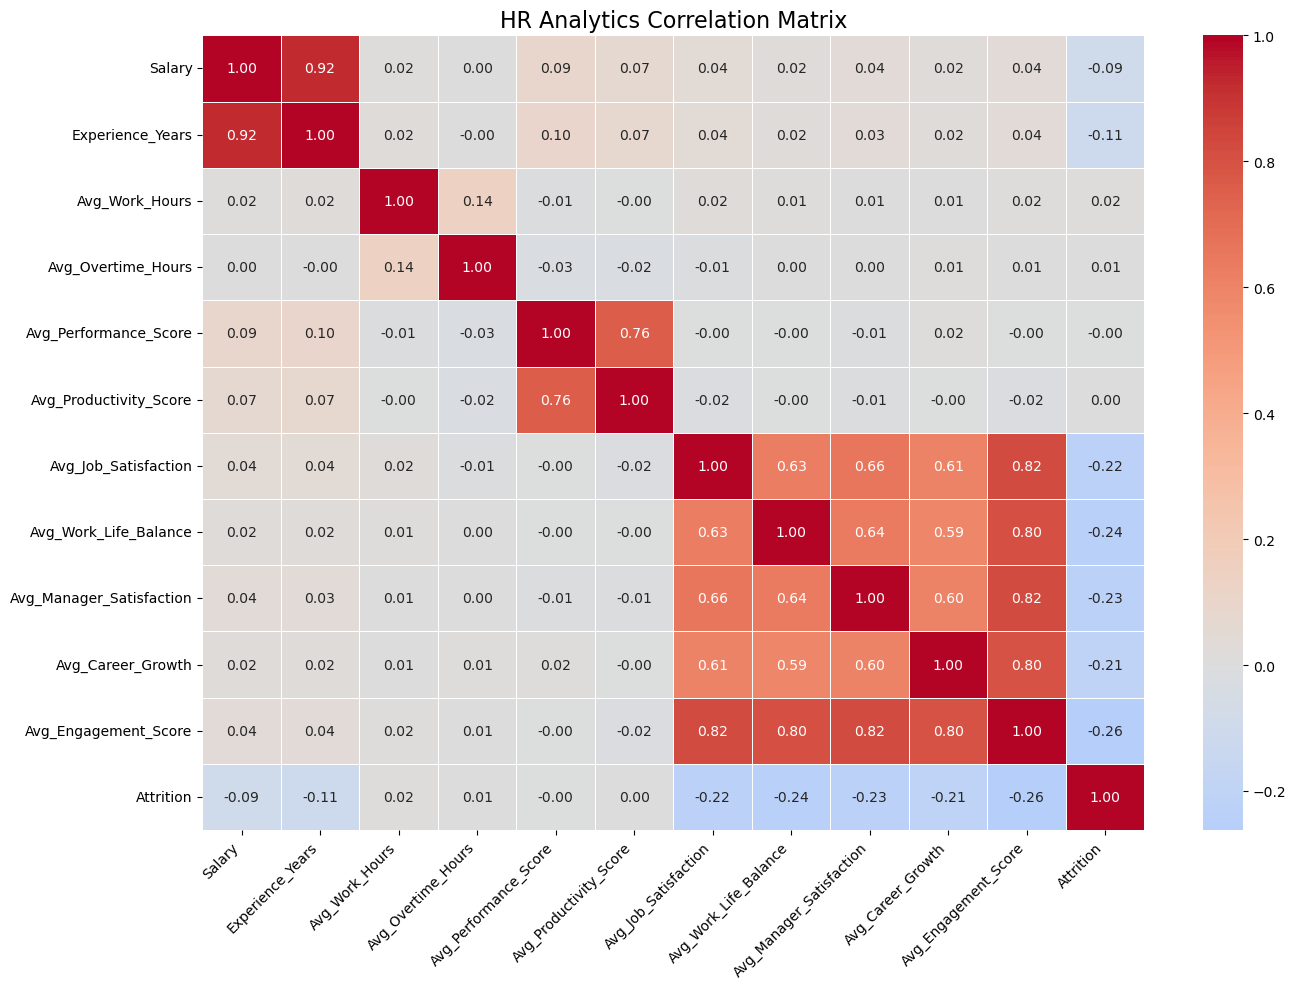

In [453]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("HR Analytics Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation Analysis

This analysis examines the relationships between salary, experience, attendance, overtime, performance, satisfaction, engagement, and attrition.

## Correlation Analysis – Key Findings

- Salary has a very weak negative correlation with attrition (-0.09).
- Experience has a weak negative correlation with attrition (-0.11).
- Overtime has almost no linear correlation with attrition (0.01).
- Performance has almost no linear correlation with attrition (-0.00).
- Job Satisfaction has a negative correlation with attrition (-0.22).
- Work-Life Balance has a negative correlation with attrition (-0.24).
- Manager Satisfaction has a negative correlation with attrition (-0.23).
- Career Growth has a negative correlation with attrition (-0.21).
- Engagement Score has the strongest negative correlation with attrition (-0.26).
- Performance and Productivity have a strong positive correlation (0.76).
- Job Satisfaction and Engagement Score have a strong positive correlation (0.82).

## Key Findings

- Employee engagement shows the strongest negative correlation with attrition.
- Job satisfaction, work-life balance, manager satisfaction, and career growth are negatively associated with attrition.
- Salary and experience show weak negative relationships with attrition.
- Overtime and performance show almost no linear relationship with attrition.
- Performance has a strong positive relationship with productivity.